In [1]:
library(scran)
library(edgeR)
library(ggplot2)
library(tidyr)
library(dplyr)
library(NatParksPalettes)

Loading required package: SingleCellExperiment

Warning message:
“package ‘SingleCellExperiment’ was built under R version 4.3.2”
Loading required package: SummarizedExperiment

Warning message:
“package ‘SummarizedExperiment’ was built under R version 4.3.2”
Loading required package: MatrixGenerics

Warning message:
“package ‘MatrixGenerics’ was built under R version 4.3.3”
Loading required package: matrixStats


Attaching package: ‘MatrixGenerics’


The following objects are masked from ‘package:matrixStats’:

    colAlls, colAnyNAs, colAnys, colAvgsPerRowSet, colCollapse,
    colCounts, colCummaxs, colCummins, colCumprods, colCumsums,
    colDiffs, colIQRDiffs, colIQRs, colLogSumExps, colMadDiffs,
    colMads, colMaxs, colMeans2, colMedians, colMins, colOrderStats,
    colProds, colQuantiles, colRanges, colRanks, colSdDiffs, colSds,
    colSums2, colTabulates, colVarDiffs, colVars, colWeightedMads,
    colWeightedMeans, colWeightedMedians, colWeightedSds,
    colWeightedVars, rowAll

# CPM (TMM adjusted) normalization for RNA

In [6]:
unique_cell_types <- c('Endothelial', 'Hepatocytes', 'T', 'HSC', 'Cholangiocyte', 'Myeloid', 'NK', 'B', 'Mast', 'Schwann', 'Bulk')

In [3]:
#looping through cell types by making ^ into a function
calculate_TMM <- function(cell.type, tmm.filename, pseudobulk.filename){
    x <- read.table(paste(pseudobulk.filename))
    
    if (sum(!colSums(x) != 0) > 0){
        print(paste0(cell.type, " has zero library size samples."))
        x <- x[,colSums(x) != 0]
    }
    
    edgeR.object <- DGEList(counts=x)
    edgeR.object <- calcNormFactors(object=edgeR.object, method='TMM')
    tmm.counts <- edgeR::cpm(edgeR.object, normalized.lib.sizes=T)

    #export df
    write.table(tmm.counts, tmm.filename, sep='\t',quote=FALSE)
}

In [4]:
indir <- '/nfs/lab/projects/nash_nafld_liver/downstream_all/count.matrices/RNA/'
outdir <- '/nfs/lab/projects/nash_nafld_liver/downstream_all/count.matrices/RNA/'

##### NAME YOUR FILES #####
for (cell.type in unique_cell_types){
    tmm.filename <- paste(outdir, cell.type, '_perdonor.RNA.TMM.tsv', sep = "")
    pseudobulk.filename <- paste(indir, cell.type, '_perdonor.RNA.counts.tsv', sep = "")
    calculate_TMM(cell.type, tmm.filename, pseudobulk.filename)
}

[1] "Mast has zero library size samples."
[1] "Schwann has zero library size samples."


In [5]:
cell.type

[1] "Bulk"

# CPM (TMM adjusted) normalization for ATAC

In [2]:
unique_cell_types <- c('Endothelial', 'Hepatocytes', 'T', 'HSC', 'Cholangiocyte', 'Myeloid', 'NK', 'B', 'Mast', 'Schwann','Bulk')

In [3]:
#looping through cell types by making ^ into a function
calculate_TMM <- function(cell.type, tmm.filename, pseudobulk.filename){
    x <- read.table(paste(pseudobulk.filename))
    
    if (sum(!colSums(x) != 0) > 0){
        print(paste0(cell.type, " has zero library size samples."))
        x <- x[,colSums(x) != 0]
    }
    
    edgeR.object <- DGEList(counts=x)
    edgeR.object <- calcNormFactors(object=edgeR.object, method='TMM')
    tmm.counts <- edgeR::cpm(edgeR.object, normalized.lib.sizes=T)

    #export df
    write.table(tmm.counts, tmm.filename, sep='\t',quote=FALSE)
}

In [ ]:
indir <- '/nfs/lab/projects/nash_nafld_liver/downstream_all/count.matrices/ATAC/'
outdir <- '/nfs/lab/projects/nash_nafld_liver/downstream_all/count.matrices/ATAC/'

##### NAME YOUR FILES #####
for (cell.type in unique_cell_types){
    tmm.filename <- paste(outdir, cell.type, '_perdonor.ATAC.TMM.tsv', sep = "")
    pseudobulk.filename <- paste(indir, cell.type, '_perdonor.ATAC.counts.tsv', sep = "")
    calculate_TMM(cell.type, tmm.filename, pseudobulk.filename)
}

# CPM (TMM adjusted) normalization for H3K27ac

In [5]:
unique_cell_types <- c('Endothelial', 'Hepatocytes', 'T', 'HSC', 'Cholangiocyte', 'Myeloid', 'NK', 'B', 'Mast', 'Schwann','Bulk')

In [6]:
#looping through cell types by making ^ into a function
calculate_TMM <- function(cell.type, tmm.filename, pseudobulk.filename){
    x <- read.table(paste(pseudobulk.filename))
    
    if (sum(!colSums(x) != 0) > 0){
        print(paste0(cell.type, " has zero library size samples."))
        x <- x[,colSums(x) != 0]
    }
    
    edgeR.object <- DGEList(counts=x)
    edgeR.object <- calcNormFactors(object=edgeR.object, method='TMM')
    tmm.counts <- edgeR::cpm(edgeR.object, normalized.lib.sizes=T)

    #export df
    write.table(tmm.counts, tmm.filename, sep='\t',quote=FALSE)
}

In [7]:
indir <- '/nfs/lab/projects/nash_nafld_liver/downstream_all/count.matrices/H3K27ac/'
outdir <- '/nfs/lab/projects/nash_nafld_liver/downstream_all/count.matrices/H3K27ac/'

##### NAME YOUR FILES #####
for (cell.type in unique_cell_types){
    tmm.filename <- paste(outdir, cell.type, '_perdonor.H3K27ac.TMM.tsv', sep = "")
    pseudobulk.filename <- paste(indir, cell.type, '_perdonor.H3K27ac.counts.tsv', sep = "")
    calculate_TMM(cell.type, tmm.filename, pseudobulk.filename)
}

[1] "NK has zero library size samples."
[1] "B has zero library size samples."
[1] "Mast has zero library size samples."
[1] "Schwann has zero library size samples."


# CPM (TMM adjusted) normalization for H3K27me3

In [8]:
unique_cell_types <- c('Endothelial', 'Hepatocytes', 'T', 'HSC', 'Cholangiocyte', 'Myeloid', 'NK', 'B', 'Mast', 'Schwann','Bulk')

In [9]:
#looping through cell types by making ^ into a function
calculate_TMM <- function(cell.type, tmm.filename, pseudobulk.filename){
    x <- read.table(paste(pseudobulk.filename))
    
    if (sum(!colSums(x) != 0) > 0){
        print(paste0(cell.type, " has zero library size samples."))
        x <- x[,colSums(x) != 0]
    }
    
    edgeR.object <- DGEList(counts=x)
    edgeR.object <- calcNormFactors(object=edgeR.object, method='TMM')
    tmm.counts <- edgeR::cpm(edgeR.object, normalized.lib.sizes=T)

    #export df
    write.table(tmm.counts, tmm.filename, sep='\t',quote=FALSE)
}

In [10]:
indir <- '/nfs/lab/projects/nash_nafld_liver/downstream_all/count.matrices/H3K27me3/'
outdir <- '/nfs/lab/projects/nash_nafld_liver/downstream_all/count.matrices/H3K27me3/'

##### NAME YOUR FILES #####
for (cell.type in unique_cell_types){
    tmm.filename <- paste(outdir, cell.type, '_perdonor.H3K27me3.TMM.tsv', sep = "")
    pseudobulk.filename <- paste(indir, cell.type, '_perdonor.H3K27me3.counts.tsv', sep = "")
    calculate_TMM(cell.type, tmm.filename, pseudobulk.filename)
}

[1] "NK has zero library size samples."
[1] "B has zero library size samples."
[1] "Mast has zero library size samples."
[1] "Schwann has zero library size samples."


# INT sources  
https://www.nature.com/articles/nature11401#Sec4  
https://www.biostars.org/p/80597/

In [ ]:
rankNormal <- function(x) {
    return(qnorm((rank(x,na.last="keep")-0.5)/sum(!is.na(x))))
}

INTransform <- function(cell.type, tmm.filename, pseudobulk.filename, tpm.filename, 
                        int.filename, TPM.cut=.1, count.cut=6) {
    tmm.data <- suppressWarnings(tibble::column_to_rownames(data.table::fread(tmm.filename),var='V1'))
    tpm.data <- suppressWarnings(tibble::column_to_rownames(data.table::fread(tpm.filename),var='V1'))
    pseudobulk.data <- suppressWarnings(tibble::column_to_rownames(data.table::fread(pseudobulk.filename),var='V1'))
    
    tpm.data <- tpm.data[colnames(tmm.data)]
    pseudobulk.data <- pseudobulk.data[colnames(tmm.data)]
    
    print(paste0('Processing ', cell.type))
    features <- rownames(tpm.data)[(rowSums(pseudobulk.data >= count.cut) >= (ncol(pseudobulk.data) * .2)) & 
                                   (rowSums(tpm.data >= TPM.cut) >= (ncol(tpm.data) * .2))]
    print(paste0("Features after TPM cutoff of ", TPM.cut, " for 20% of samples: ", 
                 sum((rowSums(tpm.data >= TPM.cut) >= (ncol(tpm.data) * .2)))))
    print(paste0("Features after count cutoff of ", count.cut, " for 20% of samples: ", 
                 sum((rowSums(pseudobulk.data >= count.cut) >= (ncol(pseudobulk.data) * .2)))))
    print(paste0("Features after both filters: ", length(features)))
    
    tmm.data.filt <- tmm.data[features,]
    
    int.data <- t(apply(tmm.data.filt, 1, rankNormal))
    write.table(int.data, int.filename, sep='\t', quote=F, row.names=T, col.names=T)
}

In [80]:
indir <- '/nfs/lab/projects/nash_nafld_liver/downstream_all/count.matrices/RNA/'
outdir <- '/nfs/lab/projects/nash_nafld_liver/downstream_all/count.matrices/RNA/'

##### NAME YOUR FILES #####
for (cell.type in unique_cell_types){
    pseudobulk.filename <- paste(indir, cell.type, '_perdonor.RNA.counts.tsv', sep = "")
    tmm.filename <- paste(indir, cell.type, '_perdonor.RNA.TMM.tsv', sep = "")
    tpm.filename <- paste(indir, cell.type, '_perdonor.RNA.TPM.tsv', sep = "")
    int.filename <- paste(outdir, cell.type, '_perdonor.RNA.INT.tsv', sep = "")
    INTransform(cell.type, tmm.filename, pseudobulk.filename, tpm.filename, int.filename, TPM.cut=.1, count.cut=6)
}

[1] "Processing Endothelial"
[1] "Features after TPM cutoff of 0.1 for 20% of samples: 25794"
[1] "Features after count cutoff of 6 for 20% of samples: 16010"
[1] "Features after both filters: 16010"
[1] "Processing Hepatocytes"
[1] "Features after TPM cutoff of 0.1 for 20% of samples: 26466"
[1] "Features after count cutoff of 6 for 20% of samples: 21394"
[1] "Features after both filters: 20889"
[1] "Processing T"
[1] "Features after TPM cutoff of 0.1 for 20% of samples: 15859"
[1] "Features after count cutoff of 6 for 20% of samples: 7254"
[1] "Features after both filters: 7254"
[1] "Processing HSC"
[1] "Features after TPM cutoff of 0.1 for 20% of samples: 22866"
[1] "Features after count cutoff of 6 for 20% of samples: 14139"
[1] "Features after both filters: 14139"
[1] "Processing Cholangiocyte"
[1] "Features after TPM cutoff of 0.1 for 20% of samples: 19348"
[1] "Features after count cutoff of 6 for 20% of samples: 11495"
[1] "Features after both filters: 11495"
[1] "Processing My

In [ ]:
indir <- '/nfs/lab/projects/nash_nafld_liver/downstream_all/count.matrices/ATAC/'
outdir <- '/nfs/lab/projects/nash_nafld_liver/downstream_all/count.matrices/ATAC/'

##### NAME YOUR FILES #####
for (cell.type in unique_cell_types){
    pseudobulk.filename <- paste(indir, cell.type, '_perdonor.ATAC.counts.tsv', sep = "")
    tmm.filename <- paste(indir, cell.type, '_perdonor.ATAC.TMM.tsv', sep = "")
    tpm.filename <- paste(indir, cell.type, '_perdonor.ATAC.CPM.tsv', sep = "")
    int.filename <- paste(outdir, cell.type, '_perdonor.ATAC.INT.tsv', sep = "")
    INTransform(cell.type, tmm.filename, pseudobulk.filename, tpm.filename, int.filename, TPM.cut=.1, count.cut=6)
}

In [12]:
indir <- '/nfs/lab/projects/nash_nafld_liver/downstream_all/count.matrices/H3K27ac/'
outdir <- '/nfs/lab/projects/nash_nafld_liver/downstream_all/count.matrices/H3K27ac/'

##### NAME YOUR FILES #####
for (cell.type in unique_cell_types){
    pseudobulk.filename <- paste(indir, cell.type, '_perdonor.H3K27ac.counts.tsv', sep = "")
    tmm.filename <- paste(indir, cell.type, '_perdonor.H3K27ac.TMM.tsv', sep = "")
    tpm.filename <- paste(indir, cell.type, '_perdonor.H3K27ac.CPM.tsv', sep = "")
    int.filename <- paste(outdir, cell.type, '_perdonor.H3K27ac.INT.tsv', sep = "")
    INTransform(cell.type, tmm.filename, pseudobulk.filename, tpm.filename, int.filename, TPM.cut=.1, count.cut=6)
}

[1] "Processing Endothelial"
[1] "Features after TPM cutoff of 0.1 for 20% of samples: 232163"
[1] "Features after count cutoff of 6 for 20% of samples: 50096"
[1] "Features after both filters: 50096"
[1] "Processing Hepatocytes"
[1] "Features after TPM cutoff of 0.1 for 20% of samples: 350884"
[1] "Features after count cutoff of 6 for 20% of samples: 172506"
[1] "Features after both filters: 172506"
[1] "Processing T"
[1] "Features after TPM cutoff of 0.1 for 20% of samples: 54639"
[1] "Features after count cutoff of 6 for 20% of samples: 3216"
[1] "Features after both filters: 3216"
[1] "Processing HSC"
[1] "Features after TPM cutoff of 0.1 for 20% of samples: 146261"
[1] "Features after count cutoff of 6 for 20% of samples: 14596"
[1] "Features after both filters: 14596"
[1] "Processing Cholangiocyte"
[1] "Features after TPM cutoff of 0.1 for 20% of samples: 159269"
[1] "Features after count cutoff of 6 for 20% of samples: 28575"
[1] "Features after both filters: 28575"
[1] "Process

In [71]:
indir <- '/nfs/lab/projects/nash_nafld_liver/downstream_all/count.matrices/H3K27ac/'
outdir <- '/nfs/lab/projects/nash_nafld_liver/downstream_all/count.matrices/H3K27ac/'

##### NAME YOUR FILES #####
for (cell.type in unique_cell_types){
    pseudobulk.filename <- paste(indir, cell.type, '_perdonor.H3K27ac.counts.tsv', sep = "")
    tmm.filename <- paste(indir, cell.type, '_perdonor.H3K27ac.TMM.tsv', sep = "")
    tpm.filename <- paste(indir, cell.type, '_perdonor.H3K27ac.CPM.tsv', sep = "")
    int.filename <- paste(outdir, cell.type, '_perdonor.H3K27ac.INT.tsv', sep = "")
    INTransform(cell.type, tmm.filename, pseudobulk.filename, tpm.filename, int.filename, TPM.cut=.1, count.cut=3)
}

[1] "Processing Endothelial"
[1] "Features after TPM cutoff of 0.1 for 20% of samples: 232163"
[1] "Features after count cutoff of 3 for 20% of samples: 105716"
[1] "Features after both filters: 105716"
[1] "Processing Hepatocytes"
[1] "Features after TPM cutoff of 0.1 for 20% of samples: 350884"
[1] "Features after count cutoff of 3 for 20% of samples: 262385"
[1] "Features after both filters: 262385"
[1] "Processing T"
[1] "Features after TPM cutoff of 0.1 for 20% of samples: 54639"
[1] "Features after count cutoff of 3 for 20% of samples: 16392"
[1] "Features after both filters: 16392"
[1] "Processing HSC"
[1] "Features after TPM cutoff of 0.1 for 20% of samples: 146261"
[1] "Features after count cutoff of 3 for 20% of samples: 45602"
[1] "Features after both filters: 45602"
[1] "Processing Cholangiocyte"
[1] "Features after TPM cutoff of 0.1 for 20% of samples: 159269"
[1] "Features after count cutoff of 3 for 20% of samples: 63724"
[1] "Features after both filters: 63724"
[1] "Pro

In [72]:
indir <- '/nfs/lab/projects/nash_nafld_liver/downstream_all/count.matrices/H3K27me3/'
outdir <- '/nfs/lab/projects/nash_nafld_liver/downstream_all/count.matrices/H3K27me3/'

##### NAME YOUR FILES #####
for (cell.type in unique_cell_types){
    pseudobulk.filename <- paste(indir, cell.type, '_perdonor.H3K27me3.counts.tsv', sep = "")
    tmm.filename <- paste(indir, cell.type, '_perdonor.H3K27me3.TMM.tsv', sep = "")
    tpm.filename <- paste(indir, cell.type, '_perdonor.H3K27me3.CPM.tsv', sep = "")
    int.filename <- paste(outdir, cell.type, '_perdonor.H3K27me3.INT.tsv', sep = "")
    INTransform(cell.type, tmm.filename, pseudobulk.filename, tpm.filename, int.filename, TPM.cut=.1, count.cut=3)
}

[1] "Processing Endothelial"
[1] "Features after TPM cutoff of 0.1 for 20% of samples: 347210"
[1] "Features after count cutoff of 3 for 20% of samples: 116452"
[1] "Features after both filters: 116452"
[1] "Processing Hepatocytes"
[1] "Features after TPM cutoff of 0.1 for 20% of samples: 457739"
[1] "Features after count cutoff of 3 for 20% of samples: 428811"
[1] "Features after both filters: 428811"
[1] "Processing T"
[1] "Features after TPM cutoff of 0.1 for 20% of samples: 194507"
[1] "Features after count cutoff of 3 for 20% of samples: 14085"
[1] "Features after both filters: 14085"
[1] "Processing HSC"
[1] "Features after TPM cutoff of 0.1 for 20% of samples: 161076"
[1] "Features after count cutoff of 3 for 20% of samples: 21097"
[1] "Features after both filters: 21097"
[1] "Processing Cholangiocyte"
[1] "Features after TPM cutoff of 0.1 for 20% of samples: 293320"
[1] "Features after count cutoff of 3 for 20% of samples: 87463"
[1] "Features after both filters: 87463"
[1] "Pr

In [2]:
make_PC_covariate_mat <- function(cell.type, expr.mat.filename, pc.filename, cor.filename, n_pc=15, meta) {
    test.data <- read.table(expr.mat.filename)
    pca.res <- prcomp(t(test.data))
    
    print(paste0(n_pc, " PCs cover ", summary(pca.res)$importance[3,15] * 100, "% of variance for ", cell.type))
    
    # Check for outliers
    for (i in 1:n_pc) {
        if(sum(abs(pca.res$x[,i]) > pca.res$sdev[i] * 3) != 0) {
            print(paste0(names(which(abs(pca.res$x[,i]) > pca.res$sdev[i] * 3)), 
                 ' is an outlier on PC', i, " for ", cell.type))
        }
    }
    
    write.table(pca.res$x[,1:15], pc.filename,
               sep='\t', col.names=T, row.names=T, quote=F)
    
    # Correlate with metadata
    cor.res <- cor(cbind(pca.res$x[,1:15], meta[rownames(pca.res$x),]))[1:15,16:(15 + ncol(meta))]
    cor.plot.data <- tidyr::pivot_longer(tibble::rownames_to_column(data.frame(cor.res), var='PC'), 
                        names_to = 'Covariate', values_to = 'Coefficient', cols = -PC)
    write.table(cor.plot.data, cor.filename,
               sep='\t', col.names=T, row.names=T, quote=F)
    
    # Plot correlation
    p1 <- ggplot(cor.plot.data, aes(x=PC, y=Covariate, fill=Coefficient)) + geom_tile() + 
        scale_fill_gradientn(colors=natparks.pals("Olympic"), limits=c(-1,1)) + 
        theme_classic(base_size=16) + ggtitle(cell.type)
    print(p1)
}

In [3]:
options(repr.plot.width=12, repr.plot.height=8)

In [4]:
meta = read.table("/nfs/lab/projects/nash_nafld_liver/downstream_all/01_DESEQ_RNA/RNA.meta.tsv", 
                  sep='\t', header=T)
#colnames(meta)
meta <- tibble::column_to_rownames(meta, var='donor_demux')
meta$Gender <- as.integer(factor(meta$Gender))
meta$disease_status <- as.integer(factor(meta$disease_status))
meta$batch <- as.integer(factor(meta$batch, levels=c('firstPR','secondPR','thirdPR','fourthPR')))
meta$condition <- as.integer(factor(meta$condition, levels=c('Control','MASL','MASH','MetALD')))
meta <- dplyr::select(meta, -Ballooning, -Fat.distribution, -Hepatocyte.necrosis, -Portal.inflammation,
                     -Age, -BMI)

dim(meta)
head(meta)

[1] 86 20

,B,Cholangiocyte,Endothelial,Hepatocytes,HSC,Mast,Myeloid,NK,Schwann,T,batch,disease_status,condition,Steatosis.grade,Fibrosis.stage,Lobular.inflammation,MASH.CRN.score..X.8,Gender,BMI.scaled,Age.scaled
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>
HL150001,85,47,746,8760,308,4,726,167,8,79,3,2,2,1,0,0,1,2,-0.6385847,-0.01553551
HL150009,19,34,459,2317,329,0,227,23,6,36,4,2,2,1,0,0,1,2,-0.3346869,-0.75778750
HL150013,93,31,553,541,308,31,459,100,1,114,2,2,3,1,2,1,3,2,0.4052379,-0.16398591
HL150015,59,59,410,4421,312,1,199,63,7,37,4,2,2,3,1,0,3,2,-0.3743258,0.87516689
HL160017,54,68,662,6986,199,0,683,39,2,129,4,2,4,1,2,1,2,2,-1.0481859,-1.20313870
HL160022,9,187,349,1097,334,0,468,22,8,56,2,2,3,3,2,1,5,1,-0.2818352,-0.16398591


[1] "15 PCs cover 58.711% of variance for Endothelial"
[1] "HL191025 is an outlier on PC8 for Endothelial"
[1] "HL200707 is an outlier on PC11 for Endothelial"
[2] "HL221019 is an outlier on PC11 for Endothelial"
[3] "HL220216 is an outlier on PC11 for Endothelial"
[1] "HL221019 is an outlier on PC12 for Endothelial"
[1] "HL160042 is an outlier on PC13 for Endothelial"
[2] "HL220825 is an outlier on PC13 for Endothelial"
[3] "HL200707 is an outlier on PC13 for Endothelial"
[1] "HL160042 is an outlier on PC14 for Endothelial"
[2] "HL191025 is an outlier on PC14 for Endothelial"
[1] "HL200707 is an outlier on PC15 for Endothelial"
[1] "15 PCs cover 61.666% of variance for Hepatocytes"
[1] "HL211106 is an outlier on PC4 for Hepatocytes"
[1] "HL211106 is an outlier on PC7 for Hepatocytes"
[1] "HL190827 is an outlier on PC10 for Hepatocytes"
[1] "HL221019 is an outlier on PC11 for Hepatocytes"
[2] "HL190827 is an outlier on PC11 for Hepatocytes"
[1] "HL220216 is an outlier on PC14 for Hepat

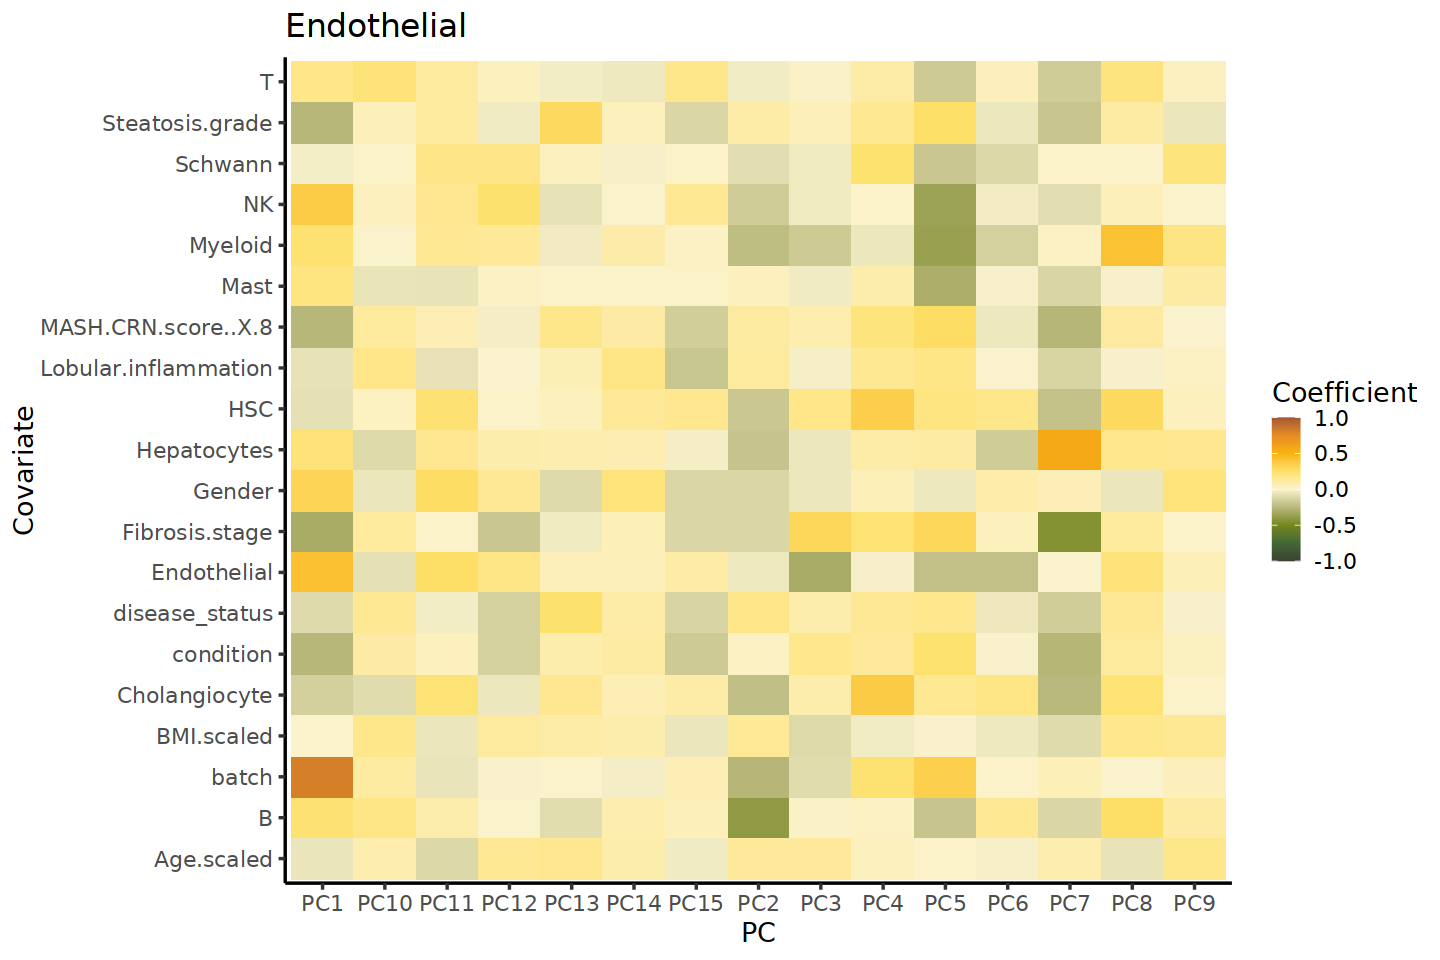

[1] "15 PCs cover 44.922% of variance for T"
[1] "HL221006 is an outlier on PC4 for T"
[1] "HL211106 is an outlier on PC5 for T"
[1] "HL220825 is an outlier on PC6 for T" "HL221019 is an outlier on PC6 for T"
[3] "HL230325 is an outlier on PC6 for T"
[1] "HL220825 is an outlier on PC7 for T" "HL221019 is an outlier on PC7 for T"
[3] "HL170047 is an outlier on PC7 for T"
[1] "HL170060 is an outlier on PC8 for T" "HL220825 is an outlier on PC8 for T"
[3] "HL170047 is an outlier on PC8 for T"
[1] "HL170060 is an outlier on PC9 for T" "HL170047 is an outlier on PC9 for T"
[1] "HL160042 is an outlier on PC10 for T"
[1] "HL160042 is an outlier on PC11 for T"
[2] "HL221019 is an outlier on PC11 for T"
[1] "HL221019 is an outlier on PC12 for T"
[2] "HL160041 is an outlier on PC12 for T"
[1] "HL200707 is an outlier on PC13 for T"
[2] "HL170049 is an outlier on PC13 for T"
[3] "HL160041 is an outlier on PC13 for T"
[1] "HL200707 is an outlier on PC14 for T"
[2] "HL190214 is an outlier on PC14 fo

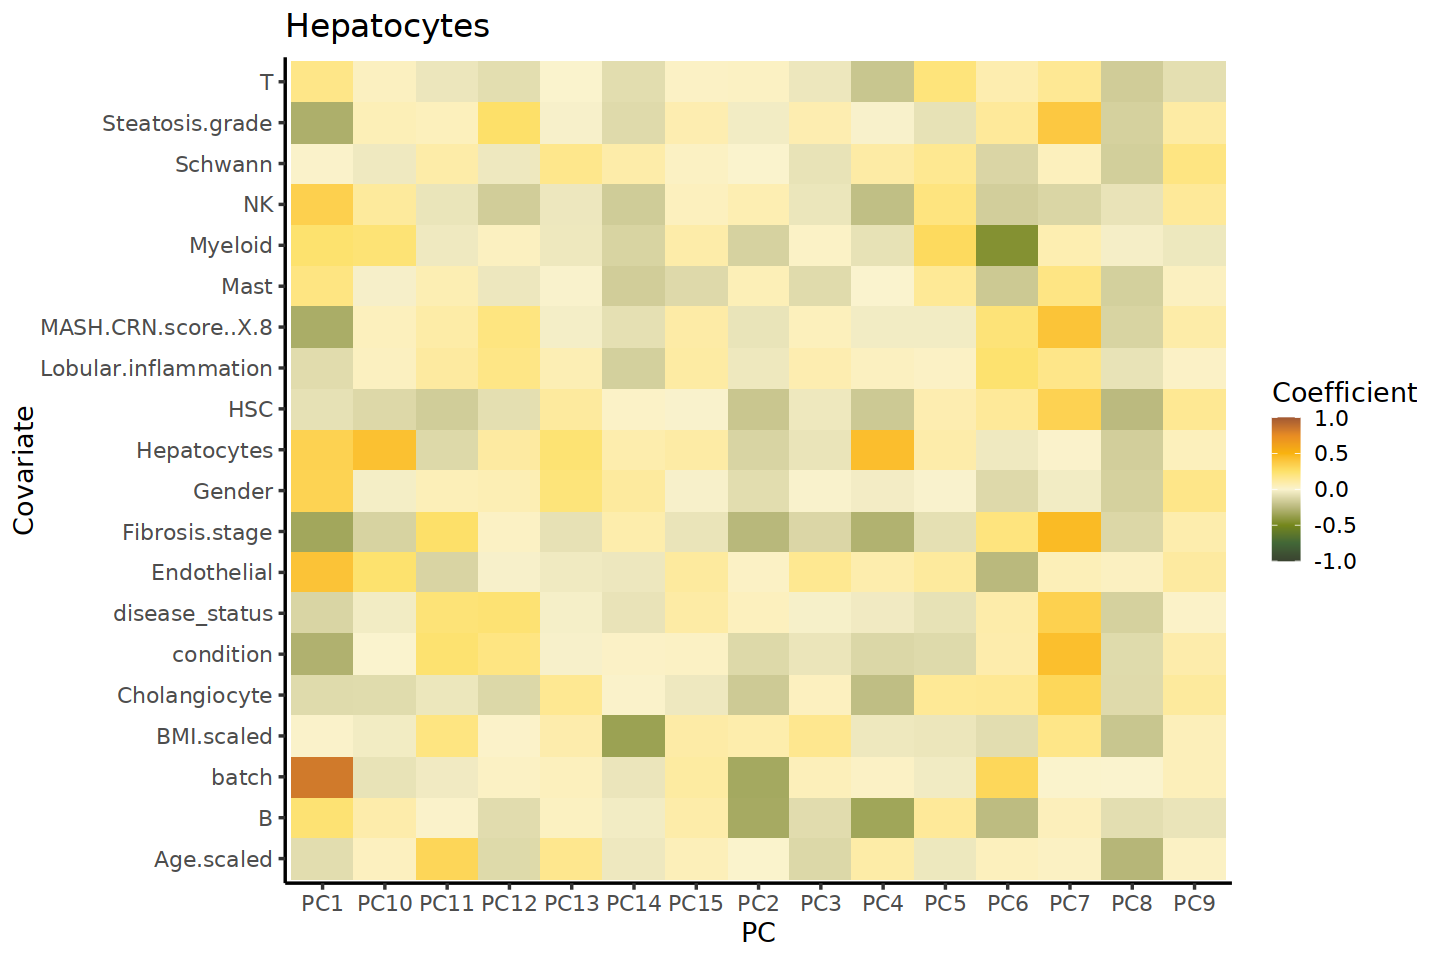

[1] "15 PCs cover 55.159% of variance for HSC"
[1] "HL170049 is an outlier on PC5 for HSC"
[1] "HL220216 is an outlier on PC7 for HSC"
[1] "HL200707 is an outlier on PC9 for HSC"
[2] "HL221019 is an outlier on PC9 for HSC"
[1] "HL220825 is an outlier on PC10 for HSC"
[2] "HL200707 is an outlier on PC10 for HSC"
[1] "HL160042 is an outlier on PC11 for HSC"
[2] "HL170060 is an outlier on PC11 for HSC"
[1] "HL160042 is an outlier on PC12 for HSC"
[2] "HL170060 is an outlier on PC12 for HSC"
[1] "HL160042 is an outlier on PC13 for HSC"
[2] "HL220825 is an outlier on PC13 for HSC"
[1] "HL170060 is an outlier on PC14 for HSC"
[1] "HL221019 is an outlier on PC15 for HSC"
[2] "HL160041 is an outlier on PC15 for HSC"


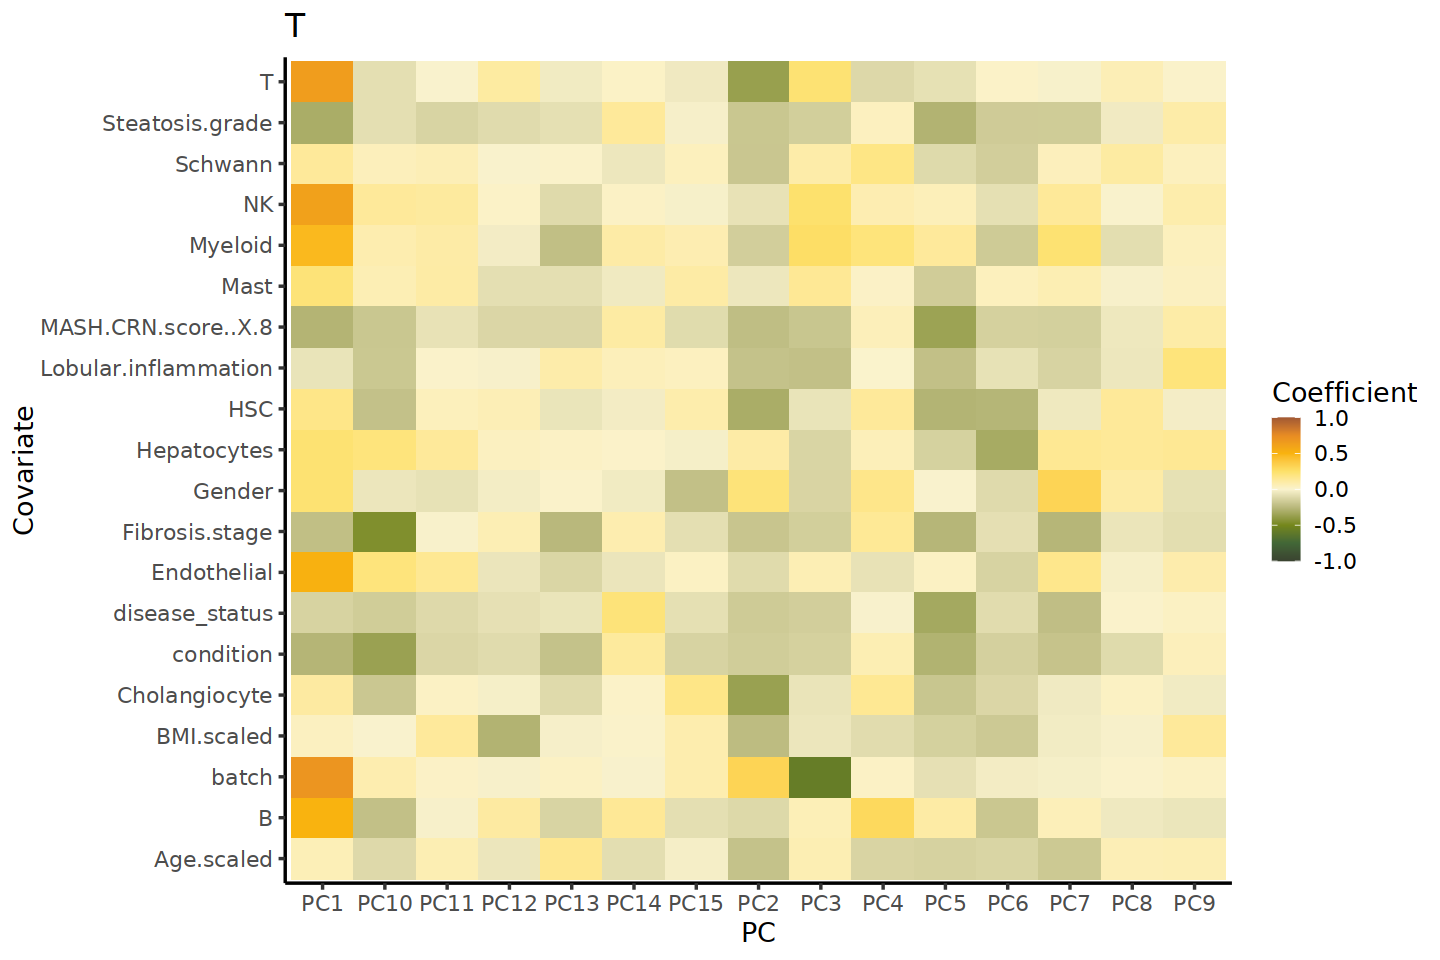

[1] "15 PCs cover 50.08% of variance for Cholangiocyte"
[1] "HL160029 is an outlier on PC1 for Cholangiocyte"
[2] "HL200707 is an outlier on PC1 for Cholangiocyte"
[1] "HL220216 is an outlier on PC4 for Cholangiocyte"
[1] "HL220825 is an outlier on PC6 for Cholangiocyte"
[1] "HL160042 is an outlier on PC7 for Cholangiocyte"
[2] "HL220825 is an outlier on PC7 for Cholangiocyte"
[1] "HL160042 is an outlier on PC8 for Cholangiocyte"
[2] "HL160029 is an outlier on PC8 for Cholangiocyte"
[3] "HL200707 is an outlier on PC8 for Cholangiocyte"
[1] "HL160042 is an outlier on PC9 for Cholangiocyte"
[2] "HL220825 is an outlier on PC9 for Cholangiocyte"
[3] "HL200707 is an outlier on PC9 for Cholangiocyte"
[1] "HL170060 is an outlier on PC10 for Cholangiocyte"
[1] "HL170060 is an outlier on PC11 for Cholangiocyte"
[2] "HL150009 is an outlier on PC11 for Cholangiocyte"
[1] "HL170060 is an outlier on PC12 for Cholangiocyte"
[2] "HL220613 is an outlier on PC12 for Cholangiocyte"
[3] "HL150009 is an o

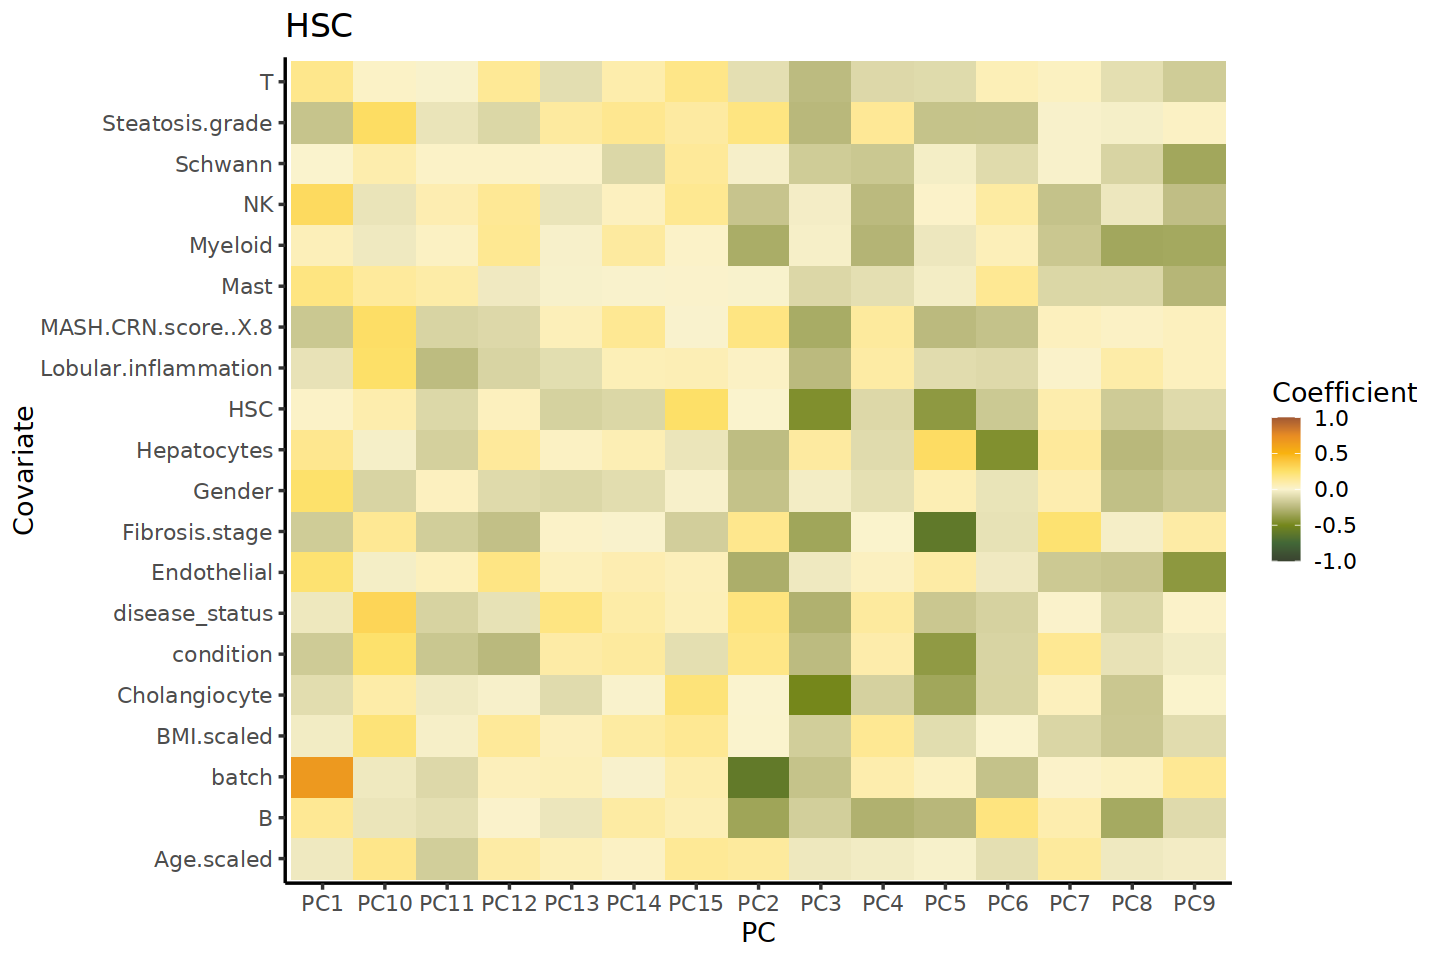

[1] "15 PCs cover 58.501% of variance for Myeloid"
[1] "HL221119 is an outlier on PC2 for Myeloid"
[2] "HL211106 is an outlier on PC2 for Myeloid"
[1] "HL160026 is an outlier on PC4 for Myeloid"
[1] "HL160026 is an outlier on PC8 for Myeloid"
[1] "HL220825 is an outlier on PC9 for Myeloid"
[2] "HL191025 is an outlier on PC9 for Myeloid"
[1] "HL160042 is an outlier on PC10 for Myeloid"
[2] "HL191025 is an outlier on PC10 for Myeloid"
[1] "HL170060 is an outlier on PC11 for Myeloid"
[1] "HL160042 is an outlier on PC12 for Myeloid"
[2] "HL200925 is an outlier on PC12 for Myeloid"
[1] "HL160029 is an outlier on PC13 for Myeloid"
[2] "HL160026 is an outlier on PC13 for Myeloid"
[1] "HL200707 is an outlier on PC14 for Myeloid"
[2] "HL211106 is an outlier on PC14 for Myeloid"
[1] "HL200707 is an outlier on PC15 for Myeloid"


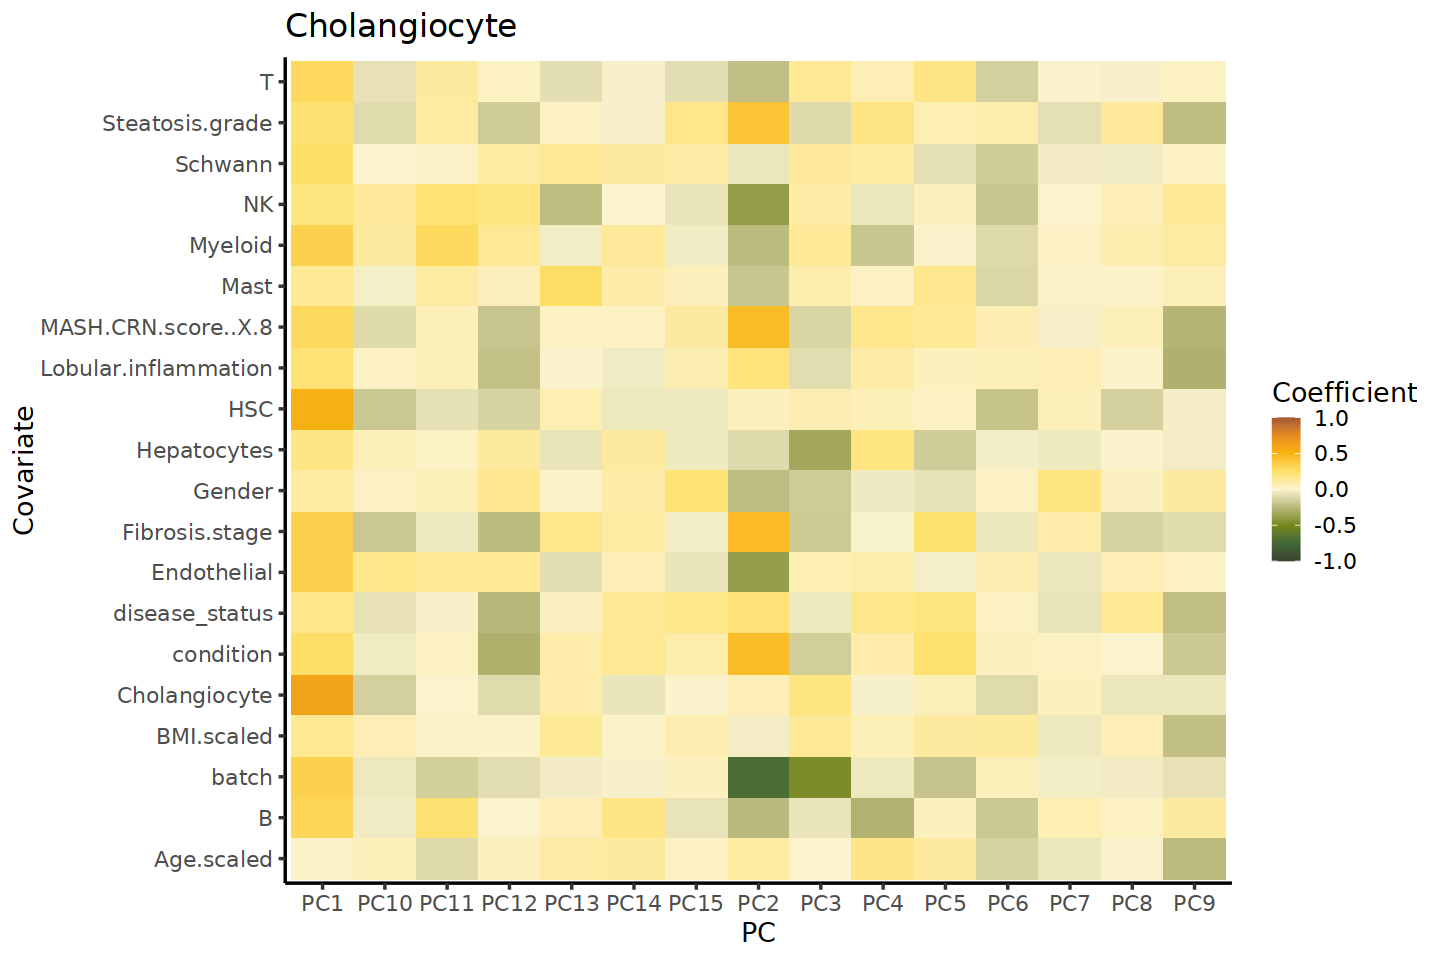

[1] "15 PCs cover 47.086% of variance for NK"
[1] "HL220825 is an outlier on PC1 for NK"
[1] "HL160042 is an outlier on PC7 for NK"
[2] "HL170060 is an outlier on PC7 for NK"
[1] "HL170049 is an outlier on PC8 for NK"
[1] "HL160042 is an outlier on PC9 for NK"
[2] "HL160022 is an outlier on PC9 for NK"
[1] "HL160042 is an outlier on PC10 for NK"
[2] "HL170060 is an outlier on PC10 for NK"
[3] "HL220825 is an outlier on PC10 for NK"
[1] "HL160042 is an outlier on PC11 for NK"
[2] "HL160022 is an outlier on PC11 for NK"
[1] "HL200707 is an outlier on PC12 for NK"
[2] "HL220613 is an outlier on PC12 for NK"
[1] "HL160029 is an outlier on PC13 for NK"
[2] "HL200707 is an outlier on PC13 for NK"
[1] "HL160029 is an outlier on PC14 for NK"
[2] "HL170060 is an outlier on PC14 for NK"
[3] "HL221019 is an outlier on PC14 for NK"
[1] "HL191025 is an outlier on PC15 for NK"
[2] "HL150009 is an outlier on PC15 for NK"


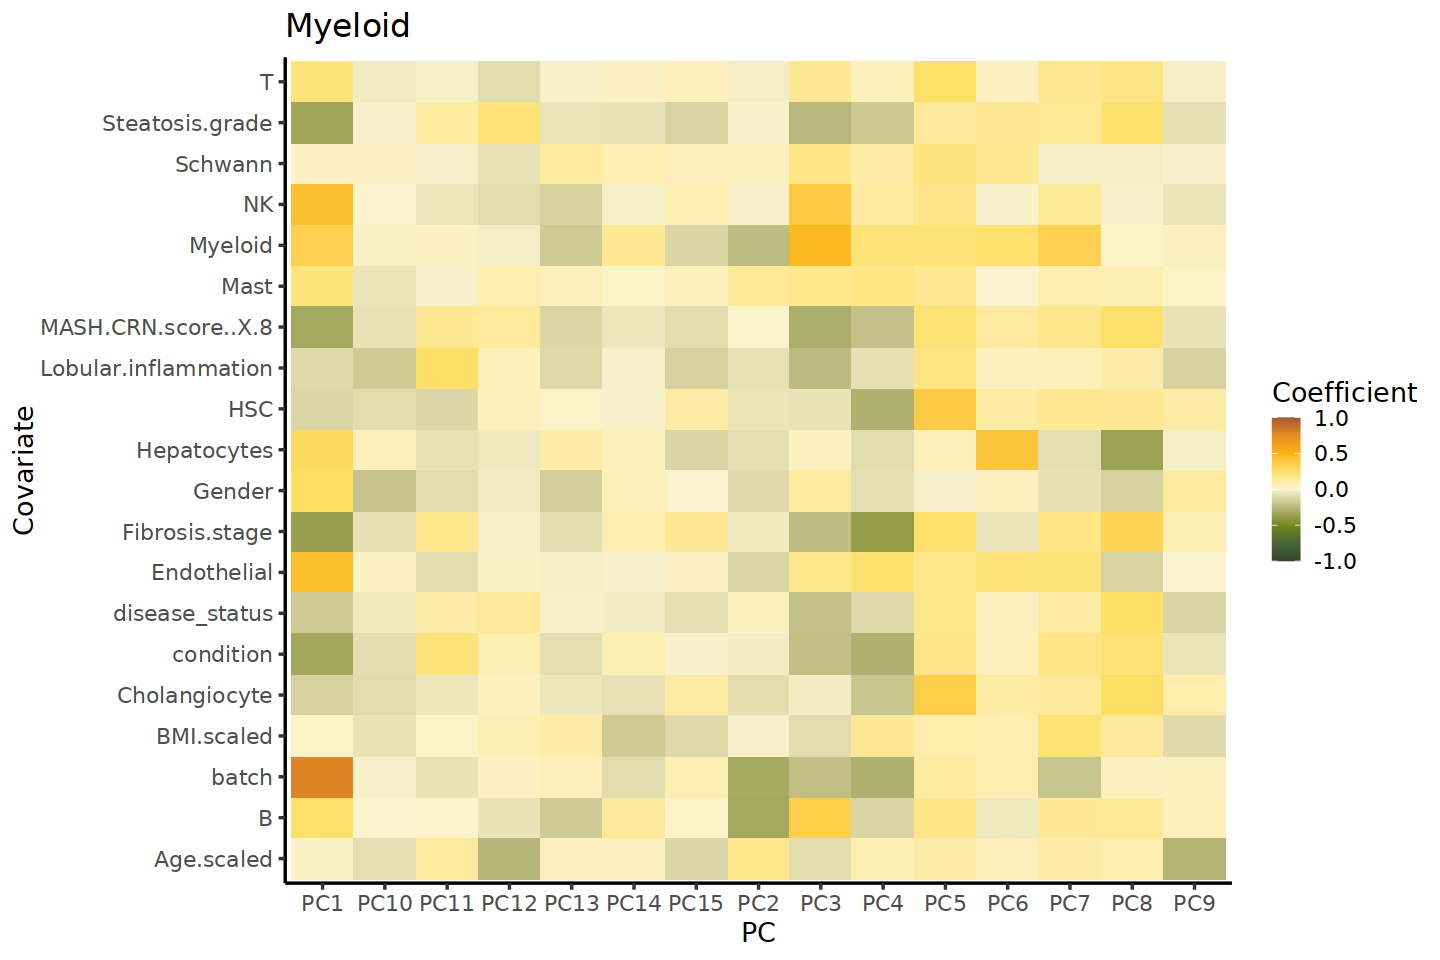

[1] "15 PCs cover 50.466% of variance for B"
[1] "HL170049 is an outlier on PC1 for B"
[1] "HL201120 is an outlier on PC6 for B"
[1] "HL160042 is an outlier on PC8 for B"
[1] "HL160029 is an outlier on PC9 for B" "HL191025 is an outlier on PC9 for B"
[1] "HL210120 is an outlier on PC10 for B"
[2] "HL220825 is an outlier on PC10 for B"
[1] "HL191025 is an outlier on PC11 for B"
[2] "HL200707 is an outlier on PC11 for B"
[3] "HL160041 is an outlier on PC11 for B"
[1] "HL160029 is an outlier on PC12 for B"
[2] "HL210120 is an outlier on PC12 for B"
[3] "HL220825 is an outlier on PC12 for B"
[1] "HL160029 is an outlier on PC13 for B"
[2] "HL220825 is an outlier on PC13 for B"
[3] "HL160022 is an outlier on PC13 for B"
[1] "HL200707 is an outlier on PC14 for B"
[2] "HL170049 is an outlier on PC14 for B"
[1] "HL160042 is an outlier on PC15 for B"
[2] "HL160029 is an outlier on PC15 for B"


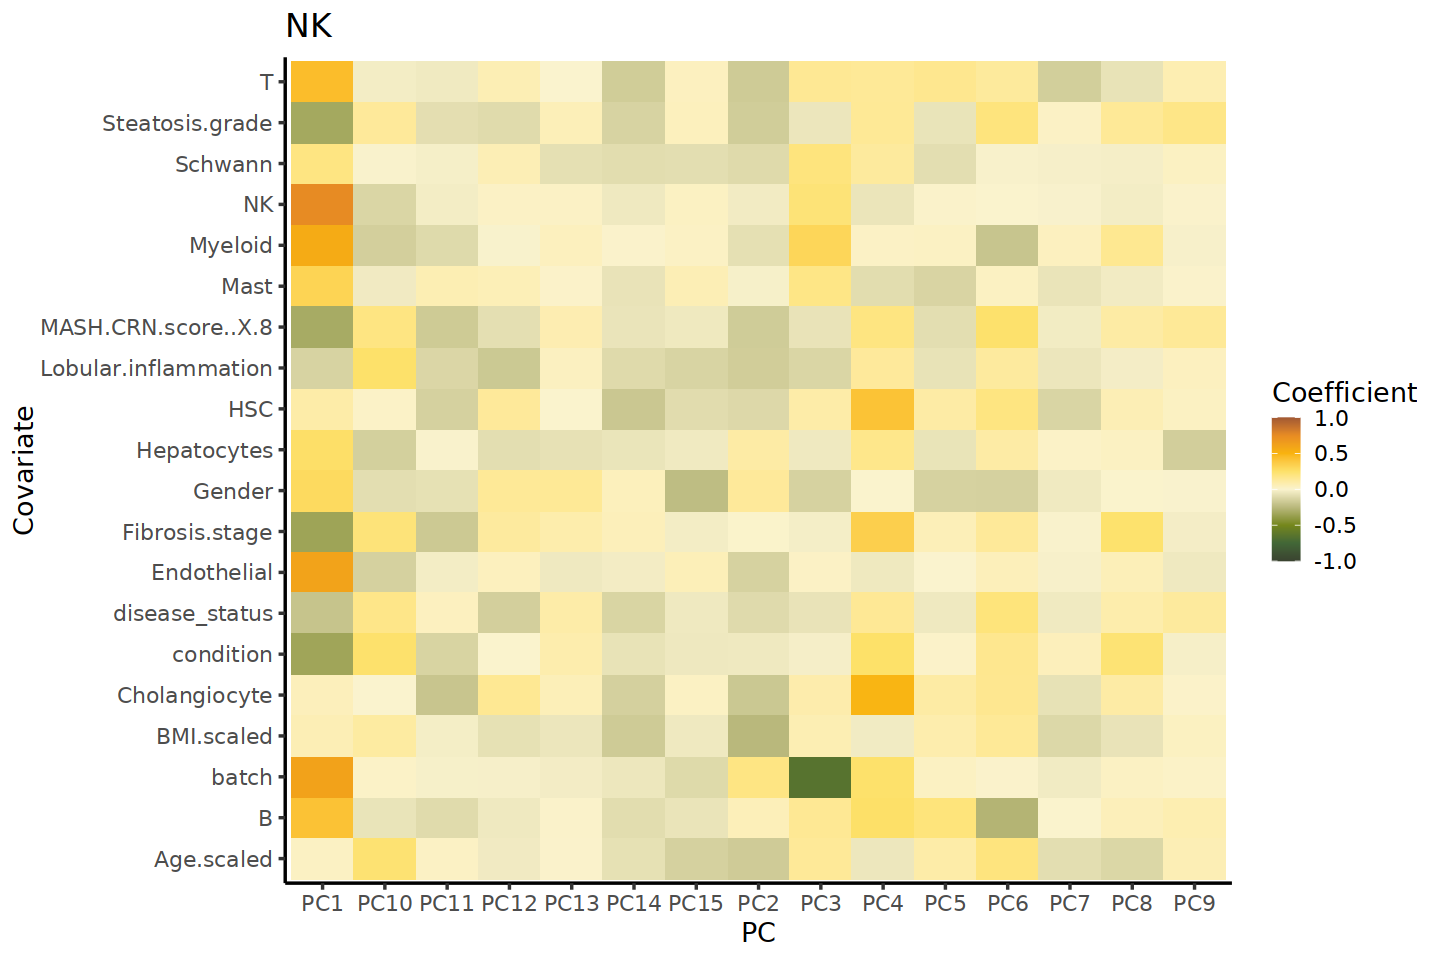

[1] "15 PCs cover 66.345% of variance for Bulk"
[1] "HL230325 is an outlier on PC3 for Bulk"
[2] "HL221119 is an outlier on PC3 for Bulk"
[1] "HL221006 is an outlier on PC7 for Bulk"
[2] "HL211106 is an outlier on PC7 for Bulk"
[1] "HL221019 is an outlier on PC12 for Bulk"
[1] "HL220825 is an outlier on PC13 for Bulk"
[1] "HL191025 is an outlier on PC14 for Bulk"
[1] "HL170060 is an outlier on PC15 for Bulk"


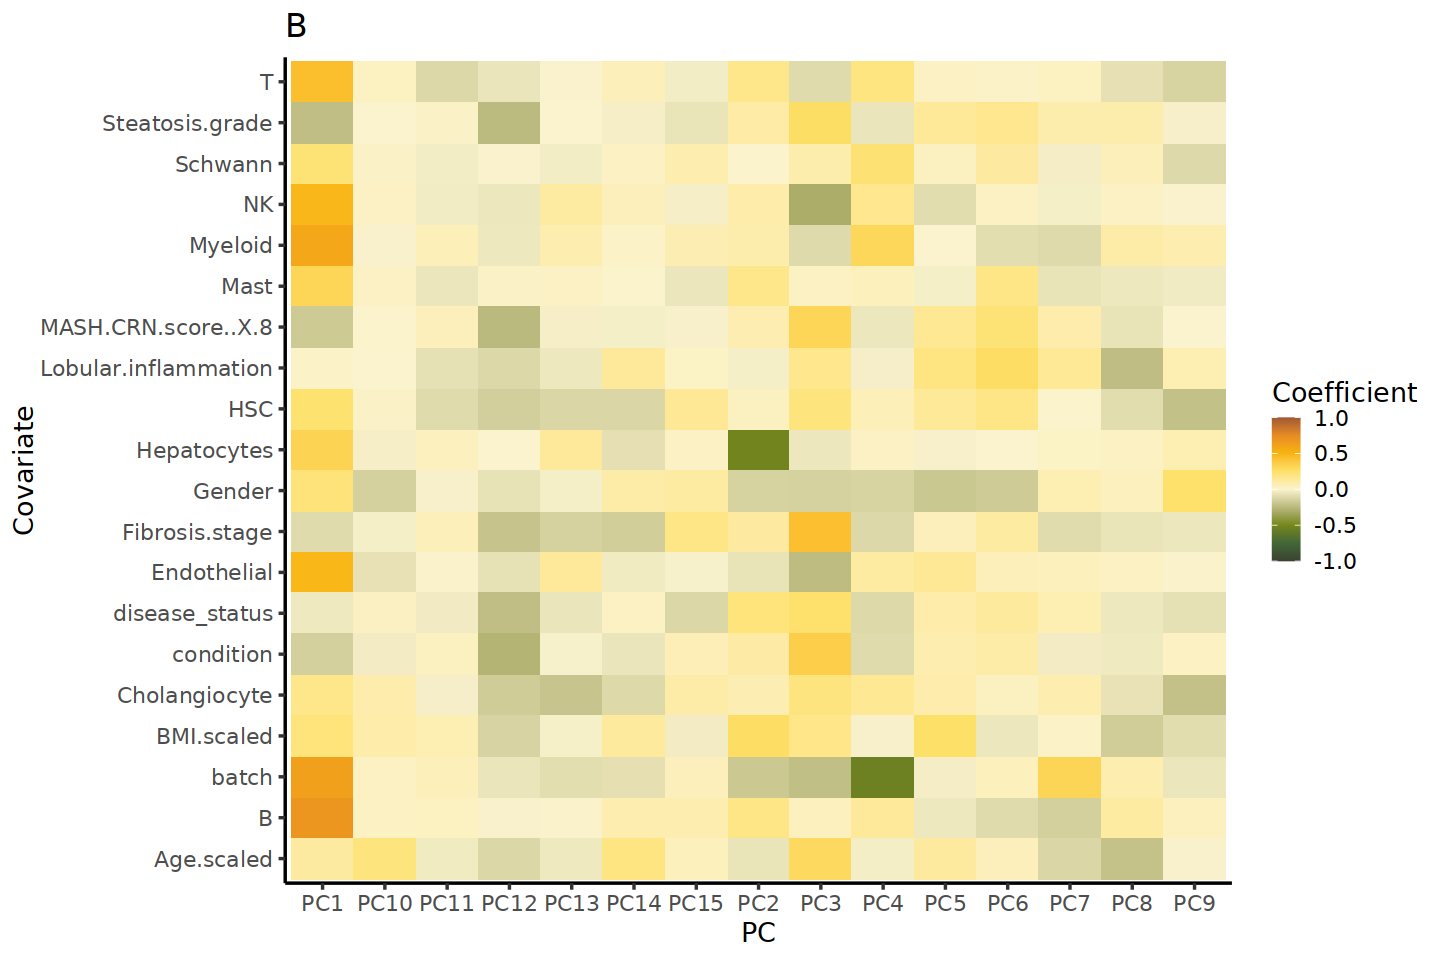

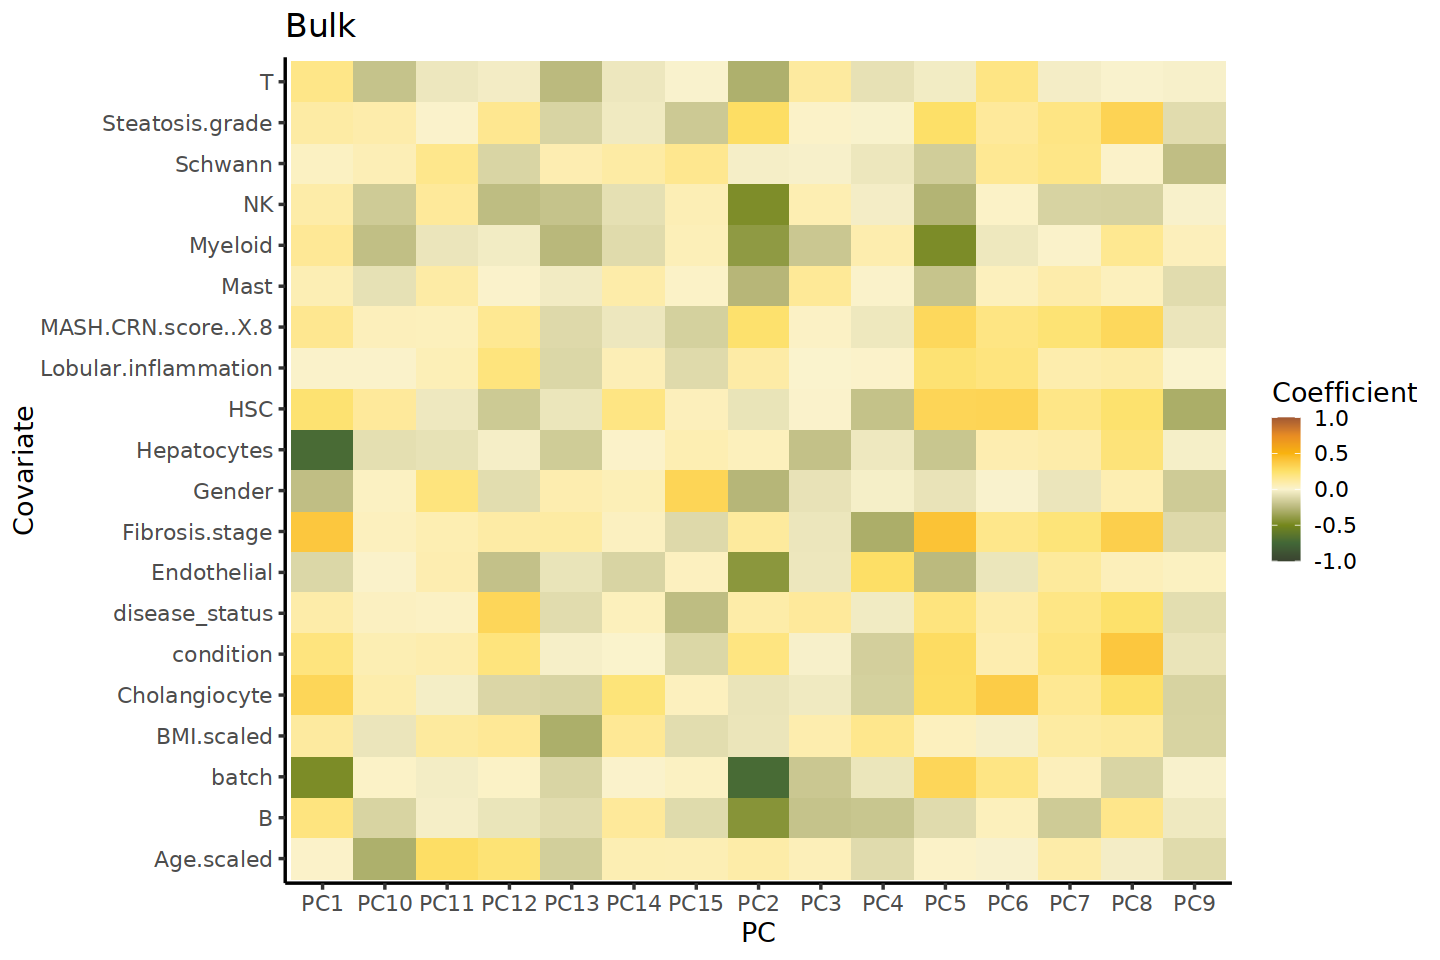

In [242]:
indir <- '/nfs/lab/projects/nash_nafld_liver/downstream_all/count.matrices/RNA/'
outdir <- '/nfs/lab/projects/nash_nafld_liver/downstream_all/04_eQTLs/covariates/'

n_pc <- 15

##### NAME YOUR FILES #####
for (cell.type in unique_cell_types){
    # Not enough stuff for these cell types
    if (cell.type %in% c('Mast','Schwann')) {
        next
    }
    #tmm.filename <- paste(indir, cell.type, '_perdonor.RNA.TMM.tsv', sep = "")
    int.filename <- paste(indir, cell.type, '_perdonor.RNA.INT.tsv', sep = "")
    pc.filename <- paste(outdir, cell.type, '_perdonor.RNA.INT.', n_pc,'.PCs.tsv', sep = "")
    cor.filename <- paste(outdir, cell.type, '_perdonor.RNA.INT.', n_pc,'.PCs.correlation.tsv', sep = "")
    make_PC_covariate_mat(cell.type, expr.mat.filename=int.filename, pc.filename, 
                          cor.filename, n_pc=15, meta)
}

[1] "15 PCs cover 88.571% of variance for Endothelial"
[1] "HL190827 is an outlier on PC1 for Endothelial"
[1] "HL211106 is an outlier on PC4 for Endothelial"
[2] "HL190827 is an outlier on PC4 for Endothelial"
[1] "HL221119 is an outlier on PC6 for Endothelial"
[2] "HL190909 is an outlier on PC6 for Endothelial"
[1] "HL220402 is an outlier on PC8 for Endothelial"
[1] "HL220402 is an outlier on PC9 for Endothelial"
[2] "HL230325 is an outlier on PC9 for Endothelial"
[3] "HL220216 is an outlier on PC9 for Endothelial"
[1] "HL211106 is an outlier on PC12 for Endothelial"
[1] "15 PCs cover 90.86% of variance for Hepatocytes"
[1] "HL211106 is an outlier on PC1 for Hepatocytes"
[1] "HL160017 is an outlier on PC2 for Hepatocytes"
[1] "HL211106 is an outlier on PC3 for Hepatocytes"
[2] "HL200529 is an outlier on PC3 for Hepatocytes"
[1] "HL170062 is an outlier on PC6 for Hepatocytes"
[2] "HL220216 is an outlier on PC6 for Hepatocytes"
[1] "HL211106 is an outlier on PC7 for Hepatocytes"
[1] "H

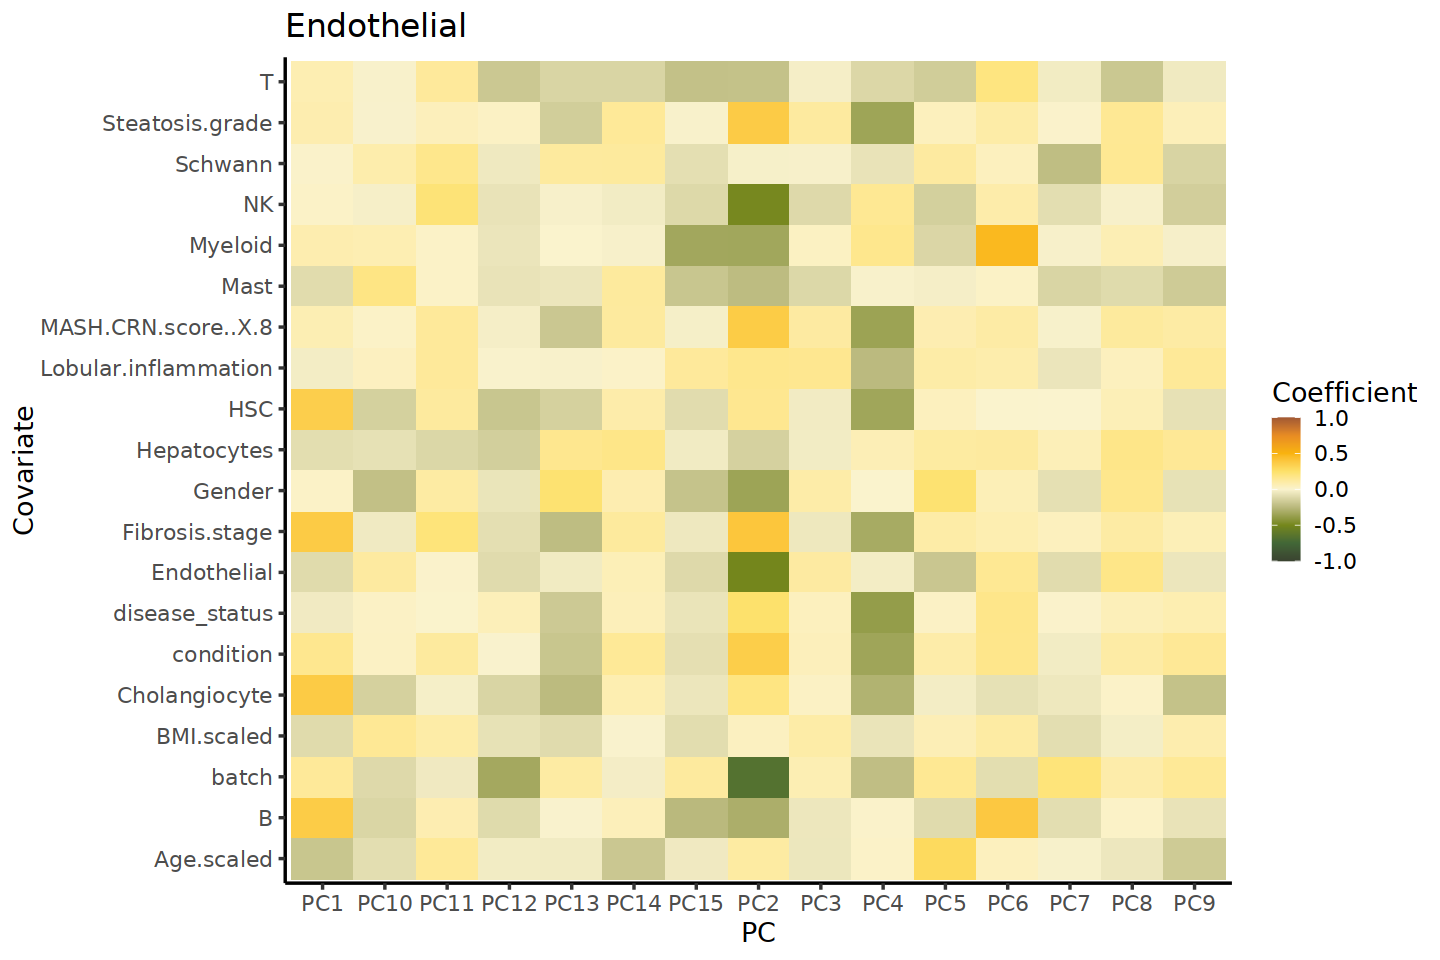

[1] "15 PCs cover 89.307% of variance for T"
[1] "HL210621 is an outlier on PC3 for T"
[1] "HL230325 is an outlier on PC6 for T"
[1] "HL190827 is an outlier on PC9 for T"
[1] "HL221019 is an outlier on PC11 for T"
[1] "HL170065 is an outlier on PC12 for T"


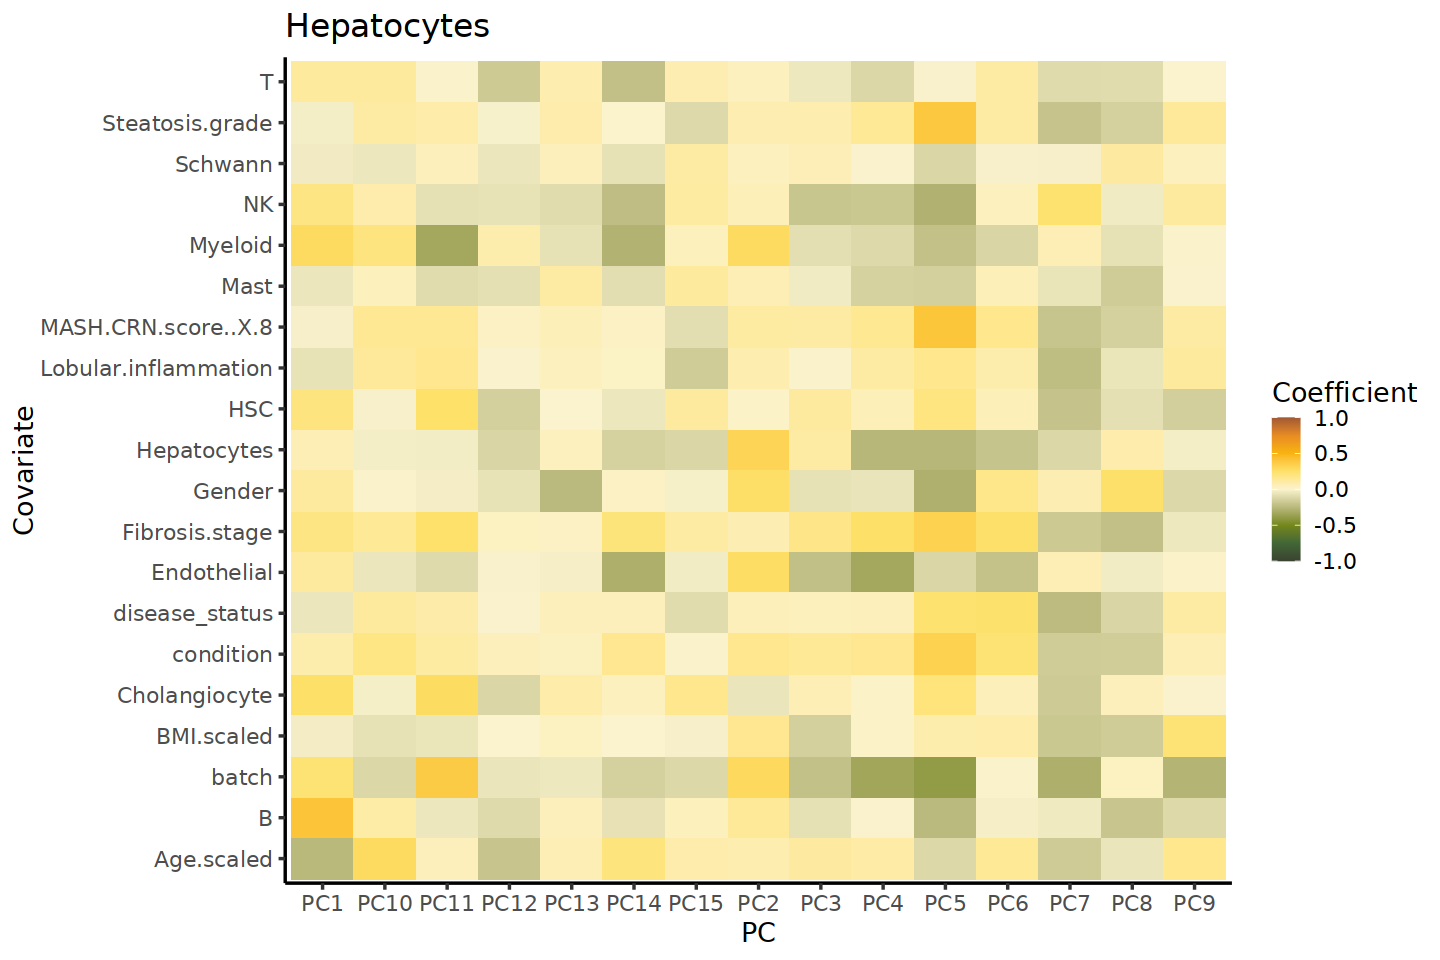

[1] "15 PCs cover 88.143% of variance for HSC"
[1] "HL160026 is an outlier on PC1 for HSC"
[1] "HL160026 is an outlier on PC2 for HSC"
[1] "HL191002 is an outlier on PC5 for HSC"
[2] "HL160026 is an outlier on PC5 for HSC"
[1] "HL221215 is an outlier on PC8 for HSC"
[1] "HL230302 is an outlier on PC9 for HSC"
[1] "HL220216 is an outlier on PC12 for HSC"
[1] "HL210614 is an outlier on PC14 for HSC"


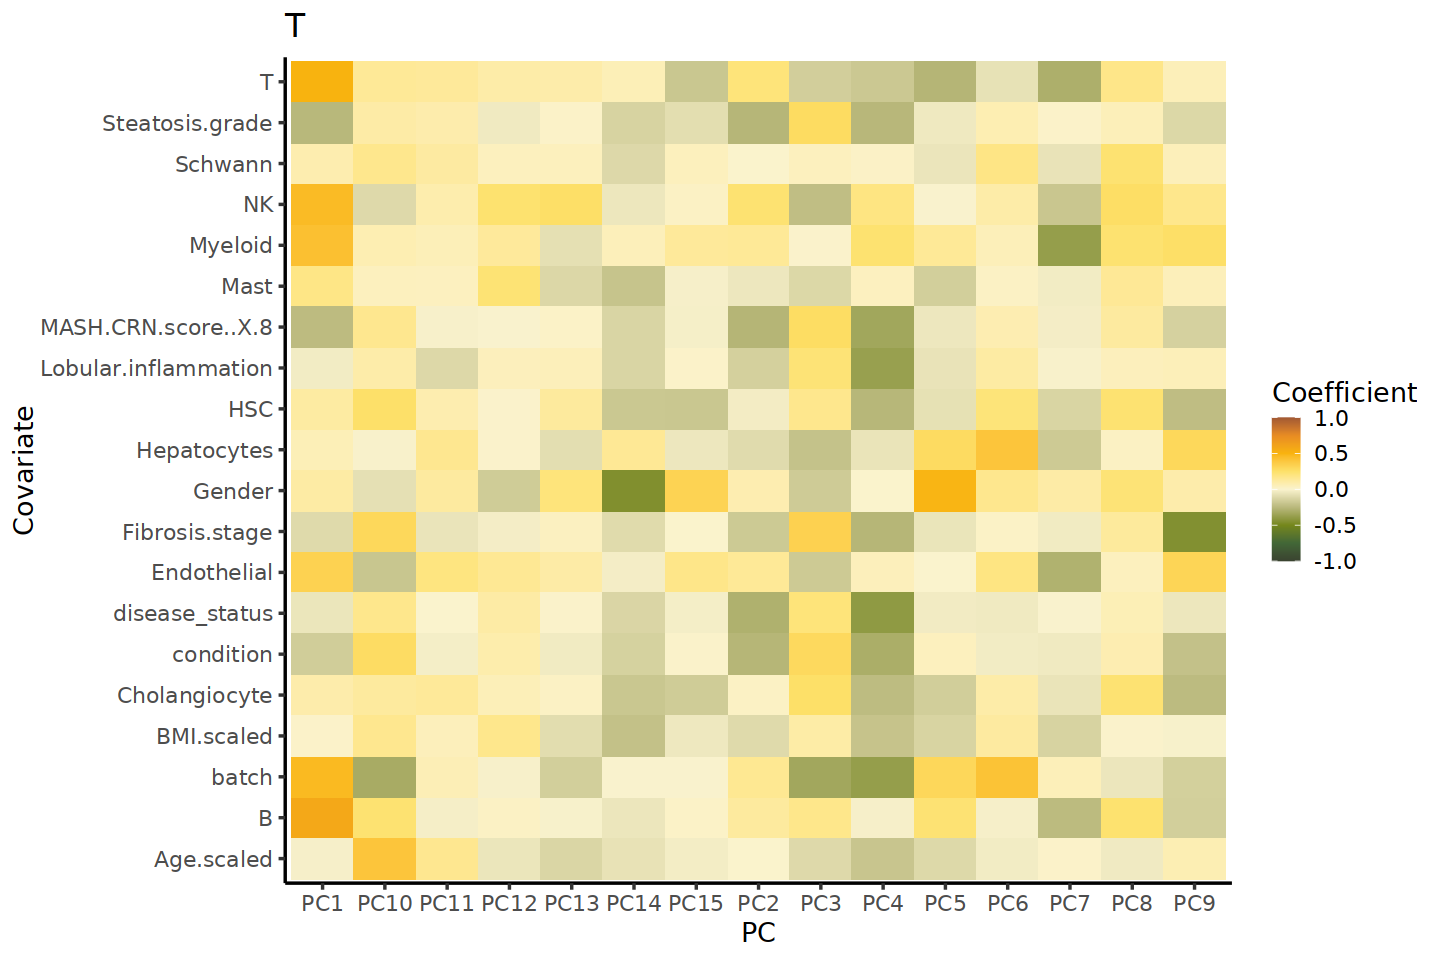

[1] "15 PCs cover 90.784% of variance for Cholangiocyte"
[1] "HL181010 is an outlier on PC1 for Cholangiocyte"
[1] "HL220216 is an outlier on PC6 for Cholangiocyte"
[1] "HL170052 is an outlier on PC7 for Cholangiocyte"
[1] "HL211106 is an outlier on PC8 for Cholangiocyte"
[1] "HL170060 is an outlier on PC15 for Cholangiocyte"


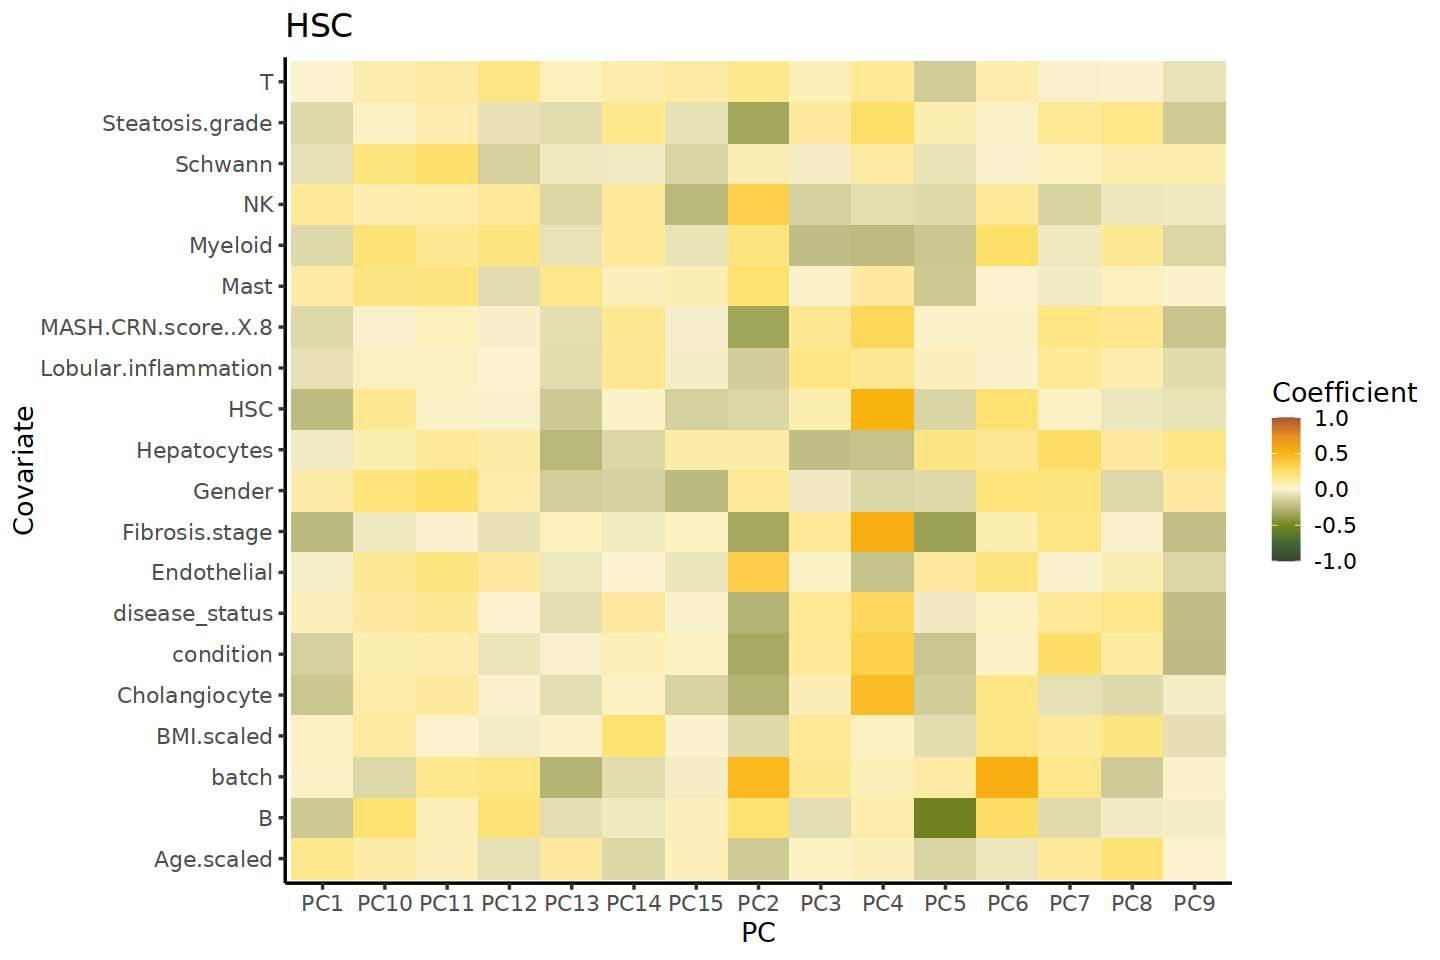

[1] "15 PCs cover 94.146% of variance for Myeloid"
[1] "HL221119 is an outlier on PC1 for Myeloid"
[2] "HL211106 is an outlier on PC1 for Myeloid"
[1] "HL190606 is an outlier on PC2 for Myeloid"
[1] "HL211106 is an outlier on PC4 for Myeloid"
[1] "HL221119 is an outlier on PC5 for Myeloid"
[2] "HL211106 is an outlier on PC5 for Myeloid"
[1] "HL190606 is an outlier on PC7 for Myeloid"
[2] "HL211106 is an outlier on PC7 for Myeloid"
[1] "HL200212 is an outlier on PC8 for Myeloid"
[1] "HL220216 is an outlier on PC10 for Myeloid"
[1] "HL190606 is an outlier on PC11 for Myeloid"
[1] "HL190827 is an outlier on PC13 for Myeloid"


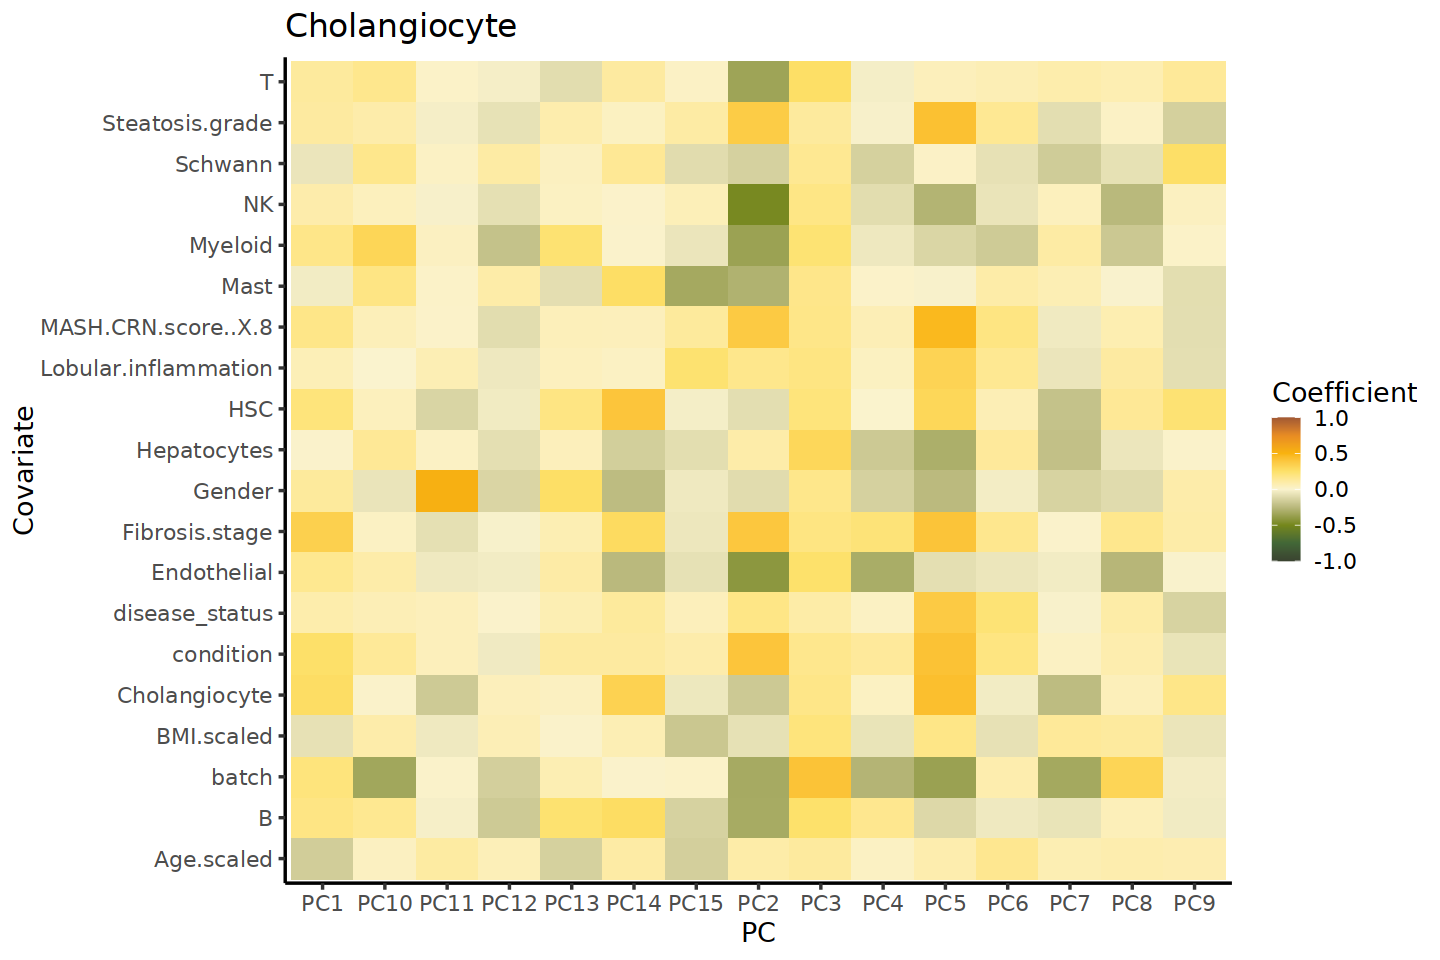

[1] "15 PCs cover 86.056% of variance for NK"
[1] "HL210614 is an outlier on PC4 for NK"
[2] "HL221119 is an outlier on PC4 for NK"
[1] "HL160017 is an outlier on PC5 for NK"
[1] "HL220825 is an outlier on PC9 for NK"
[1] "HL190214 is an outlier on PC11 for NK"
[1] "HL220613 is an outlier on PC12 for NK"
[1] "HL220825 is an outlier on PC14 for NK"
[2] "HL181010 is an outlier on PC14 for NK"
[1] "HL181029 is an outlier on PC15 for NK"


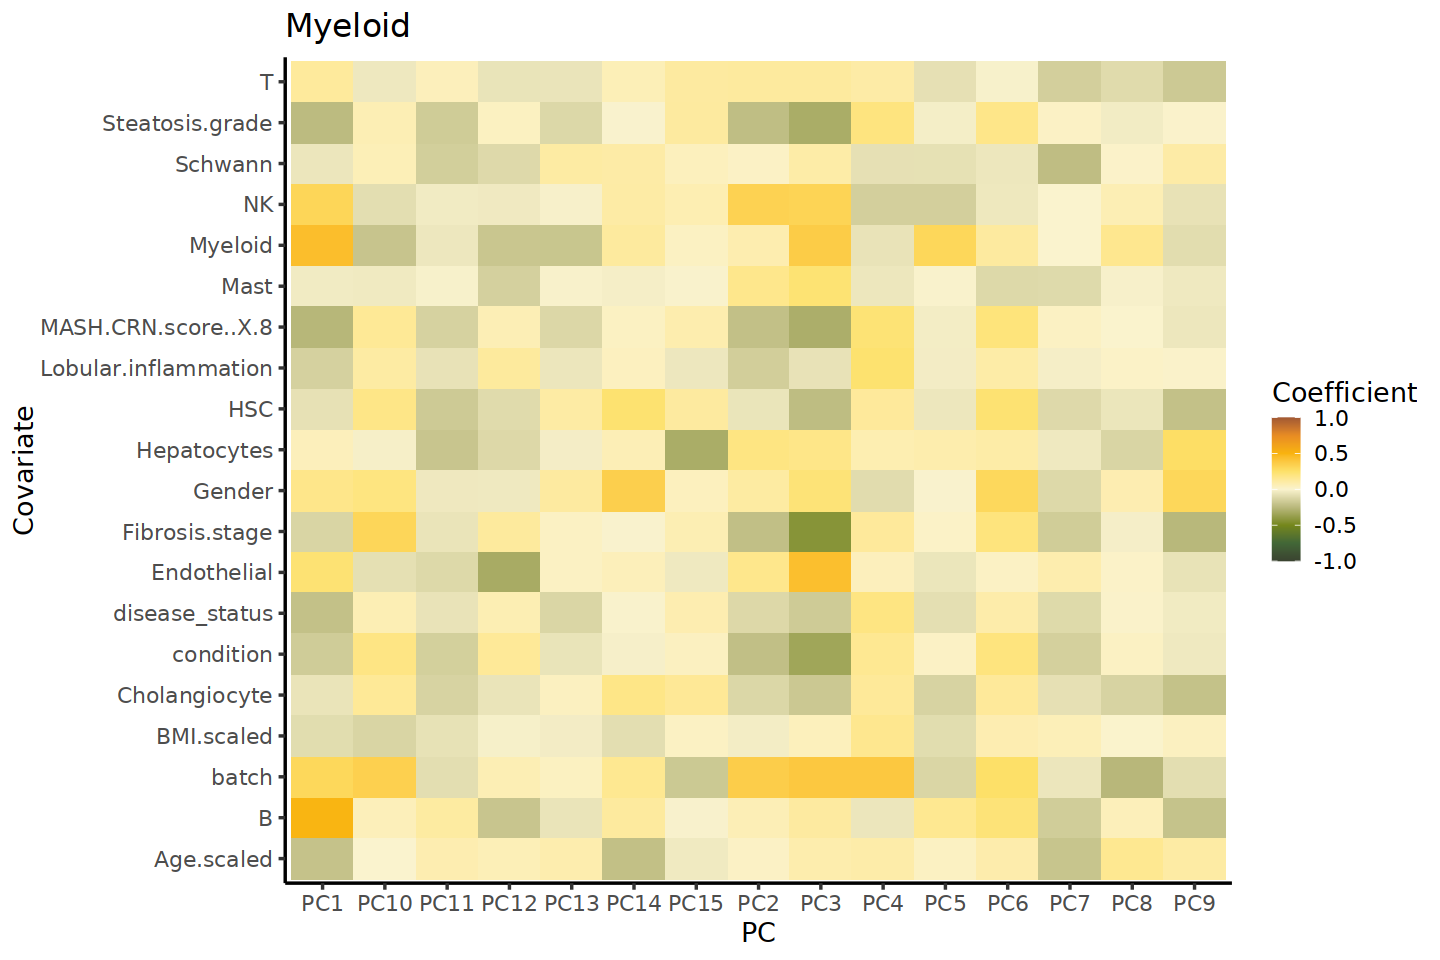

[1] "15 PCs cover 93.411% of variance for B"
[1] "HL220210 is an outlier on PC2 for B" "HL220402 is an outlier on PC2 for B"
[3] "HL160041 is an outlier on PC2 for B"
[1] "HL220613 is an outlier on PC3 for B"
[1] "HL211106 is an outlier on PC5 for B" "HL201024 is an outlier on PC5 for B"
[1] "HL190214 is an outlier on PC6 for B" "HL160041 is an outlier on PC6 for B"
[3] "HL160026 is an outlier on PC6 for B"
[1] "HL220402 is an outlier on PC7 for B" "HL190214 is an outlier on PC7 for B"
[3] "HL160026 is an outlier on PC7 for B"
[1] "HL220628 is an outlier on PC8 for B"
[1] "HL191025 is an outlier on PC9 for B"
[1] "HL201120 is an outlier on PC10 for B"
[1] "HL201120 is an outlier on PC11 for B"
[1] "HL211001 is an outlier on PC12 for B"
[1] "HL201024 is an outlier on PC13 for B"


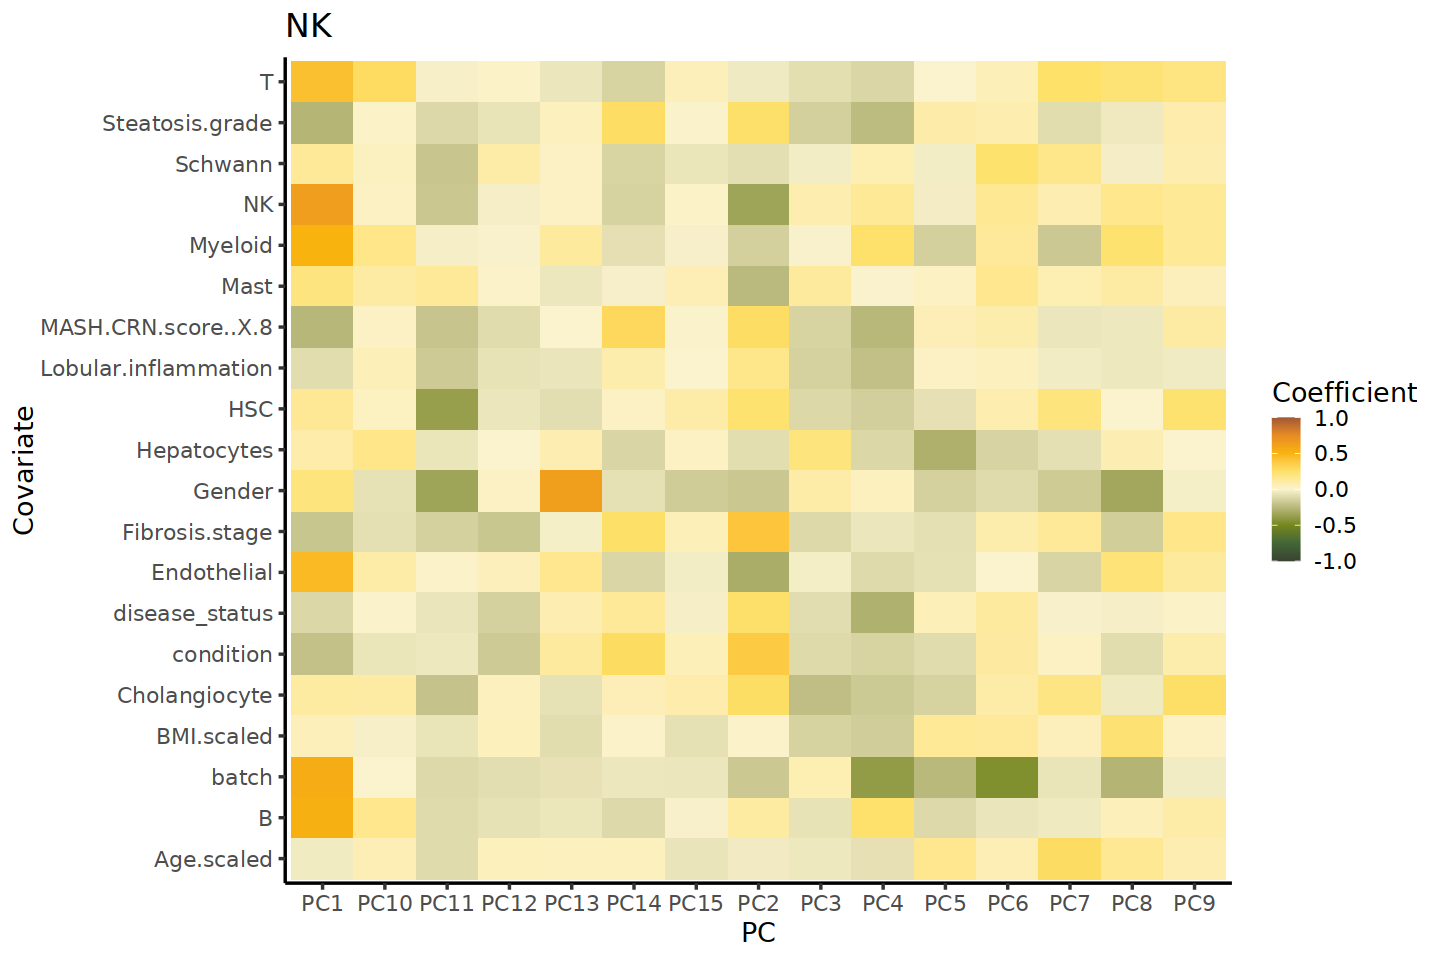

[1] "15 PCs cover 91.547% of variance for Bulk"
[1] "HL160017 is an outlier on PC2 for Bulk"
[1] "HL170062 is an outlier on PC7 for Bulk"
[1] "HL170060 is an outlier on PC8 for Bulk"
[1] "HL211106 is an outlier on PC9 for Bulk"
[1] "HL160026 is an outlier on PC10 for Bulk"
[1] "HL190909 is an outlier on PC11 for Bulk"
[1] "HL230325 is an outlier on PC12 for Bulk"
[2] "HL211106 is an outlier on PC12 for Bulk"
[3] "HL220613 is an outlier on PC12 for Bulk"
[1] "HL221215 is an outlier on PC13 for Bulk"
[1] "HL221119 is an outlier on PC14 for Bulk"
[2] "HL190215 is an outlier on PC14 for Bulk"
[3] "HL211001 is an outlier on PC14 for Bulk"
[1] "HL221006 is an outlier on PC15 for Bulk"
[2] "HL221119 is an outlier on PC15 for Bulk"


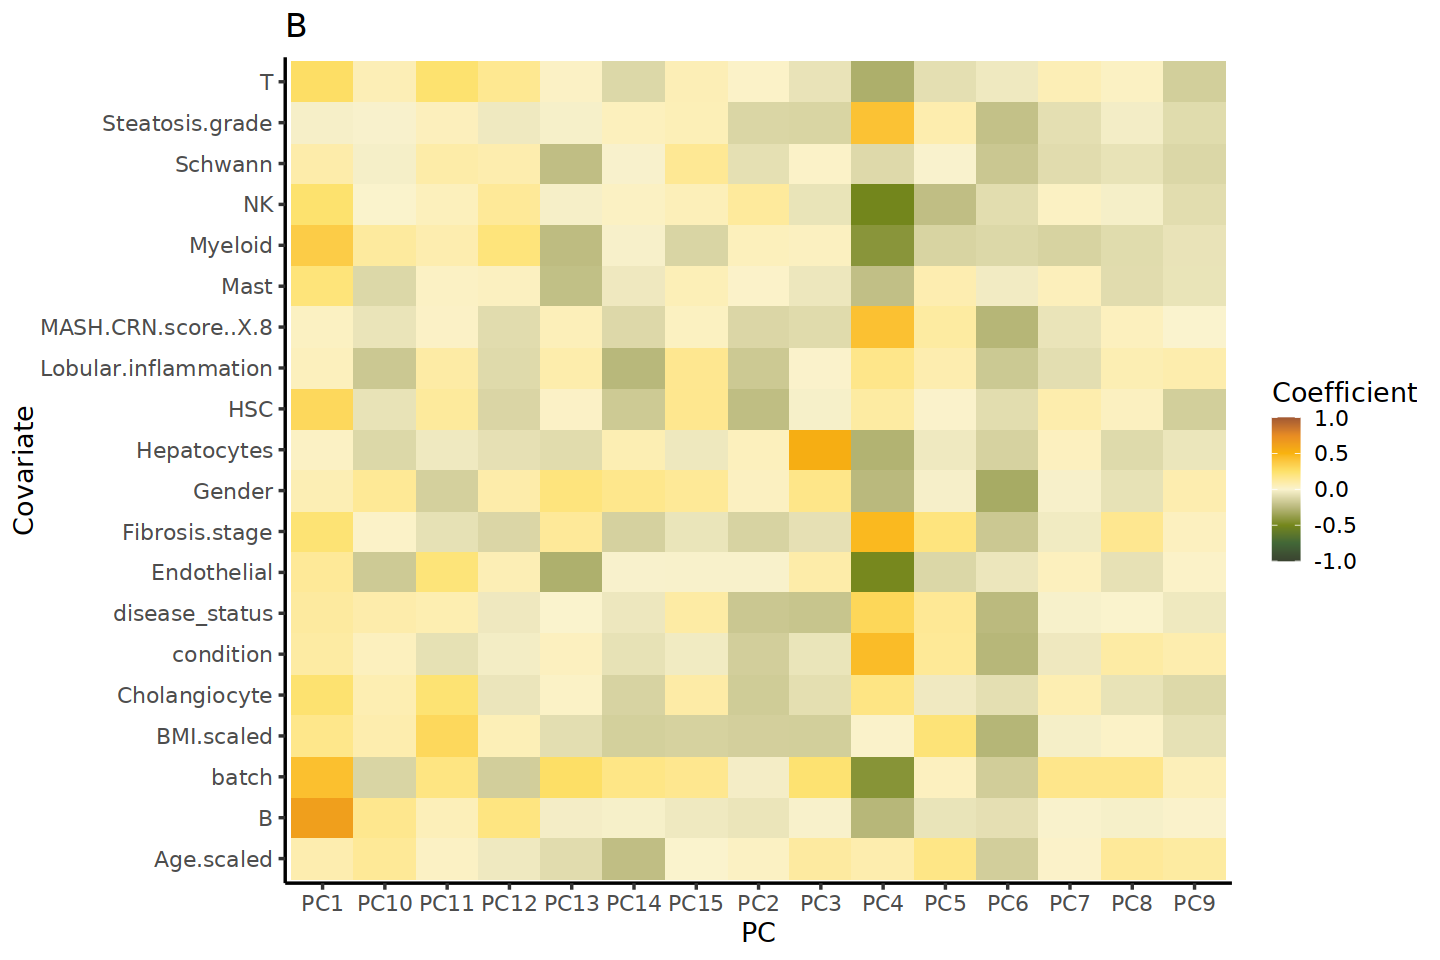

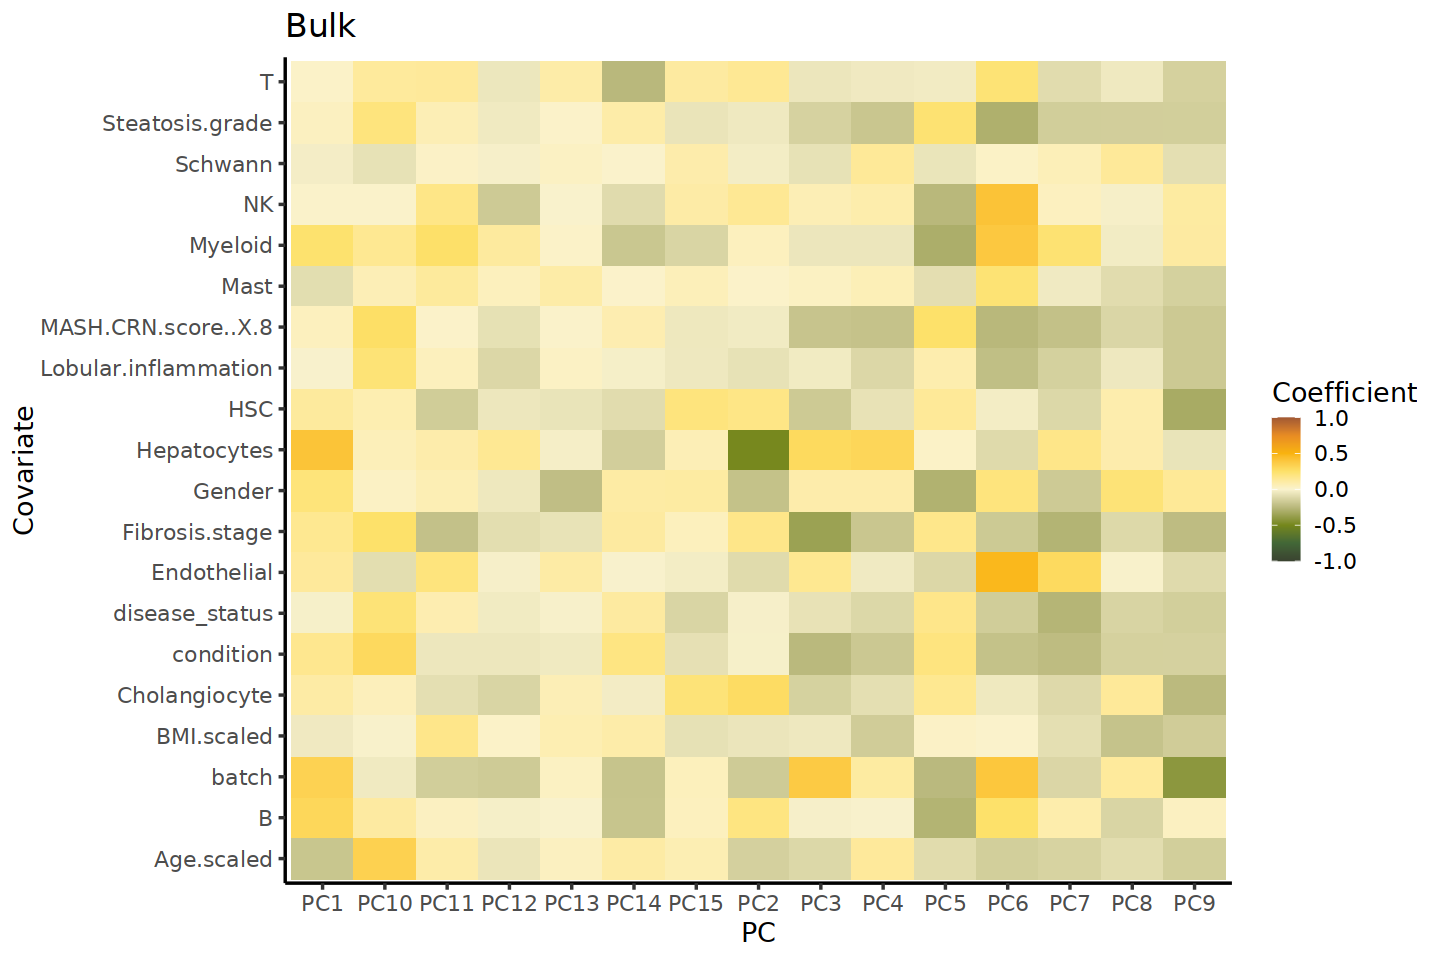

In [7]:
indir <- '/nfs/lab/projects/nash_nafld_liver/downstream_all/count.matrices/RNA/'
outdir <- '/nfs/lab/projects/nash_nafld_liver/downstream_all/04_eQTLs/covariates/'

n_pc <- 15

##### NAME YOUR FILES #####
for (cell.type in unique_cell_types){
    if (cell.type %in% c('Mast','Schwann')) {
        next
    }
    tmm.filename <- paste(indir, cell.type, '_perdonor.RNA.TMM.tsv', sep = "")
    #int.filename <- paste(indir, cell.type, '_perdonor.RNA.INT.tsv', sep = "")
    pc.filename <- paste(outdir, cell.type, '_perdonor.RNA.TMM.', n_pc,'.PCs.tsv', sep = "")
    cor.filename <- paste(outdir, cell.type, '_perdonor.RNA.TMM.', n_pc,'.PCs.correlation.tsv', sep = "")
    make_PC_covariate_mat(cell.type, expr.mat.filename=tmm.filename, pc.filename,
                          cor.filename, n_pc=15, meta)
}

[1] "15 PCs cover 49.124% of variance for Endothelial"
[1] "HL181029 is an outlier on PC1 for Endothelial"
[1] "HL210806 is an outlier on PC5 for Endothelial"
[2] "HL220216 is an outlier on PC5 for Endothelial"
[1] "HL160026 is an outlier on PC12 for Endothelial"
[1] "HL200707 is an outlier on PC15 for Endothelial"
[2] "HL180071 is an outlier on PC15 for Endothelial"
[1] "15 PCs cover 43.55% of variance for Hepatocytes"
[1] "HL230302 is an outlier on PC3 for Hepatocytes"
[2] "HL180071 is an outlier on PC3 for Hepatocytes"
[1] "HL170049 is an outlier on PC4 for Hepatocytes"
[1] "HL230302 is an outlier on PC5 for Hepatocytes"
[2] "HL180071 is an outlier on PC5 for Hepatocytes"
[1] "HL221019 is an outlier on PC6 for Hepatocytes"
[2] "HL220216 is an outlier on PC6 for Hepatocytes"
[1] "HL190214 is an outlier on PC7 for Hepatocytes"
[1] "HL230302 is an outlier on PC8 for Hepatocytes"
[2] "HL190214 is an outlier on PC8 for Hepatocytes"
[1] "HL221019 is an outlier on PC9 for Hepatocytes"
[2] 

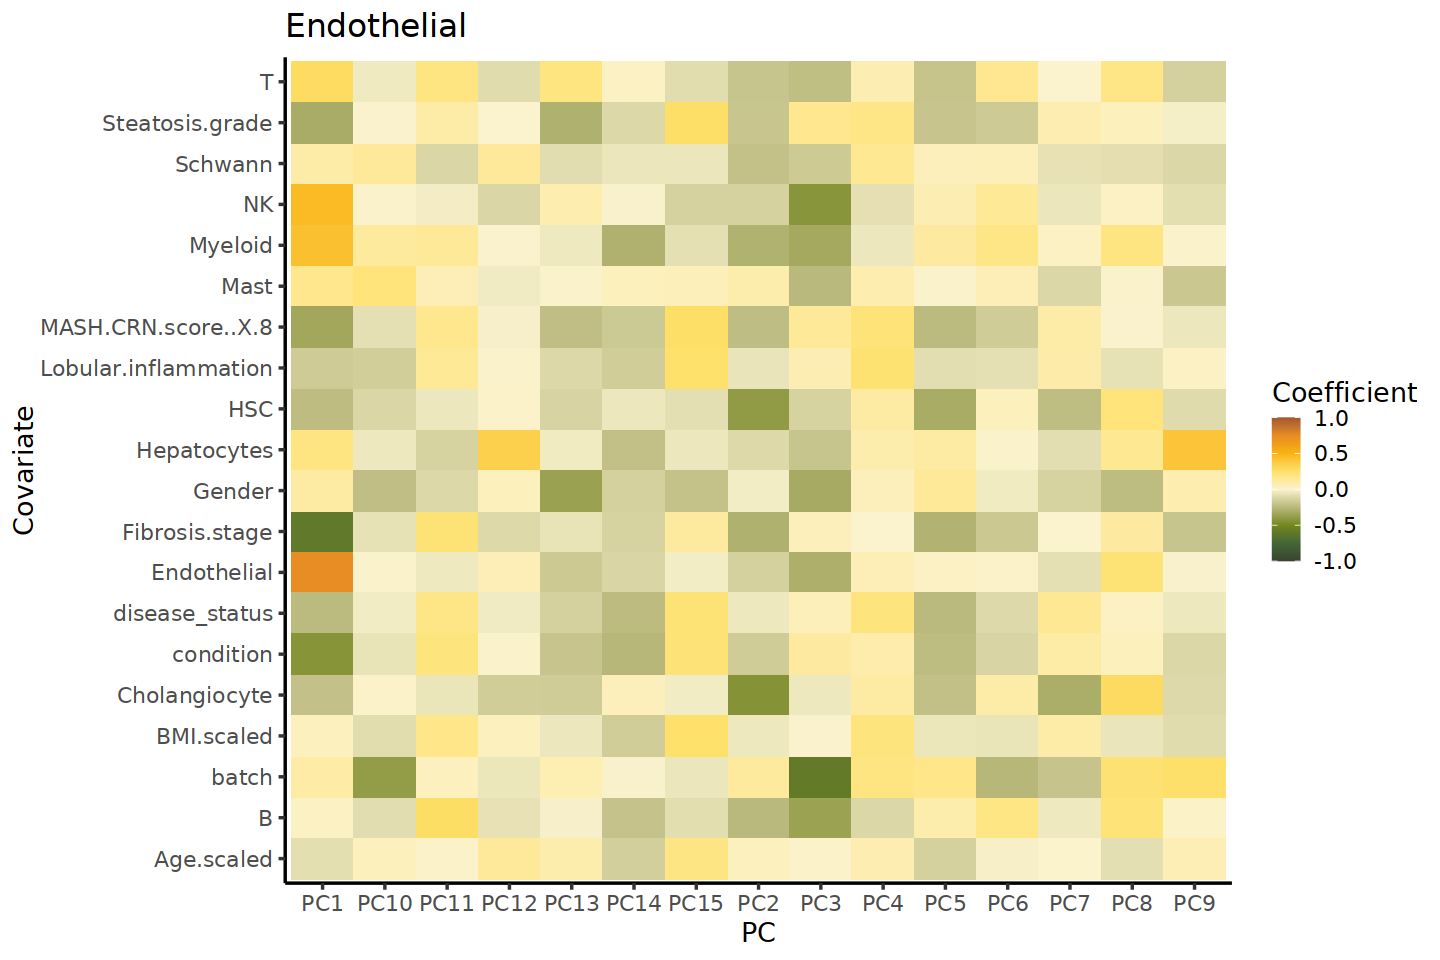

[1] "15 PCs cover 54.808% of variance for T"
[1] "HL220825 is an outlier on PC2 for T"
[1] "HL170047 is an outlier on PC3 for T"
[1] "HL170047 is an outlier on PC5 for T"
[1] "HL220825 is an outlier on PC6 for T"
[1] "HL221019 is an outlier on PC7 for T"
[1] "HL190214 is an outlier on PC8 for T" "HL160026 is an outlier on PC8 for T"
[1] "HL221019 is an outlier on PC9 for T" "HL160041 is an outlier on PC9 for T"
[1] "HL221019 is an outlier on PC10 for T"
[2] "HL190214 is an outlier on PC10 for T"
[3] "HL160041 is an outlier on PC10 for T"
[1] "HL190214 is an outlier on PC11 for T"
[2] "HL160041 is an outlier on PC11 for T"
[3] "HL160026 is an outlier on PC11 for T"
[4] "HL211001 is an outlier on PC11 for T"
[1] "HL170060 is an outlier on PC12 for T"
[1] "HL160042 is an outlier on PC13 for T"
[2] "HL221019 is an outlier on PC13 for T"
[1] "HL211001 is an outlier on PC14 for T"
[1] "HL200707 is an outlier on PC15 for T"
[2] "HL220613 is an outlier on PC15 for T"


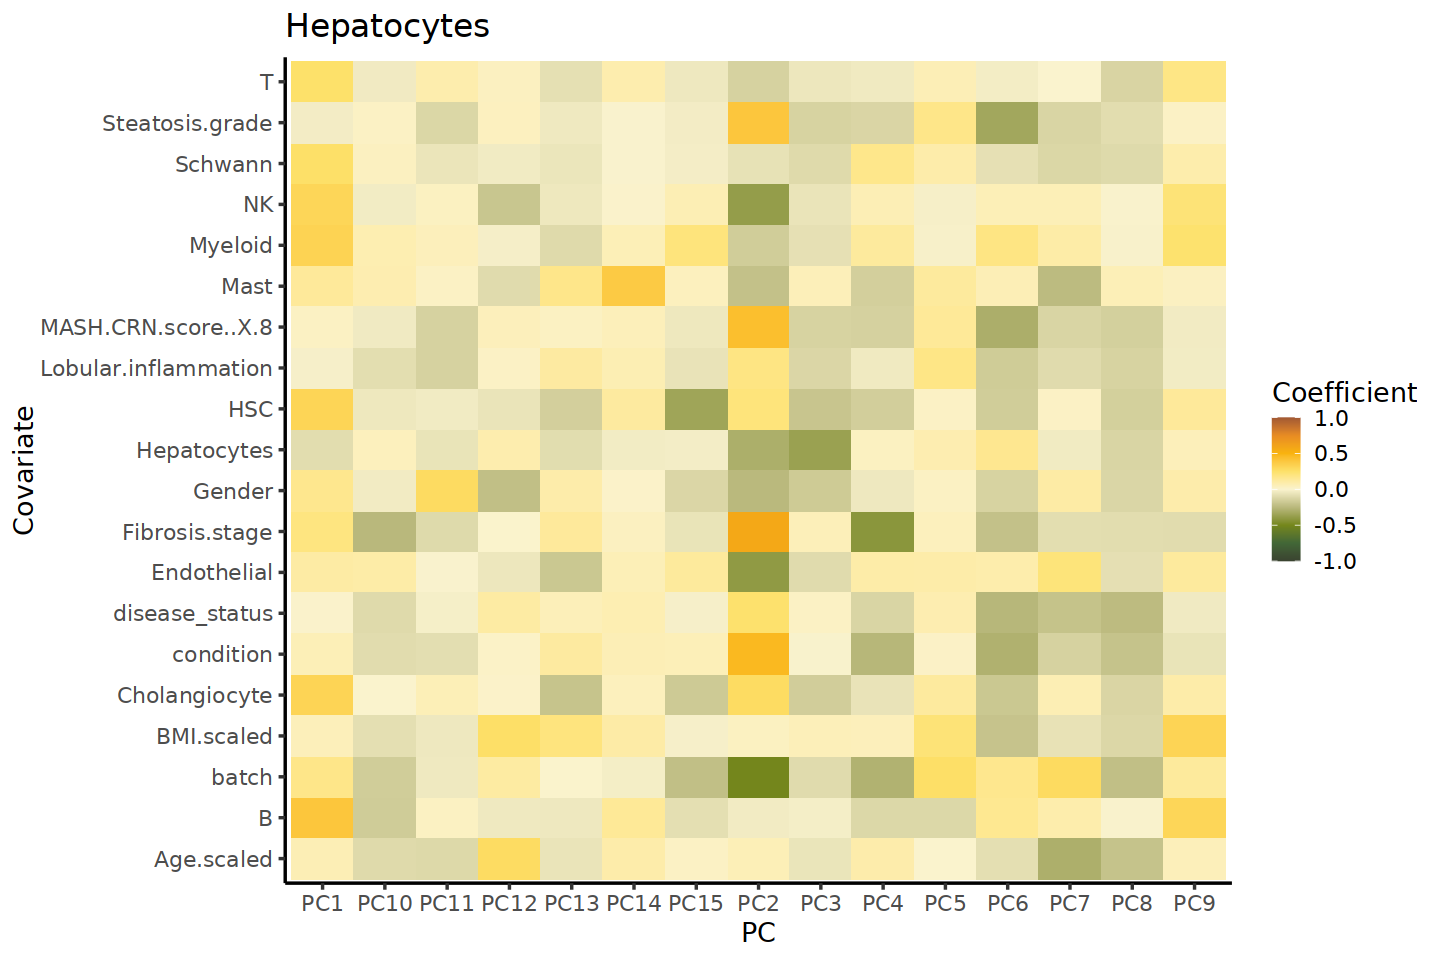

[1] "15 PCs cover 47.616% of variance for HSC"
[1] "HL220216 is an outlier on PC9 for HSC"
[2] "HL160041 is an outlier on PC9 for HSC"
[1] "HL211106 is an outlier on PC10 for HSC"
[1] "HL190214 is an outlier on PC11 for HSC"
[2] "HL170047 is an outlier on PC11 for HSC"
[1] "HL160041 is an outlier on PC12 for HSC"
[2] "HL220613 is an outlier on PC12 for HSC"
[1] "HL170047 is an outlier on PC13 for HSC"
[2] "HL160041 is an outlier on PC13 for HSC"
[1] "HL190214 is an outlier on PC14 for HSC"
[2] "HL221201 is an outlier on PC14 for HSC"
[1] "HL221201 is an outlier on PC15 for HSC"
[2] "HL200212 is an outlier on PC15 for HSC"


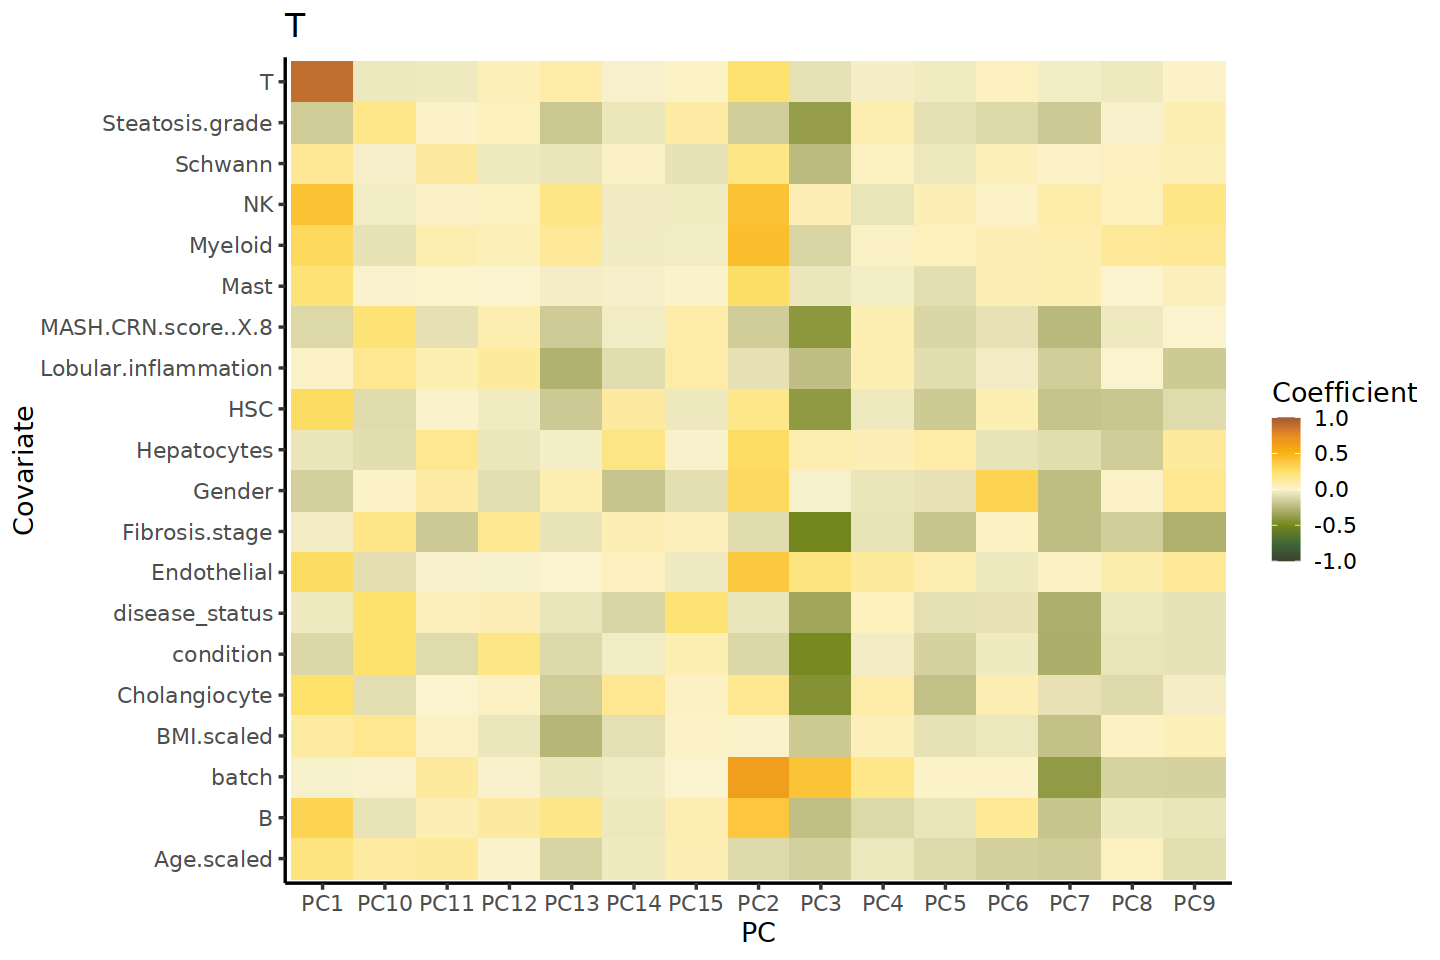

[1] "15 PCs cover 56.9% of variance for Cholangiocyte"
[1] "HL220216 is an outlier on PC4 for Cholangiocyte"
[1] "HL220825 is an outlier on PC7 for Cholangiocyte"
[1] "HL220825 is an outlier on PC8 for Cholangiocyte"
[2] "HL220613 is an outlier on PC8 for Cholangiocyte"
[3] "HL150009 is an outlier on PC8 for Cholangiocyte"
[1] "HL220825 is an outlier on PC9 for Cholangiocyte"
[2] "HL150009 is an outlier on PC9 for Cholangiocyte"
[1] "HL160042 is an outlier on PC10 for Cholangiocyte"
[2] "HL230302 is an outlier on PC10 for Cholangiocyte"
[3] "HL220613 is an outlier on PC10 for Cholangiocyte"
[4] "HL150009 is an outlier on PC10 for Cholangiocyte"
[1] "HL160042 is an outlier on PC11 for Cholangiocyte"
[2] "HL160029 is an outlier on PC11 for Cholangiocyte"
[3] "HL230302 is an outlier on PC11 for Cholangiocyte"
[1] "HL190214 is an outlier on PC12 for Cholangiocyte"
[2] "HL221201 is an outlier on PC12 for Cholangiocyte"
[3] "HL220613 is an outlier on PC12 for Cholangiocyte"
[1] "HL221201 is 

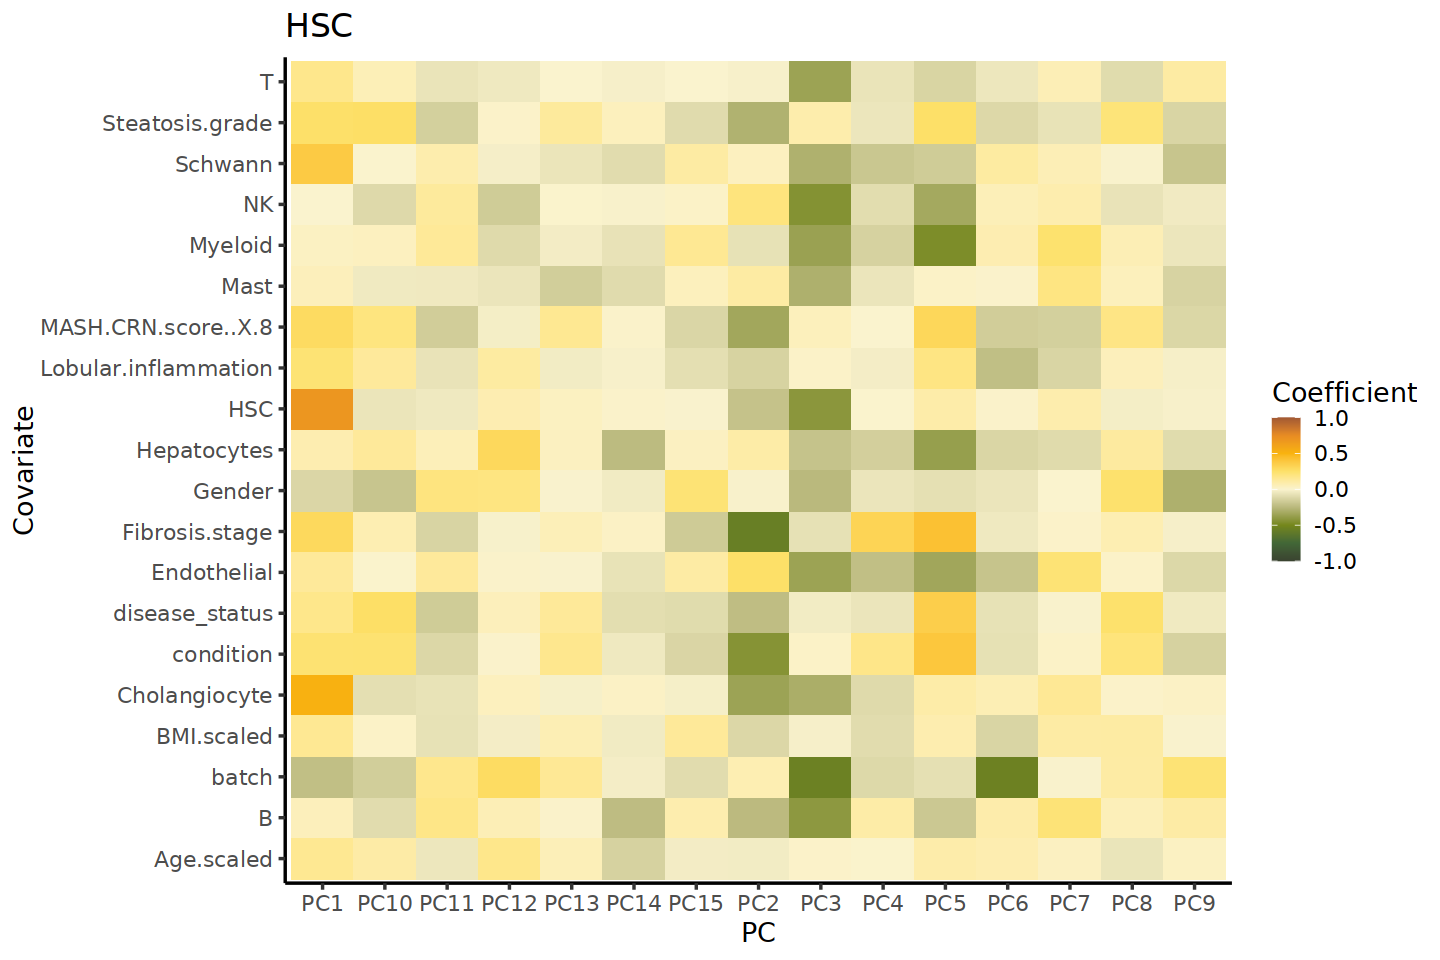

[1] "15 PCs cover 48.562% of variance for Myeloid"
[1] "HL160026 is an outlier on PC6 for Myeloid"
[1] "HL170047 is an outlier on PC7 for Myeloid"
[1] "HL160026 is an outlier on PC8 for Myeloid"
[1] "HL160026 is an outlier on PC9 for Myeloid"
[1] "HL150009 is an outlier on PC10 for Myeloid"
[1] "HL170060 is an outlier on PC11 for Myeloid"
[2] "HL220825 is an outlier on PC11 for Myeloid"
[1] "HL220825 is an outlier on PC12 for Myeloid"
[2] "HL221019 is an outlier on PC12 for Myeloid"
[3] "HL180071 is an outlier on PC12 for Myeloid"
[1] "HL160042 is an outlier on PC13 for Myeloid"
[2] "HL170060 is an outlier on PC13 for Myeloid"
[1] "HL160042 is an outlier on PC14 for Myeloid"
[1] "HL160042 is an outlier on PC15 for Myeloid"
[2] "HL200707 is an outlier on PC15 for Myeloid"


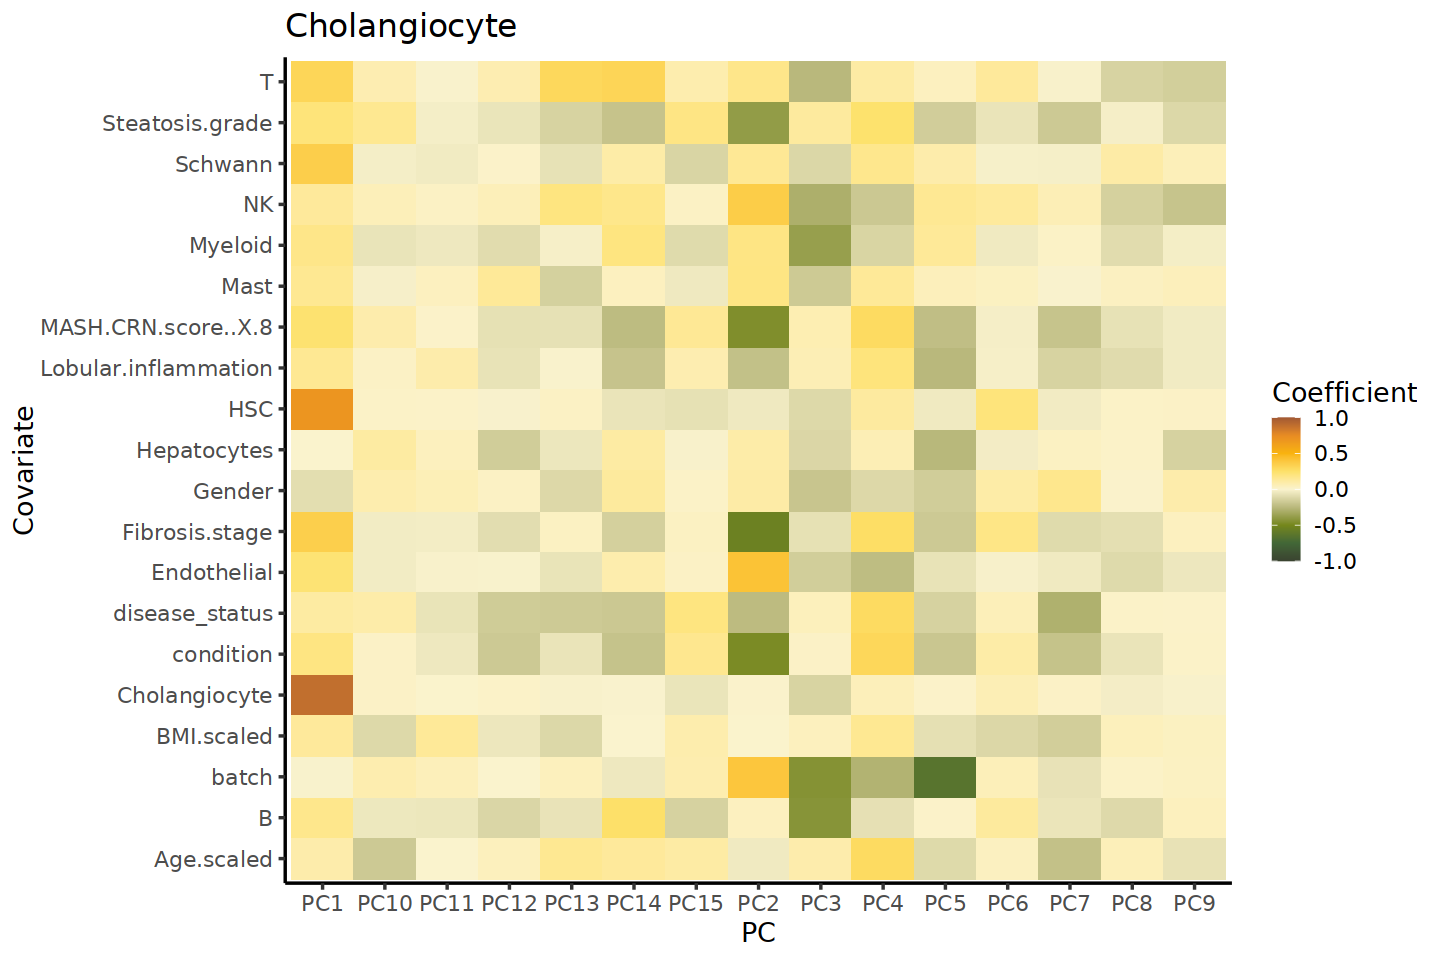

[1] "15 PCs cover 54.153% of variance for NK"
[1] "HL220825 is an outlier on PC4 for NK"
[1] "HL170060 is an outlier on PC5 for NK"
[1] "HL220613 is an outlier on PC6 for NK"
[1] "HL160042 is an outlier on PC7 for NK"
[1] "HL220613 is an outlier on PC8 for NK"
[1] "HL170060 is an outlier on PC9 for NK"
[2] "HL150009 is an outlier on PC9 for NK"
[1] "HL150009 is an outlier on PC10 for NK"
[1] "HL200707 is an outlier on PC11 for NK"
[2] "HL170049 is an outlier on PC11 for NK"
[1] "HL200707 is an outlier on PC12 for NK"
[2] "HL170049 is an outlier on PC12 for NK"
[1] "HL200707 is an outlier on PC13 for NK"
[2] "HL200615 is an outlier on PC13 for NK"
[1] "HL160029 is an outlier on PC14 for NK"
[2] "HL191025 is an outlier on PC14 for NK"
[1] "HL160029 is an outlier on PC15 for NK"
[2] "HL190114 is an outlier on PC15 for NK"


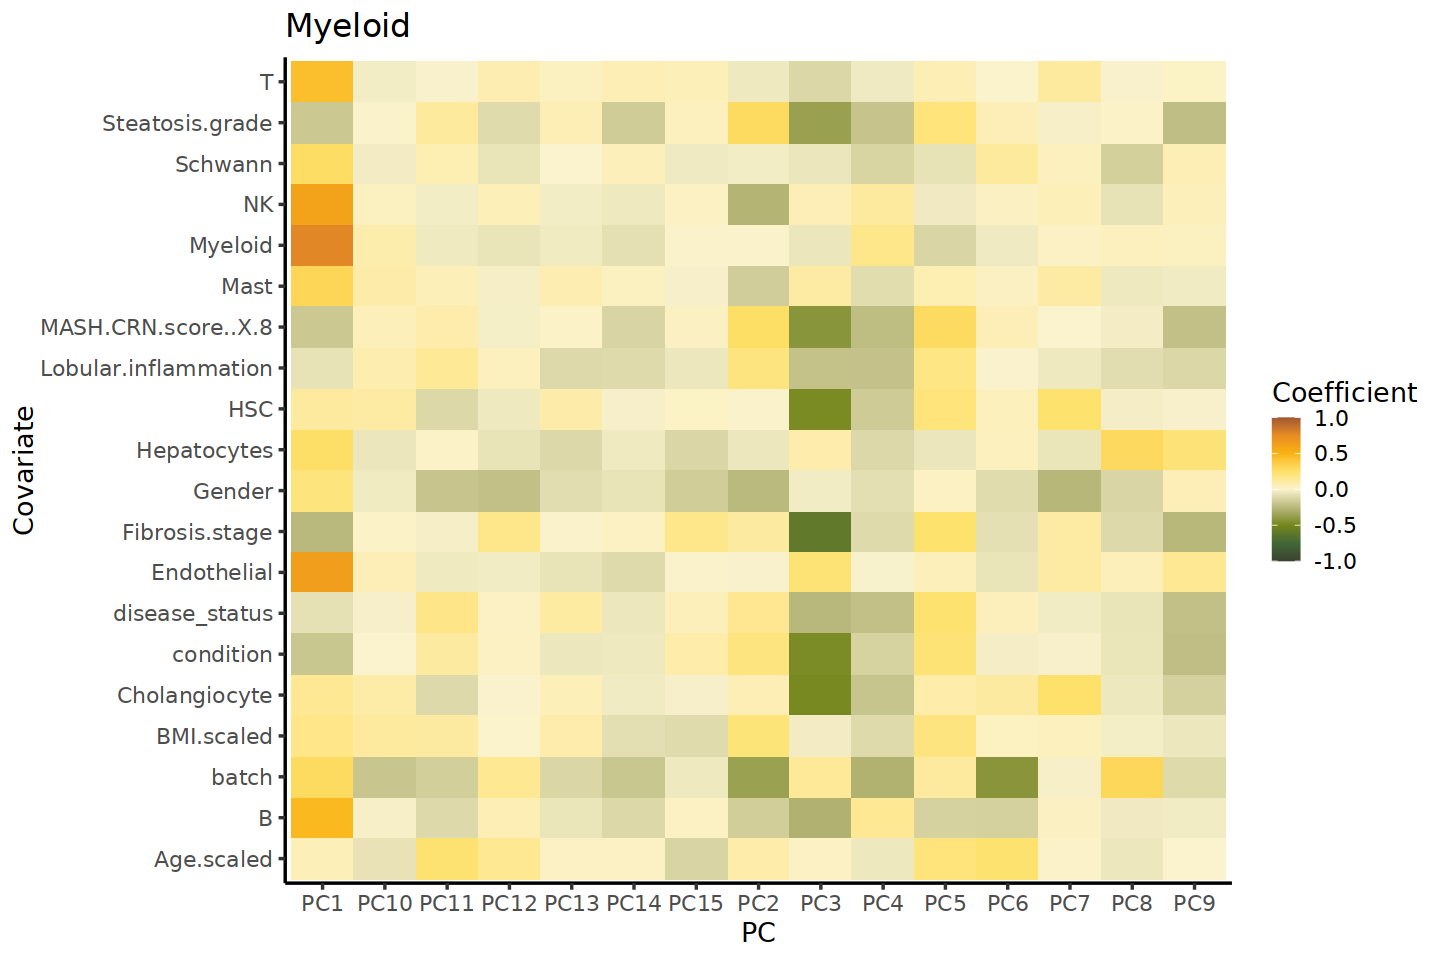

[1] "15 PCs cover 57.696% of variance for B"
[1] "HL221119 is an outlier on PC1 for B"
[1] "HL190326 is an outlier on PC2 for B"
[1] "HL160029 is an outlier on PC3 for B"
[1] "HL190326 is an outlier on PC4 for B" "HL160041 is an outlier on PC4 for B"
[1] "HL190326 is an outlier on PC5 for B" "HL160029 is an outlier on PC5 for B"
[3] "HL160041 is an outlier on PC5 for B"
[1] "HL160029 is an outlier on PC6 for B" "HL160041 is an outlier on PC6 for B"
[1] "HL160042 is an outlier on PC7 for B" "HL191025 is an outlier on PC7 for B"
[3] "HL170047 is an outlier on PC7 for B"
[1] "HL190326 is an outlier on PC8 for B"
[1] "HL160042 is an outlier on PC9 for B" "HL191025 is an outlier on PC9 for B"
[3] "HL170047 is an outlier on PC9 for B"
[1] "HL160042 is an outlier on PC10 for B"
[2] "HL200707 is an outlier on PC10 for B"
[1] "HL210120 is an outlier on PC11 for B"
[2] "HL200707 is an outlier on PC11 for B"
[3] "HL200115 is an outlier on PC11 for B"
[4] "HL190214 is an outlier on PC11 for B"
[1]

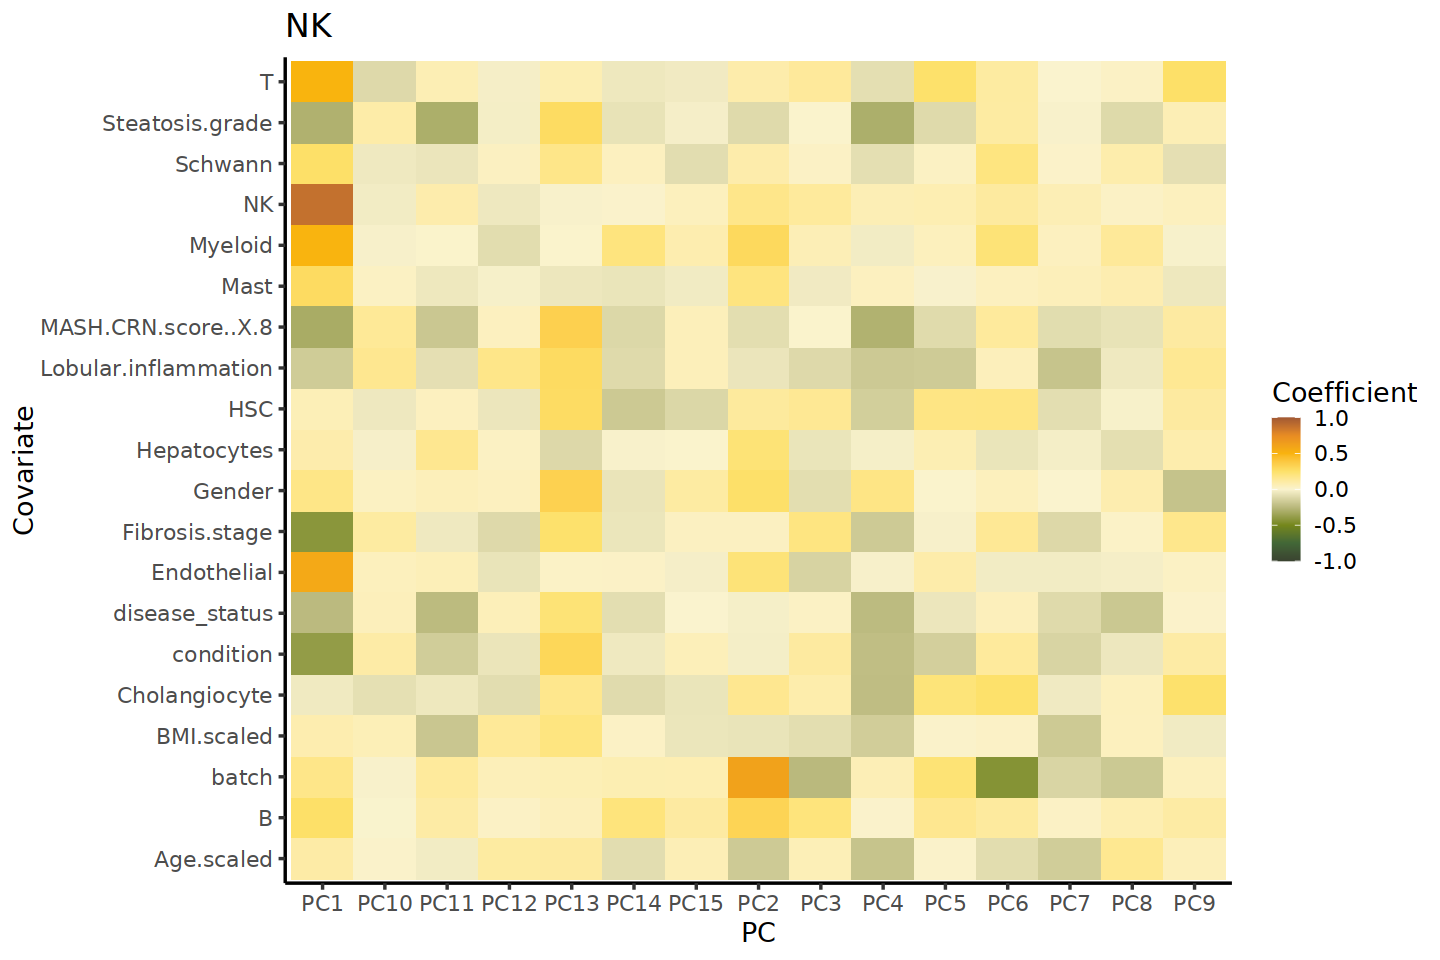

[1] "15 PCs cover 52.565% of variance for Bulk"
[1] "HL200707 is an outlier on PC5 for Bulk"
[2] "HL180071 is an outlier on PC5 for Bulk"
[1] "HL190214 is an outlier on PC7 for Bulk"
[2] "HL180071 is an outlier on PC7 for Bulk"
[1] "HL220825 is an outlier on PC8 for Bulk"
[2] "HL230302 is an outlier on PC8 for Bulk"
[3] "HL180071 is an outlier on PC8 for Bulk"
[1] "HL221019 is an outlier on PC9 for Bulk"
[1] "HL220825 is an outlier on PC10 for Bulk"
[2] "HL190624 is an outlier on PC10 for Bulk"
[3] "HL180071 is an outlier on PC10 for Bulk"
[1] "HL220825 is an outlier on PC11 for Bulk"
[2] "HL190624 is an outlier on PC11 for Bulk"
[3] "HL230302 is an outlier on PC11 for Bulk"
[1] "HL200707 is an outlier on PC12 for Bulk"
[2] "HL200529 is an outlier on PC12 for Bulk"
[1] "HL230302 is an outlier on PC13 for Bulk"
[1] "HL191025 is an outlier on PC14 for Bulk"
[2] "HL170047 is an outlier on PC14 for Bulk"
[1] "HL191025 is an outlier on PC15 for Bulk"
[2] "HL170047 is an outlier on PC15 for 

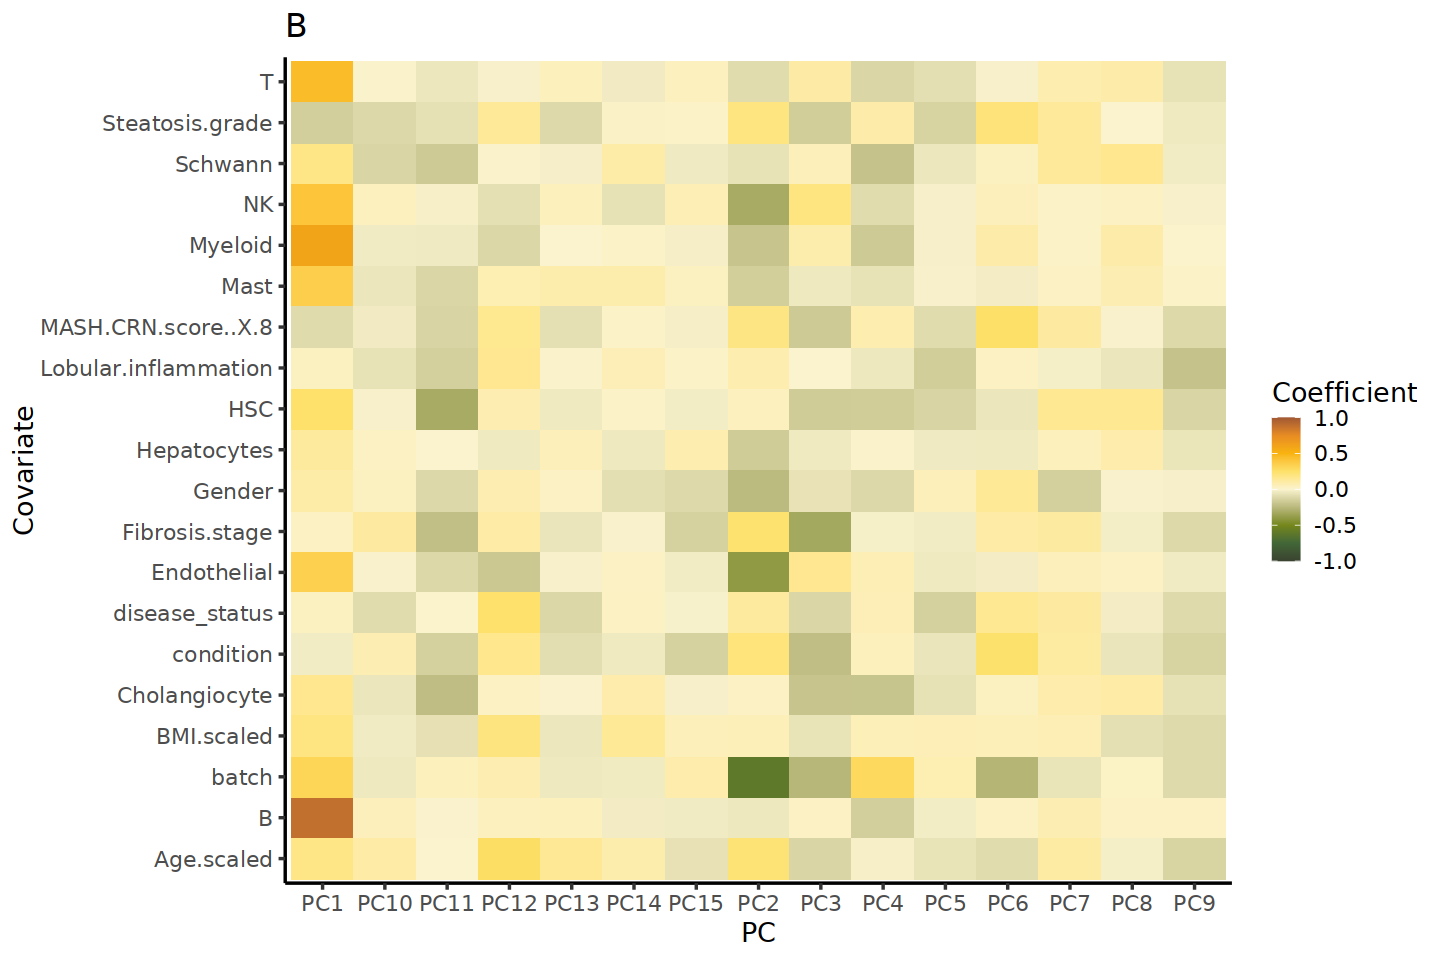

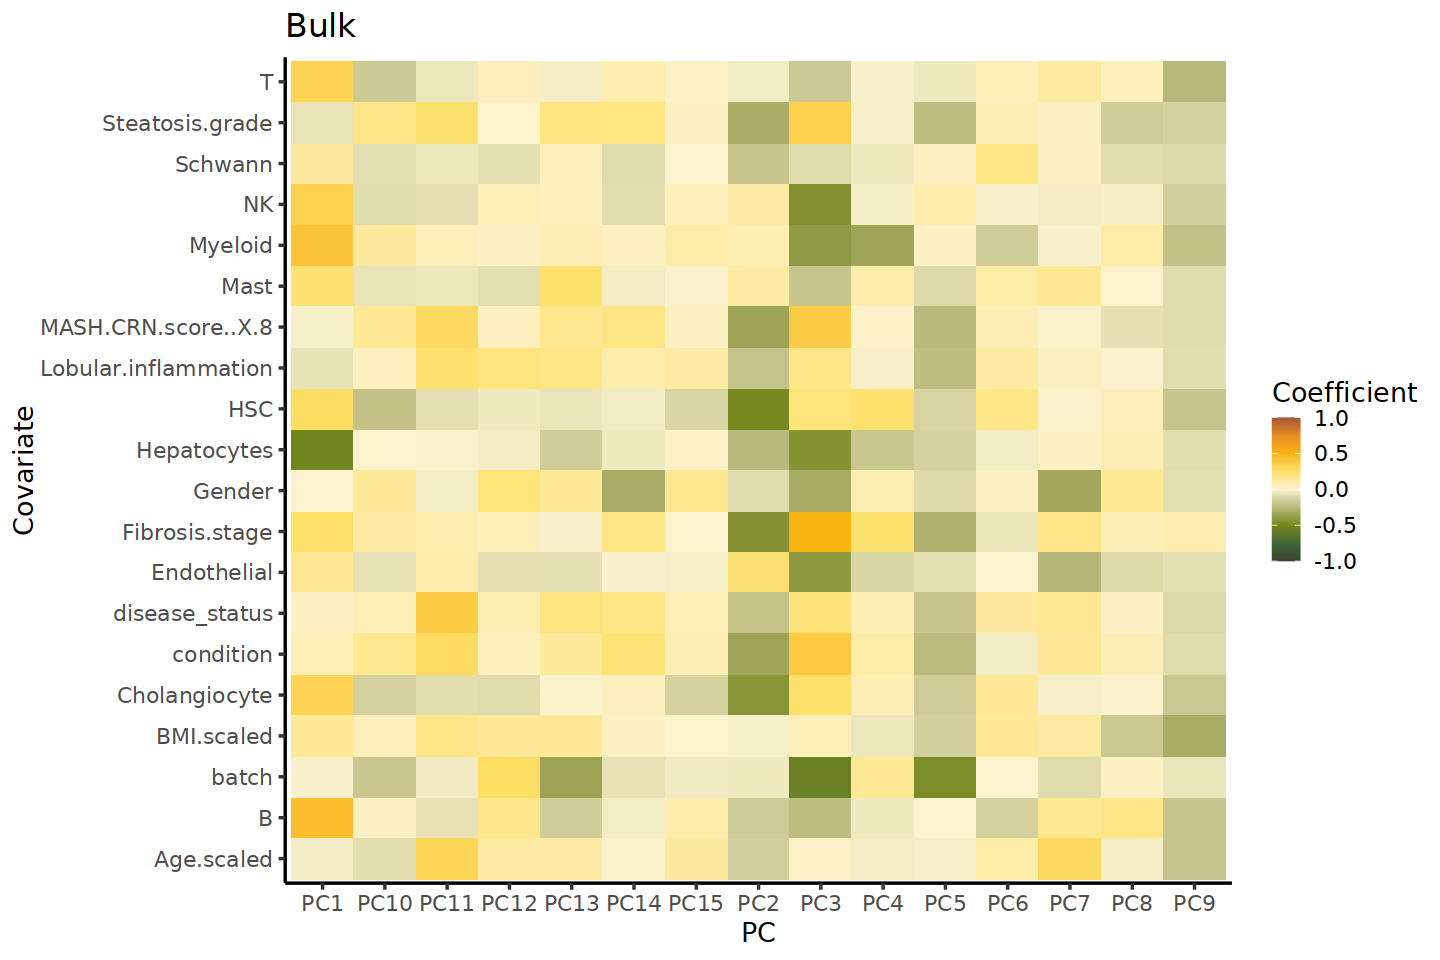

In [8]:
indir <- '/nfs/lab/projects/nash_nafld_liver/downstream_all/count.matrices/ATAC/'
outdir <- '/nfs/lab/projects/nash_nafld_liver/downstream_all/05_caQTLs/covariates/'

n_pc <- 15

##### NAME YOUR FILES #####
for (cell.type in unique_cell_types){
    # Not enough stuff for these cell types
    if (cell.type %in% c('Mast','Schwann')) {
        next
    }
    #tmm.filename <- paste(indir, cell.type, '_perdonor.ATAC.TMM.tsv', sep = "")
    int.filename <- paste(indir, cell.type, '_perdonor.ATAC.INT.tsv', sep = "")
    pc.filename <- paste(outdir, cell.type, '_perdonor.ATAC.INT.', n_pc,'.PCs.tsv', sep = "")
    cor.filename <- paste(outdir, cell.type, '_perdonor.ATAC.INT.', n_pc,'.PCs.correlation.tsv', sep = "")
    make_PC_covariate_mat(cell.type, expr.mat.filename=int.filename, pc.filename, 
                          cor.filename, n_pc=15, meta)
}

[1] "15 PCs cover 76.653% of variance for Endothelial"
[1] "HL170048 is an outlier on PC1 for Endothelial"
[1] "HL220825 is an outlier on PC4 for Endothelial"
[1] "HL210207 is an outlier on PC5 for Endothelial"
[1] "HL210806 is an outlier on PC6 for Endothelial"
[2] "HL170049 is an outlier on PC6 for Endothelial"
[1] "HL230325 is an outlier on PC7 for Endothelial"
[1] "HL220405 is an outlier on PC10 for Endothelial"
[1] "HL200212 is an outlier on PC11 for Endothelial"
[1] "HL220825 is an outlier on PC12 for Endothelial"
[1] "HL230302 is an outlier on PC13 for Endothelial"
[1] "HL230325 is an outlier on PC14 for Endothelial"
[1] "HL160029 is an outlier on PC15 for Endothelial"
[1] "15 PCs cover 88.272% of variance for Hepatocytes"
[1] "HL160029 is an outlier on PC1 for Hepatocytes"
[2] "HL220825 is an outlier on PC1 for Hepatocytes"
[1] "HL200707 is an outlier on PC3 for Hepatocytes"
[1] "HL220825 is an outlier on PC4 for Hepatocytes"
[1] "HL200707 is an outlier on PC5 for Hepatocytes"


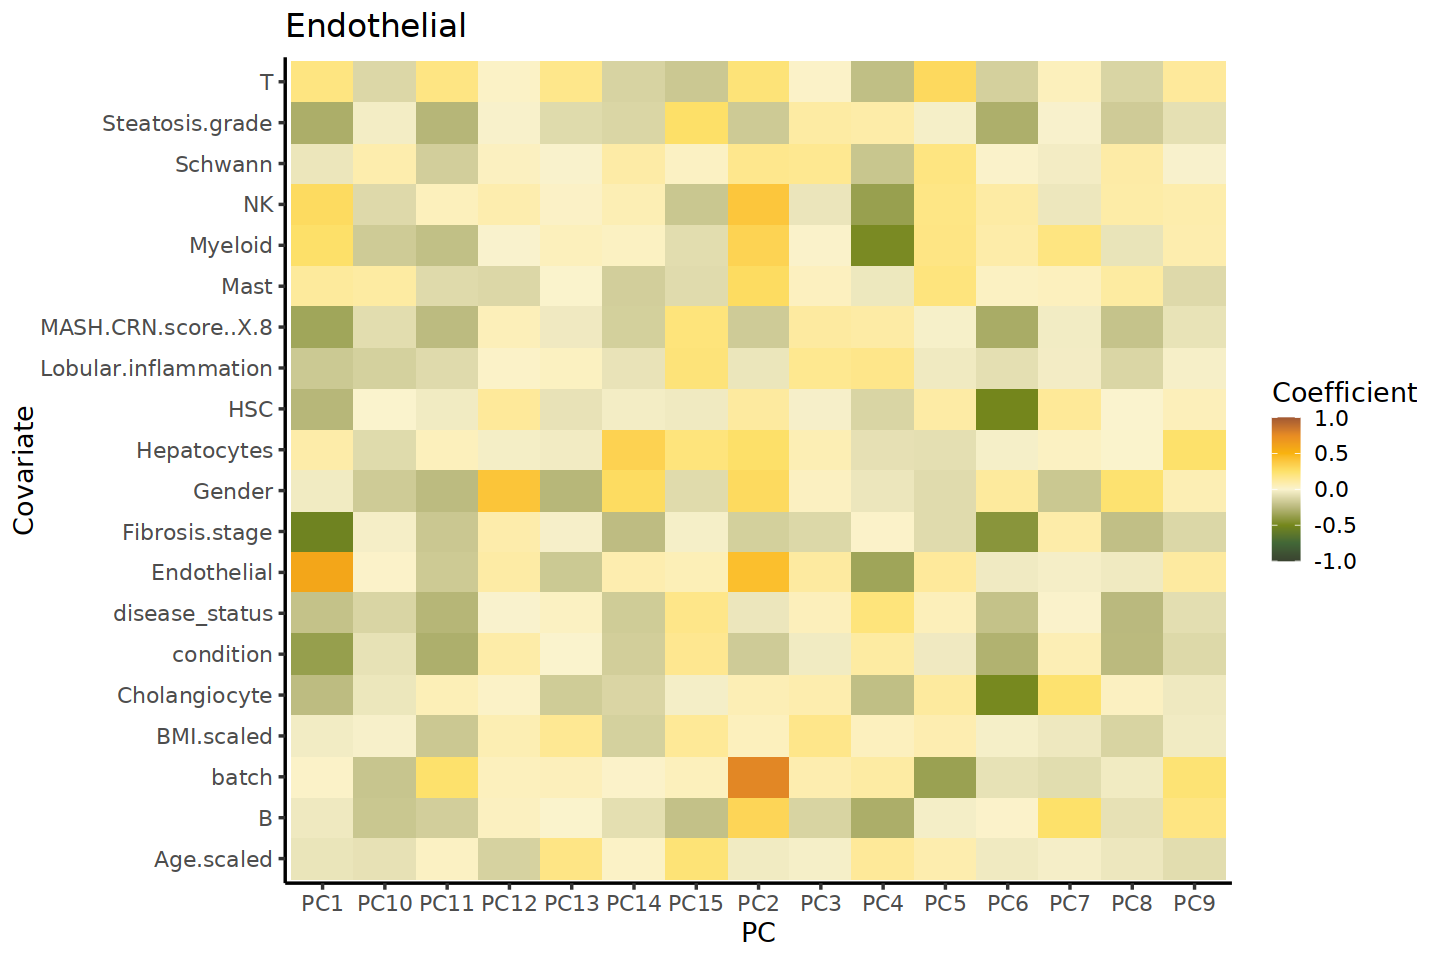

[1] "15 PCs cover 60.012% of variance for T"
[1] "HL170048 is an outlier on PC1 for T" "HL210621 is an outlier on PC1 for T"
[1] "HL170047 is an outlier on PC5 for T"
[1] "HL220825 is an outlier on PC6 for T"
[1] "HL221019 is an outlier on PC8 for T" "HL190214 is an outlier on PC8 for T"
[3] "HL160026 is an outlier on PC8 for T"
[1] "HL190214 is an outlier on PC9 for T" "HL160041 is an outlier on PC9 for T"
[1] "HL221019 is an outlier on PC10 for T"
[2] "HL160026 is an outlier on PC10 for T"
[1] "HL221019 is an outlier on PC11 for T"
[2] "HL190214 is an outlier on PC11 for T"
[3] "HL160041 is an outlier on PC11 for T"
[4] "HL211001 is an outlier on PC11 for T"
[1] "HL160042 is an outlier on PC12 for T"
[2] "HL200707 is an outlier on PC12 for T"
[1] "HL160042 is an outlier on PC13 for T"
[2] "HL170060 is an outlier on PC13 for T"
[3] "HL211001 is an outlier on PC13 for T"
[1] "HL170060 is an outlier on PC14 for T"
[2] "HL200707 is an outlier on PC14 for T"
[3] "HL211001 is an outlier on

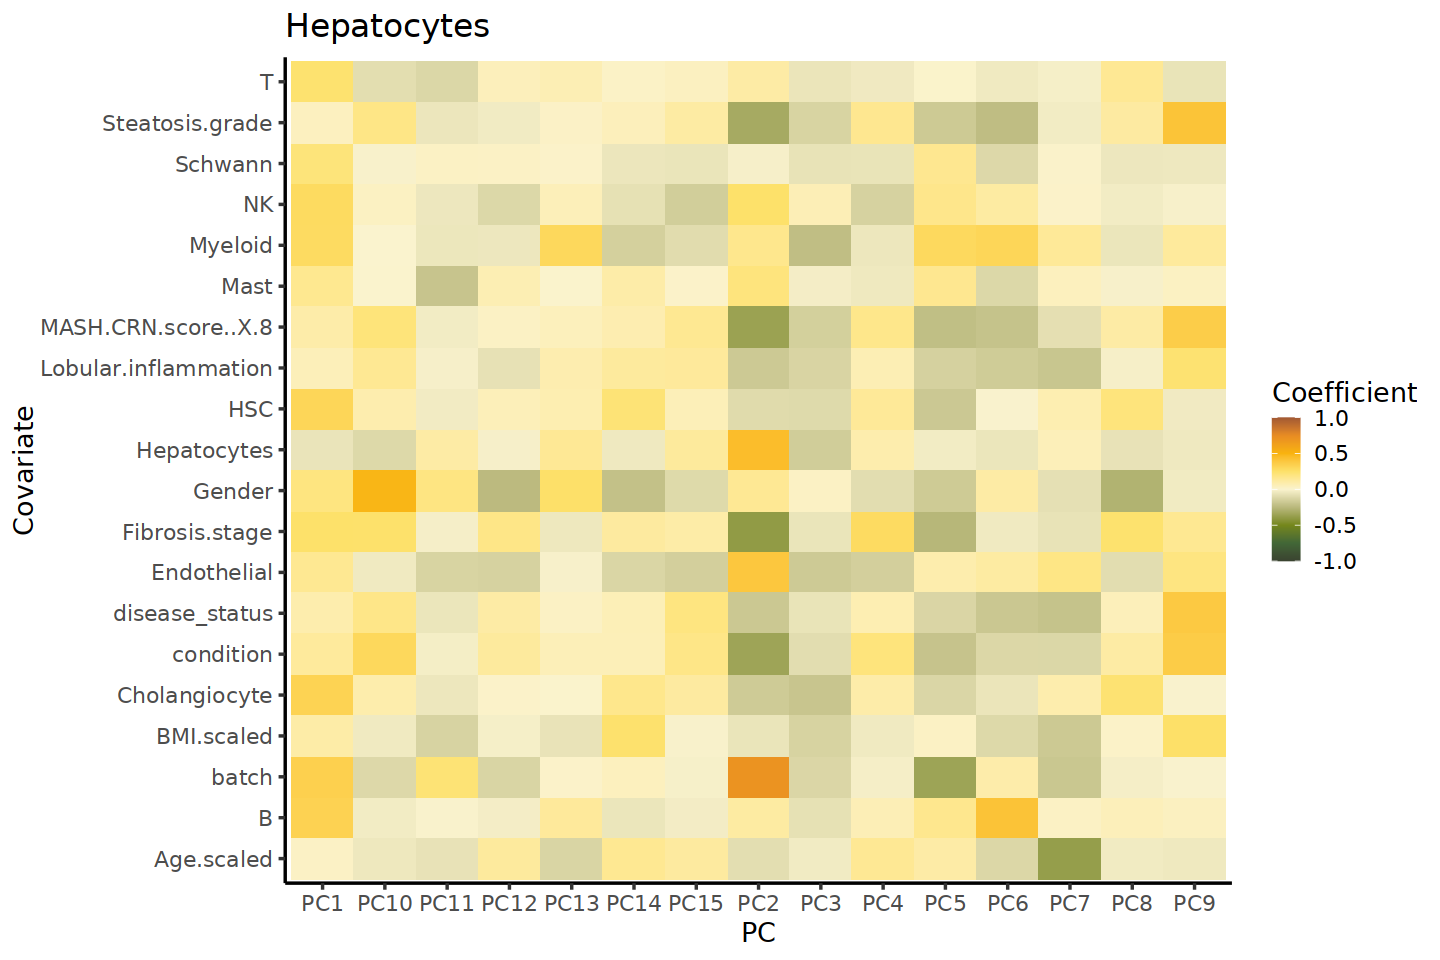

[1] "15 PCs cover 62.384% of variance for HSC"
[1] "HL190326 is an outlier on PC1 for HSC"
[1] "HL210806 is an outlier on PC6 for HSC"
[1] "HL230316 is an outlier on PC9 for HSC"
[1] "HL211025 is an outlier on PC11 for HSC"
[1] "HL170047 is an outlier on PC13 for HSC"
[1] "HL200212 is an outlier on PC14 for HSC"
[1] "HL230316 is an outlier on PC15 for HSC"


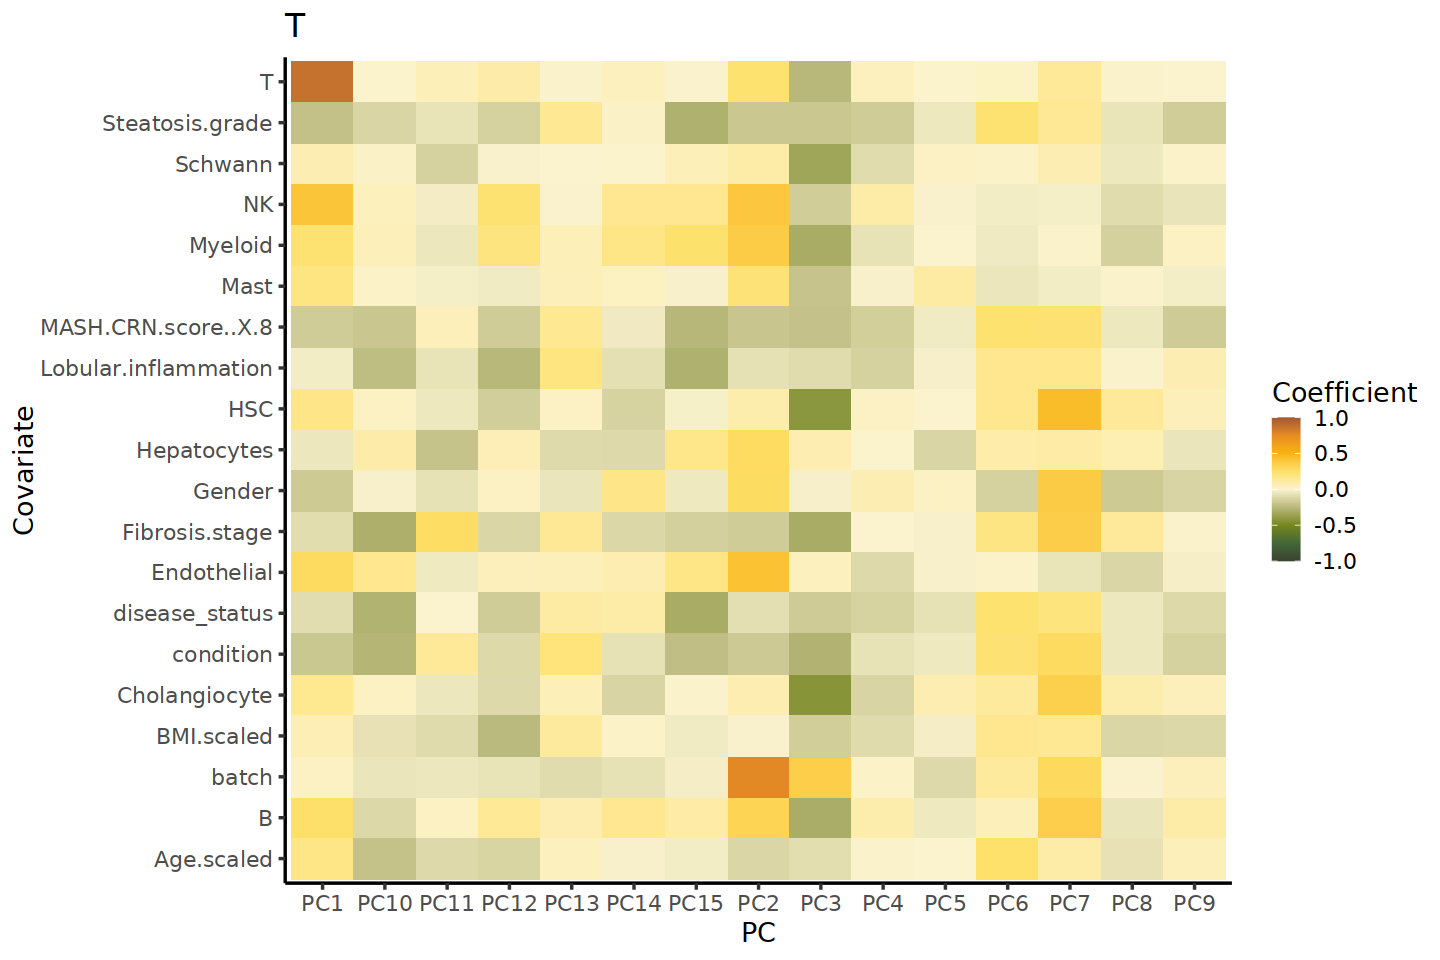

[1] "15 PCs cover 60.067% of variance for Cholangiocyte"
[1] "HL210726 is an outlier on PC2 for Cholangiocyte"
[1] "HL210806 is an outlier on PC3 for Cholangiocyte"
[1] "HL160032 is an outlier on PC5 for Cholangiocyte"
[1] "HL220825 is an outlier on PC7 for Cholangiocyte"
[2] "HL230302 is an outlier on PC7 for Cholangiocyte"
[1] "HL170060 is an outlier on PC8 for Cholangiocyte"
[2] "HL220825 is an outlier on PC8 for Cholangiocyte"
[1] "HL230302 is an outlier on PC9 for Cholangiocyte"
[2] "HL220613 is an outlier on PC9 for Cholangiocyte"
[3] "HL150009 is an outlier on PC9 for Cholangiocyte"
[1] "HL160042 is an outlier on PC10 for Cholangiocyte"
[2] "HL221201 is an outlier on PC10 for Cholangiocyte"
[3] "HL210621 is an outlier on PC10 for Cholangiocyte"
[4] "HL220613 is an outlier on PC10 for Cholangiocyte"
[1] "HL230302 is an outlier on PC11 for Cholangiocyte"
[2] "HL210621 is an outlier on PC11 for Cholangiocyte"
[3] "HL150009 is an outlier on PC11 for Cholangiocyte"
[1] "HL230302 is a

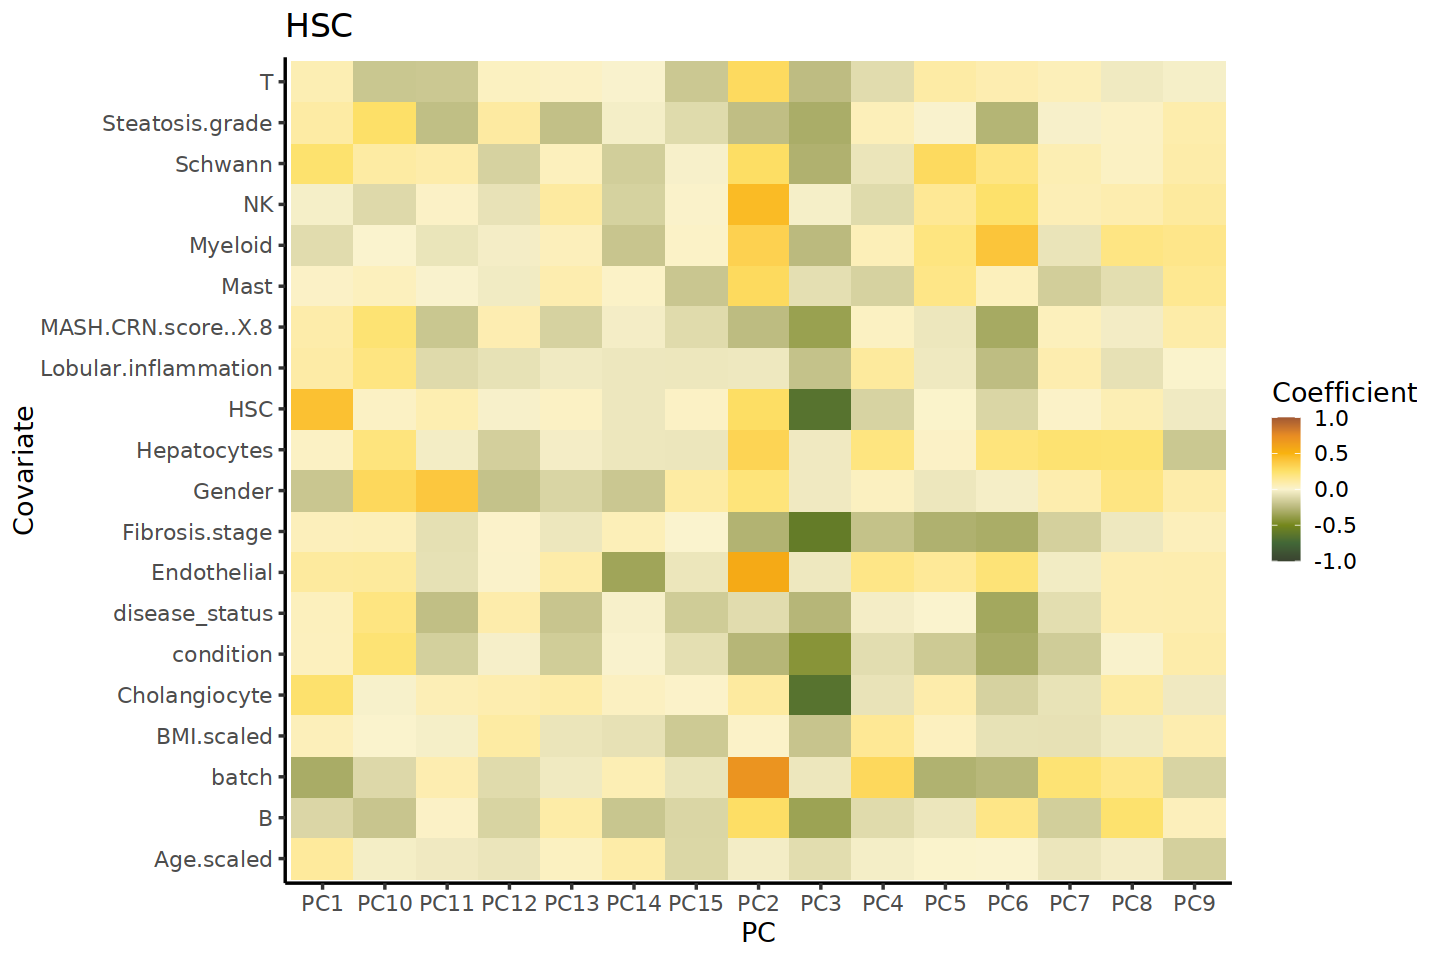

[1] "15 PCs cover 68.172% of variance for Myeloid"
[1] "HL221119 is an outlier on PC1 for Myeloid"
[1] "HL221119 is an outlier on PC6 for Myeloid"
[1] "HL211106 is an outlier on PC9 for Myeloid"
[1] "HL170060 is an outlier on PC10 for Myeloid"
[1] "HL170060 is an outlier on PC11 for Myeloid"
[2] "HL220825 is an outlier on PC11 for Myeloid"
[1] "HL220825 is an outlier on PC12 for Myeloid"
[2] "HL160026 is an outlier on PC12 for Myeloid"
[1] "HL211106 is an outlier on PC13 for Myeloid"
[1] "HL170060 is an outlier on PC14 for Myeloid"
[2] "HL191025 is an outlier on PC14 for Myeloid"
[1] "HL191025 is an outlier on PC15 for Myeloid"
[2] "HL160026 is an outlier on PC15 for Myeloid"


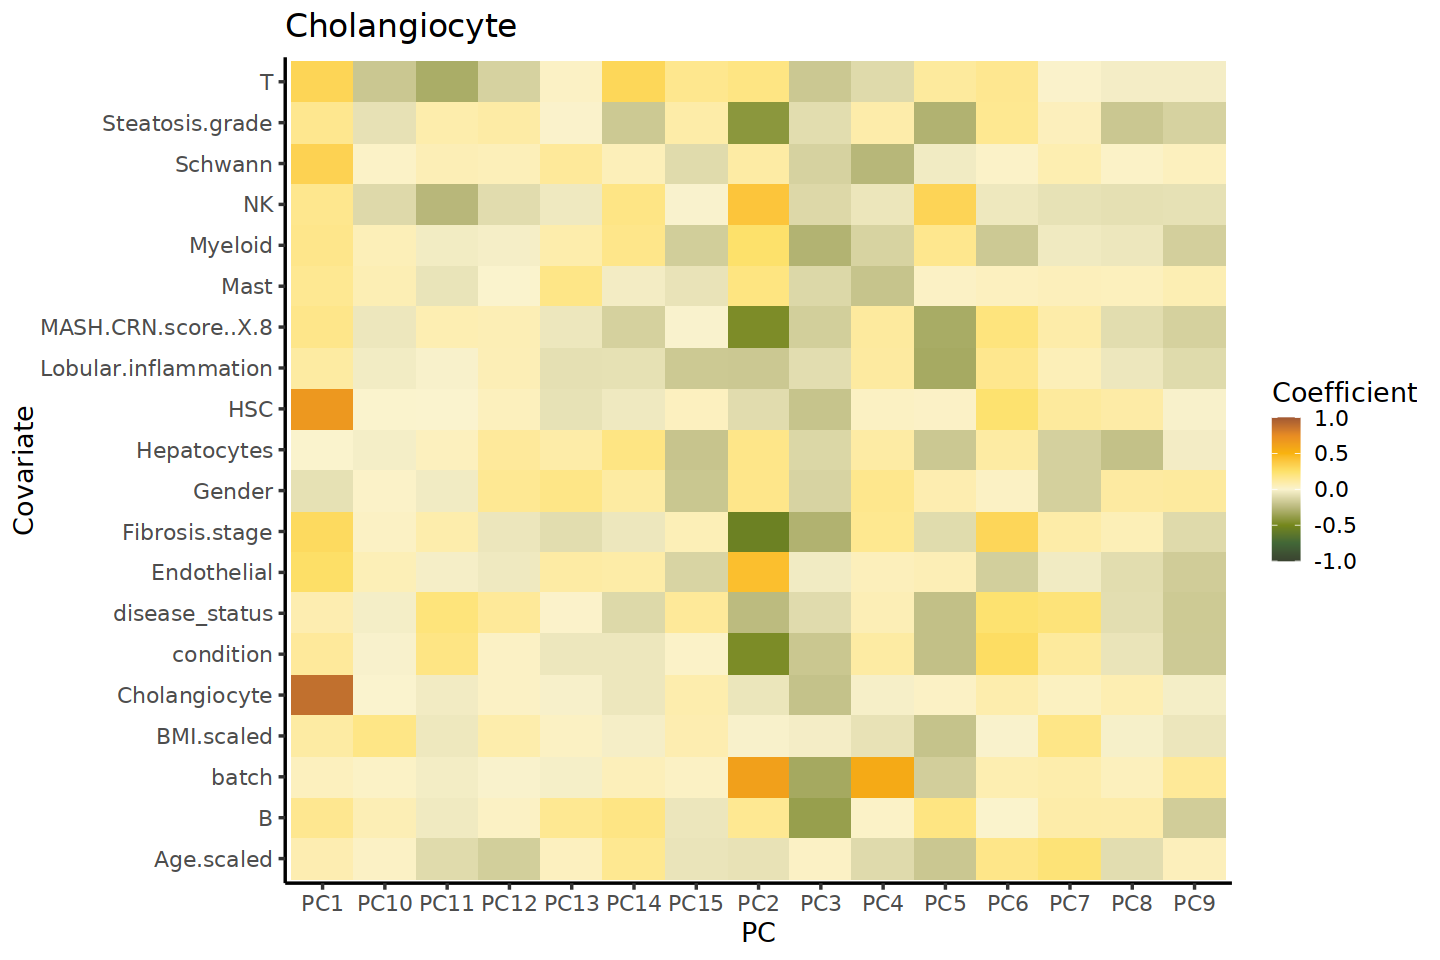

[1] "15 PCs cover 54.035% of variance for NK"
[1] "HL220825 is an outlier on PC4 for NK"
[1] "HL170060 is an outlier on PC6 for NK"
[1] "HL220613 is an outlier on PC7 for NK"
[1] "HL160042 is an outlier on PC8 for NK"
[1] "HL150009 is an outlier on PC9 for NK"
[1] "HL191025 is an outlier on PC10 for NK"
[2] "HL200707 is an outlier on PC10 for NK"
[1] "HL170049 is an outlier on PC11 for NK"
[2] "HL150009 is an outlier on PC11 for NK"
[1] "HL200707 is an outlier on PC12 for NK"
[2] "HL170049 is an outlier on PC12 for NK"
[1] "HL221019 is an outlier on PC13 for NK"
[1] "HL160026 is an outlier on PC14 for NK"
[1] "HL191025 is an outlier on PC15 for NK"
[2] "HL221019 is an outlier on PC15 for NK"
[3] "HL160026 is an outlier on PC15 for NK"


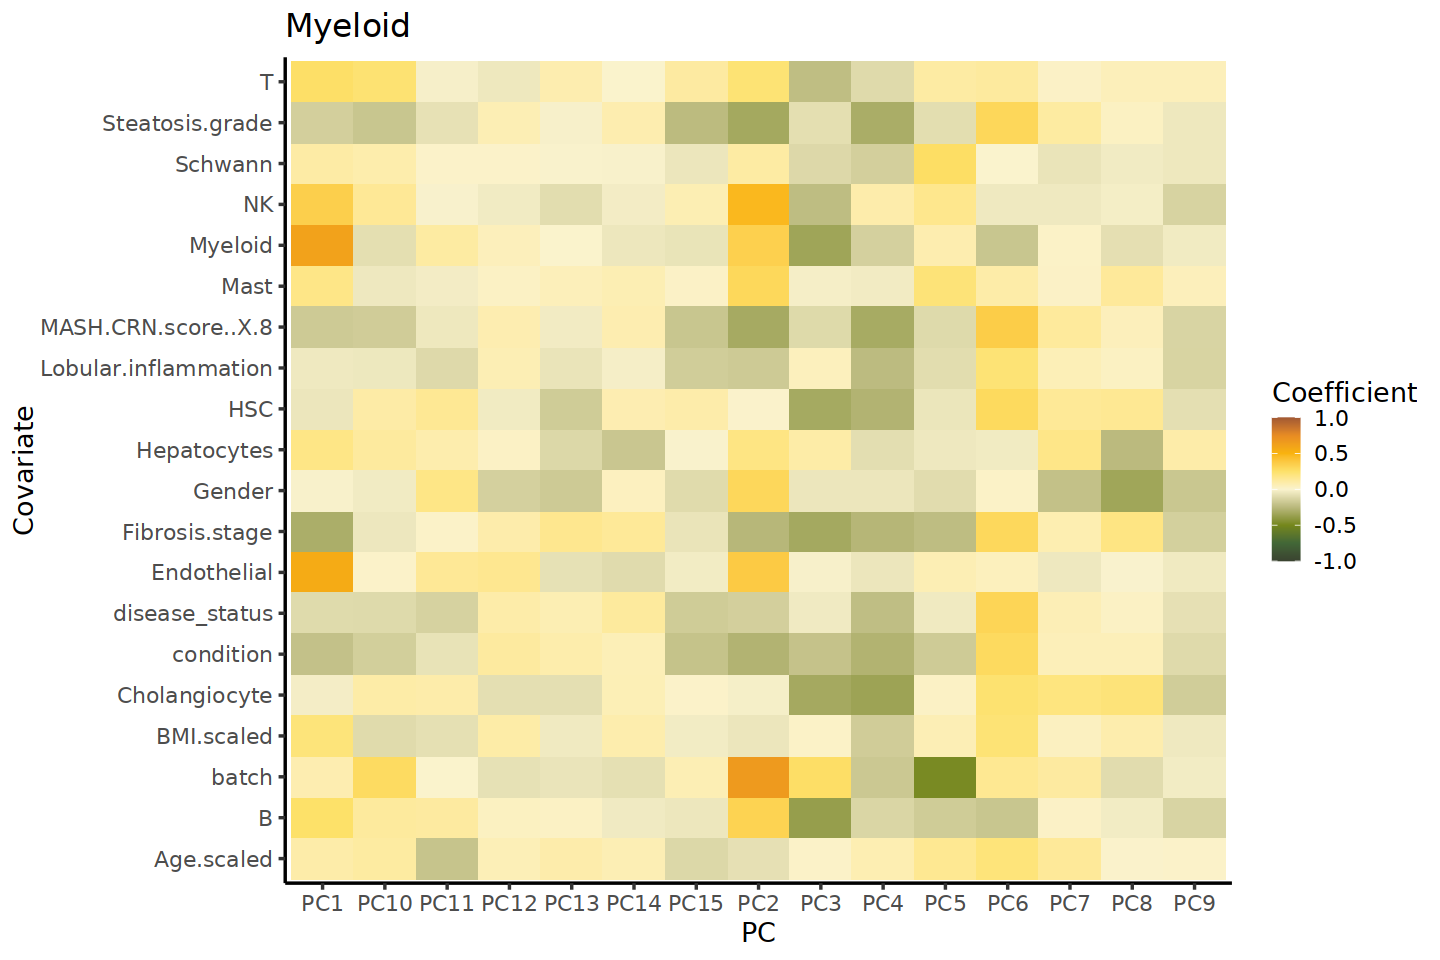

[1] "15 PCs cover 53.888% of variance for B"
[1] "HL221119 is an outlier on PC1 for B"
[1] "HL190326 is an outlier on PC3 for B" "HL160029 is an outlier on PC3 for B"
[1] "HL211106 is an outlier on PC4 for B"
[1] "HL190326 is an outlier on PC5 for B" "HL160029 is an outlier on PC5 for B"
[3] "HL160041 is an outlier on PC5 for B"
[1] "HL190326 is an outlier on PC6 for B" "HL160029 is an outlier on PC6 for B"
[3] "HL160041 is an outlier on PC6 for B"
[1] "HL190326 is an outlier on PC7 for B" "HL170047 is an outlier on PC7 for B"
[1] "HL191025 is an outlier on PC8 for B" "HL170047 is an outlier on PC8 for B"
[1] "HL160042 is an outlier on PC9 for B" "HL170047 is an outlier on PC9 for B"
[1] "HL191025 is an outlier on PC10 for B"
[2] "HL170047 is an outlier on PC10 for B"
[3] "HL150009 is an outlier on PC10 for B"
[1] "HL200707 is an outlier on PC11 for B"
[2] "HL200115 is an outlier on PC11 for B"
[3] "HL200212 is an outlier on PC11 for B"
[1] "HL191025 is an outlier on PC12 for B"
[2] "H

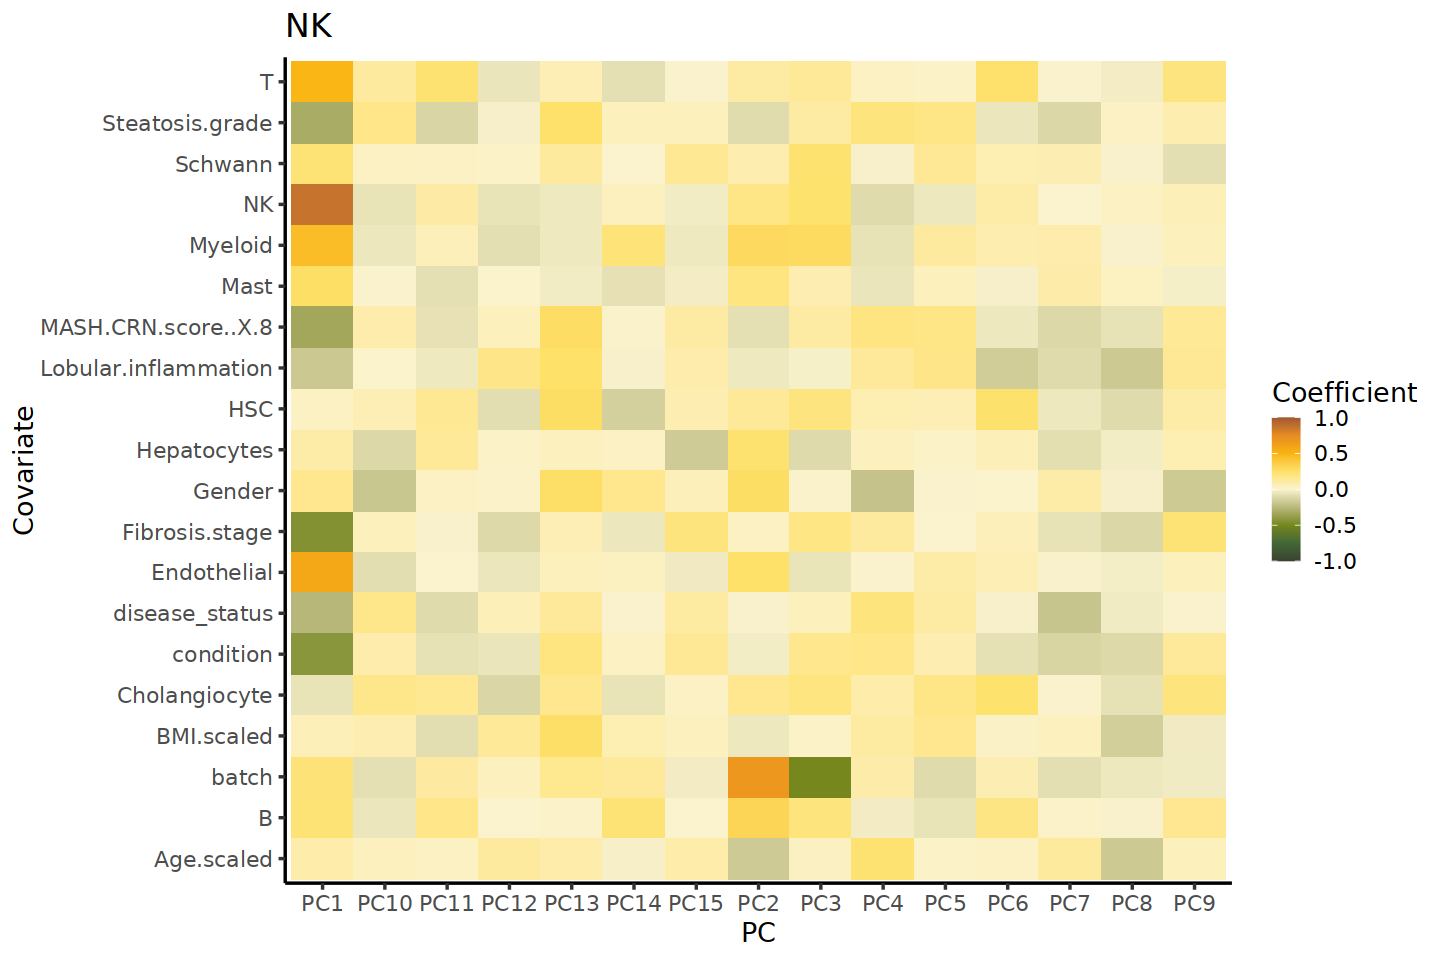

[1] "15 PCs cover 91.564% of variance for Bulk"
[1] "HL220825 is an outlier on PC1 for Bulk"
[1] "HL230302 is an outlier on PC2 for Bulk"
[1] "HL220825 is an outlier on PC6 for Bulk"
[1] "HL190214 is an outlier on PC8 for Bulk"
[2] "HL210706 is an outlier on PC8 for Bulk"
[1] "HL200707 is an outlier on PC9 for Bulk"
[1] "HL220825 is an outlier on PC11 for Bulk"
[2] "HL191025 is an outlier on PC11 for Bulk"
[1] "HL191025 is an outlier on PC12 for Bulk"
[1] "HL200707 is an outlier on PC13 for Bulk"
[2] "HL190214 is an outlier on PC13 for Bulk"
[1] "HL230316 is an outlier on PC14 for Bulk"
[1] "HL160029 is an outlier on PC15 for Bulk"


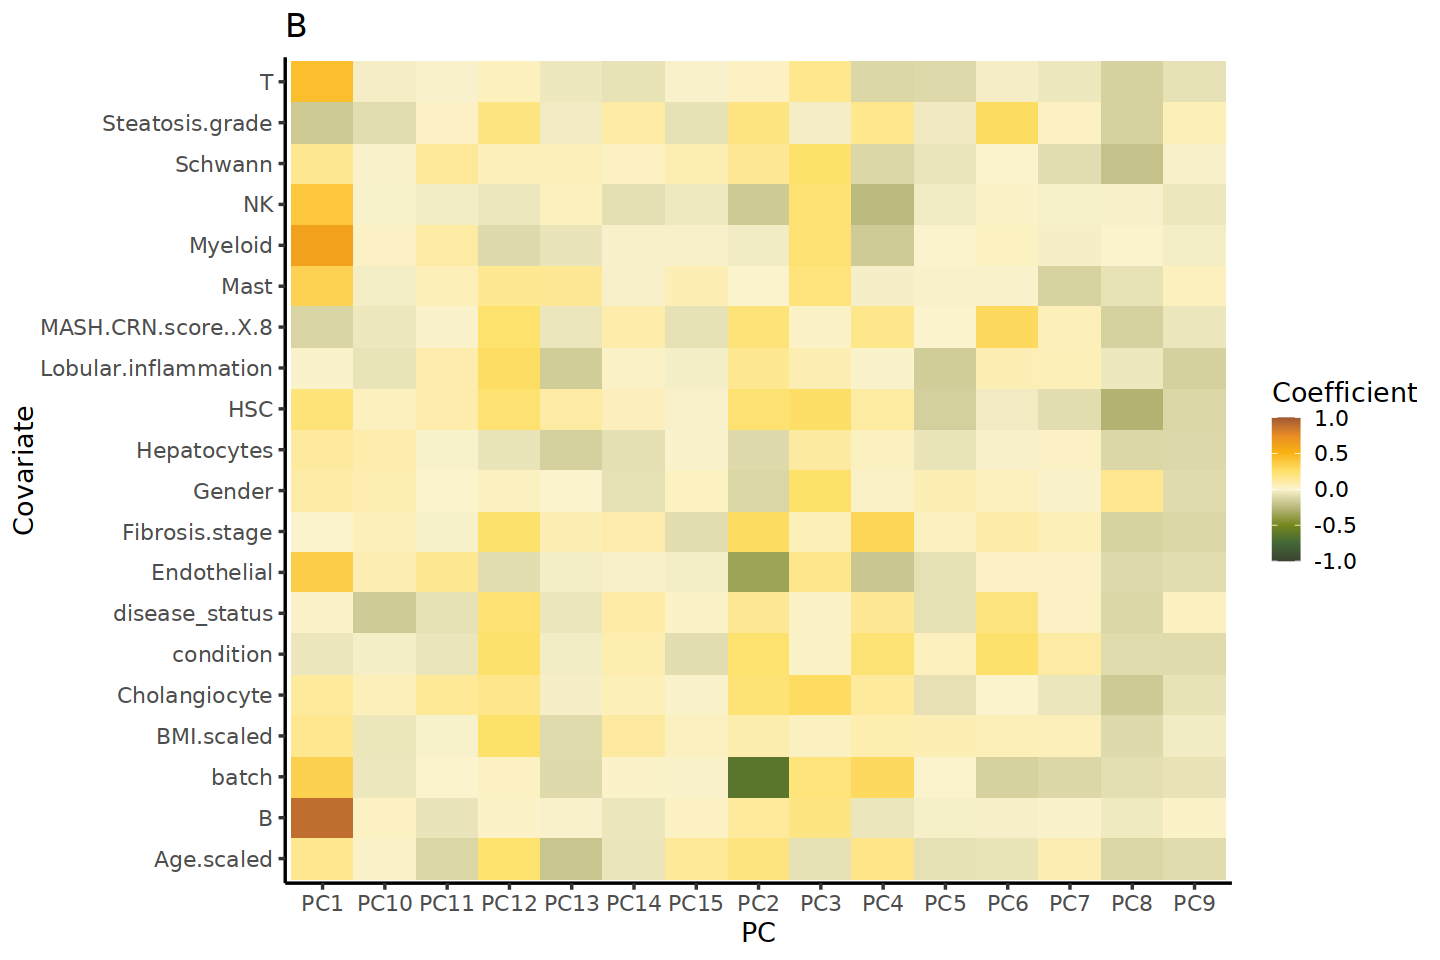

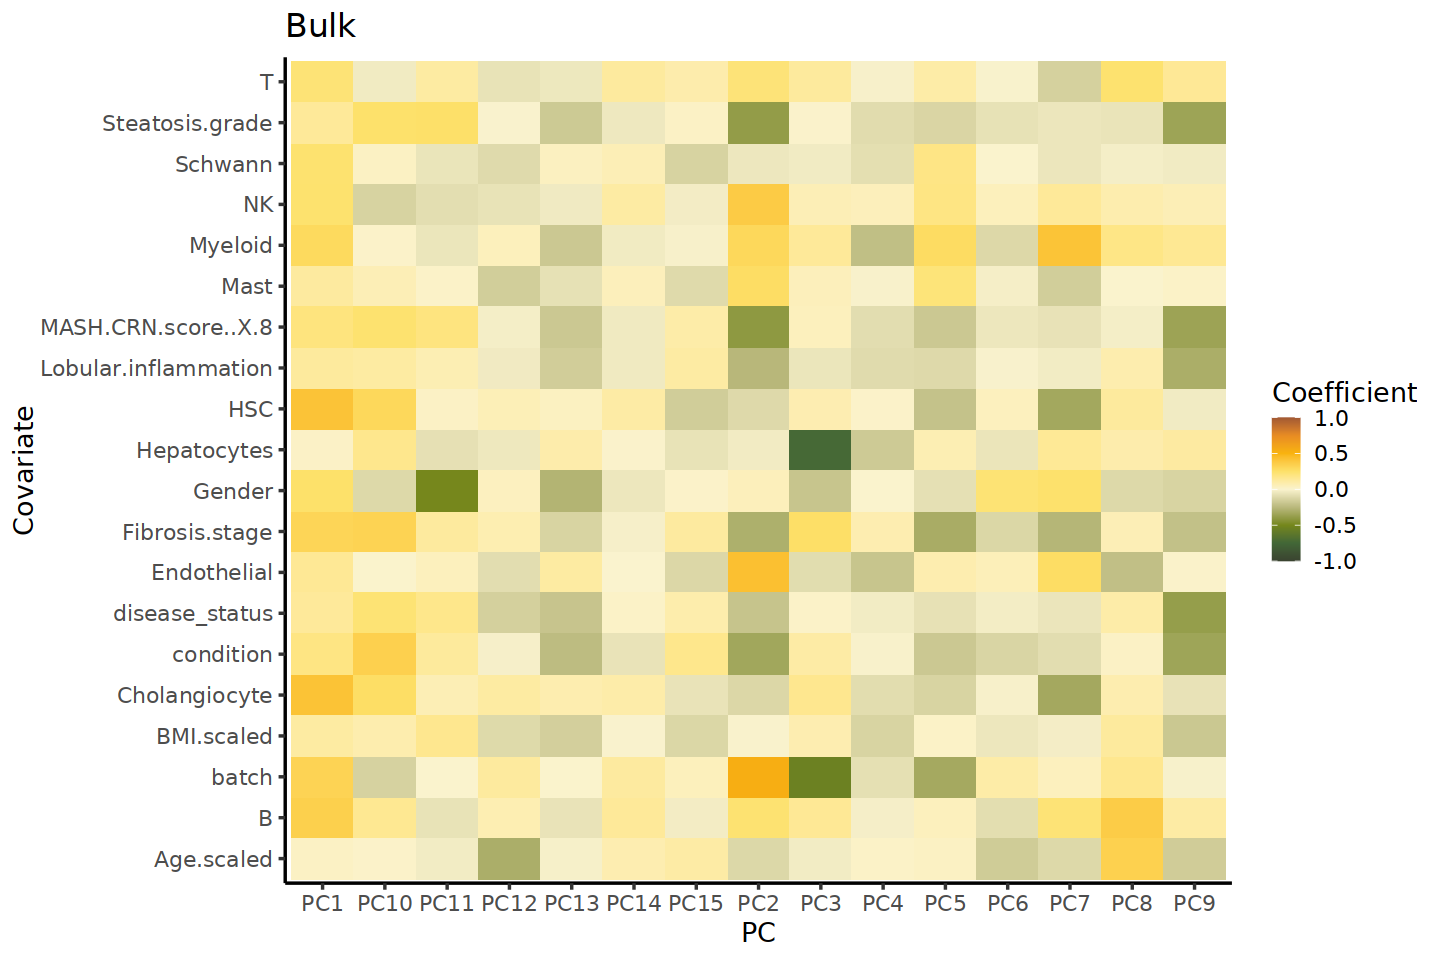

In [9]:
indir <- '/nfs/lab/projects/nash_nafld_liver/downstream_all/count.matrices/ATAC/'
outdir <- '/nfs/lab/projects/nash_nafld_liver/downstream_all/05_caQTLs/covariates/'

n_pc <- 15

##### NAME YOUR FILES #####
for (cell.type in unique_cell_types){
    if (cell.type %in% c('Mast','Schwann')) {
        next
    }
    tmm.filename <- paste(indir, cell.type, '_perdonor.ATAC.TMM.tsv', sep = "")
    #int.filename <- paste(indir, cell.type, '_perdonor.ATAC.INT.tsv', sep = "")
    pc.filename <- paste(outdir, cell.type, '_perdonor.ATAC.TMM.', n_pc,'.PCs.tsv', sep = "")
    cor.filename <- paste(outdir, cell.type, '_perdonor.ATAC.TMM.', n_pc,'.PCs.correlation.tsv', sep = "")
    make_PC_covariate_mat(cell.type, expr.mat.filename=tmm.filename, pc.filename,
                          cor.filename, n_pc=15, meta)
}

[1] "15 PCs cover 30.498% of variance for Endothelial"
[1] "HL220216 is an outlier on PC4 for Endothelial"
[1] "HL230325 is an outlier on PC6 for Endothelial"
[1] "HL160017 is an outlier on PC8 for Endothelial"
[1] "HL200805 is an outlier on PC9 for Endothelial"
[1] "HL200525 is an outlier on PC10 for Endothelial"
[2] "HL150001 is an outlier on PC10 for Endothelial"
[1] "HL150001 is an outlier on PC11 for Endothelial"
[2] "HL201024 is an outlier on PC11 for Endothelial"
[3] "HL160035 is an outlier on PC11 for Endothelial"
[1] "HL230325 is an outlier on PC12 for Endothelial"
[2] "HL160017 is an outlier on PC12 for Endothelial"
[3] "HL170055 is an outlier on PC12 for Endothelial"
[4] "HL190827 is an outlier on PC12 for Endothelial"
[1] "HL200525 is an outlier on PC13 for Endothelial"
[2] "HL150001 is an outlier on PC13 for Endothelial"
[3] "HL201024 is an outlier on PC13 for Endothelial"
[4] "HL170055 is an outlier on PC13 for Endothelial"
[1] "HL150001 is an outlier on PC14 for Endothel

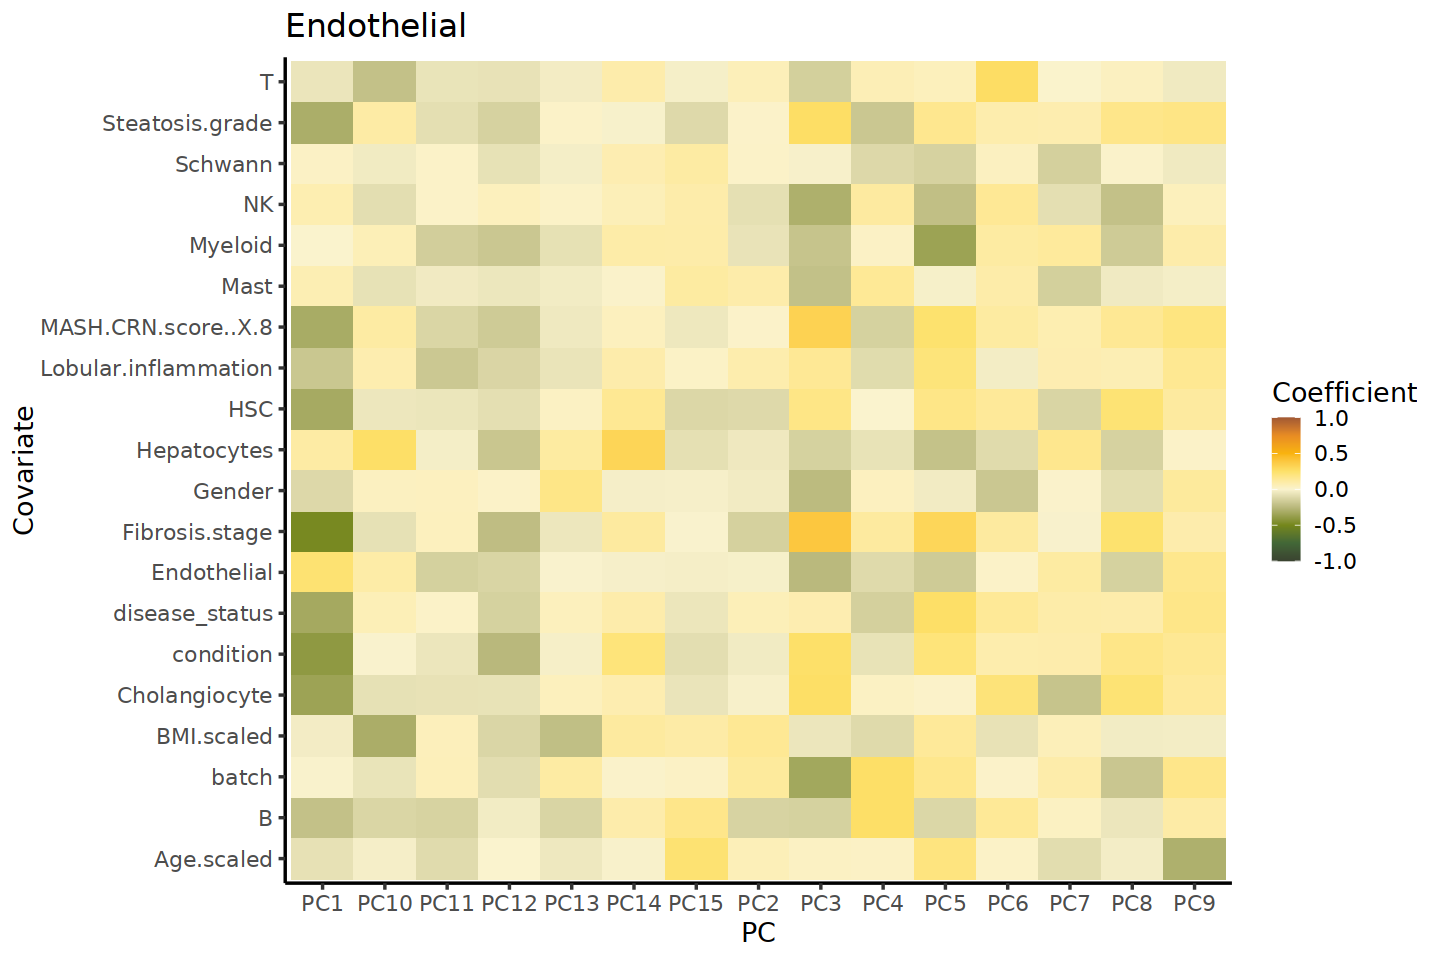

[1] "15 PCs cover 43.087% of variance for T"
[1] "HL190114 is an outlier on PC2 for T"
[1] "HL211001 is an outlier on PC3 for T" "HL190624 is an outlier on PC3 for T"
[1] "HL211025 is an outlier on PC4 for T" "HL170048 is an outlier on PC4 for T"
[1] "HL170064 is an outlier on PC5 for T" "HL190624 is an outlier on PC5 for T"
[1] "HL191216 is an outlier on PC6 for T" "HL200615 is an outlier on PC6 for T"
[1] "HL211001 is an outlier on PC7 for T" "HL170048 is an outlier on PC7 for T"
[3] "HL190624 is an outlier on PC7 for T"
[1] "HL191216 is an outlier on PC8 for T" "HL211001 is an outlier on PC8 for T"
[1] "HL221215 is an outlier on PC9 for T" "HL211025 is an outlier on PC9 for T"
[3] "HL200615 is an outlier on PC9 for T"
[1] "HL160040 is an outlier on PC10 for T"
[1] "HL200529 is an outlier on PC11 for T"
[2] "HL190114 is an outlier on PC11 for T"
[1] "HL170046 is an outlier on PC12 for T"
[2] "HL200615 is an outlier on PC12 for T"
[3] "HL180071 is an outlier on PC12 for T"
[4] "HL2202

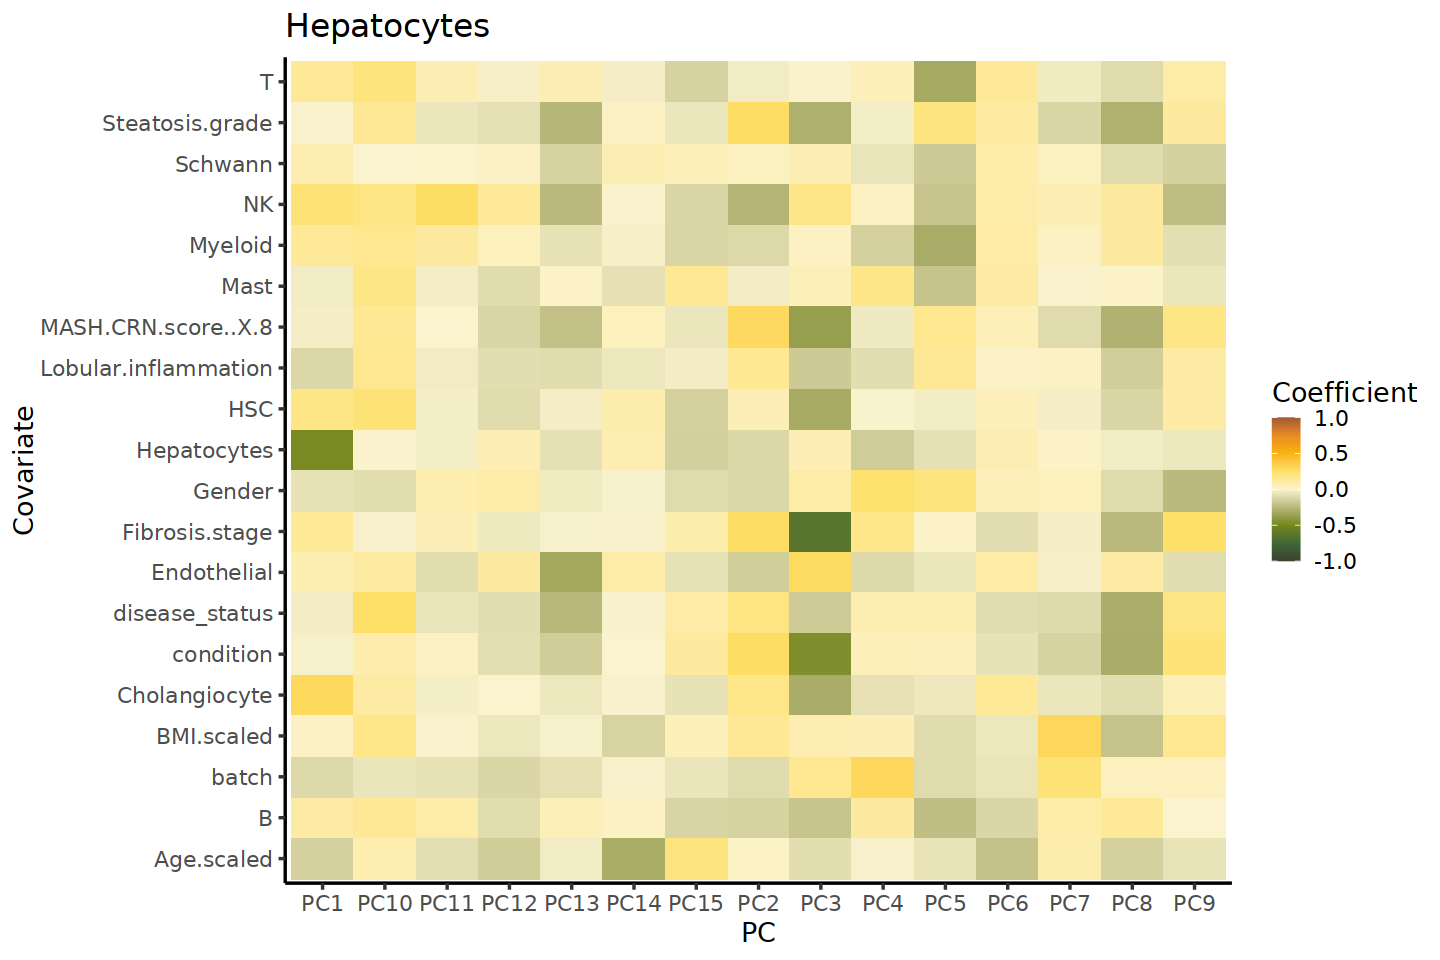

[1] "15 PCs cover 34.675% of variance for HSC"
[1] "HL160026 is an outlier on PC5 for HSC"
[2] "HL170044 is an outlier on PC5 for HSC"
[1] "HL160030 is an outlier on PC6 for HSC"
[2] "HL220210 is an outlier on PC6 for HSC"
[1] "HL160030 is an outlier on PC7 for HSC"
[2] "HL220825 is an outlier on PC7 for HSC"
[3] "HL220210 is an outlier on PC7 for HSC"
[1] "HL160030 is an outlier on PC8 for HSC"
[1] "HL220825 is an outlier on PC9 for HSC"
[2] "HL220210 is an outlier on PC9 for HSC"
[1] "HL220825 is an outlier on PC10 for HSC"
[2] "HL190909 is an outlier on PC10 for HSC"
[1] "HL200805 is an outlier on PC11 for HSC"
[2] "HL160017 is an outlier on PC11 for HSC"
[3] "HL211025 is an outlier on PC11 for HSC"
[4] "HL190624 is an outlier on PC11 for HSC"
[1] "HL200805 is an outlier on PC12 for HSC"
[2] "HL190624 is an outlier on PC12 for HSC"
[1] "HL200529 is an outlier on PC13 for HSC"
[1] "HL190909 is an outlier on PC14 for HSC"
[2] "HL190624 is an outlier on PC14 for HSC"
[1] "HL160041 is a

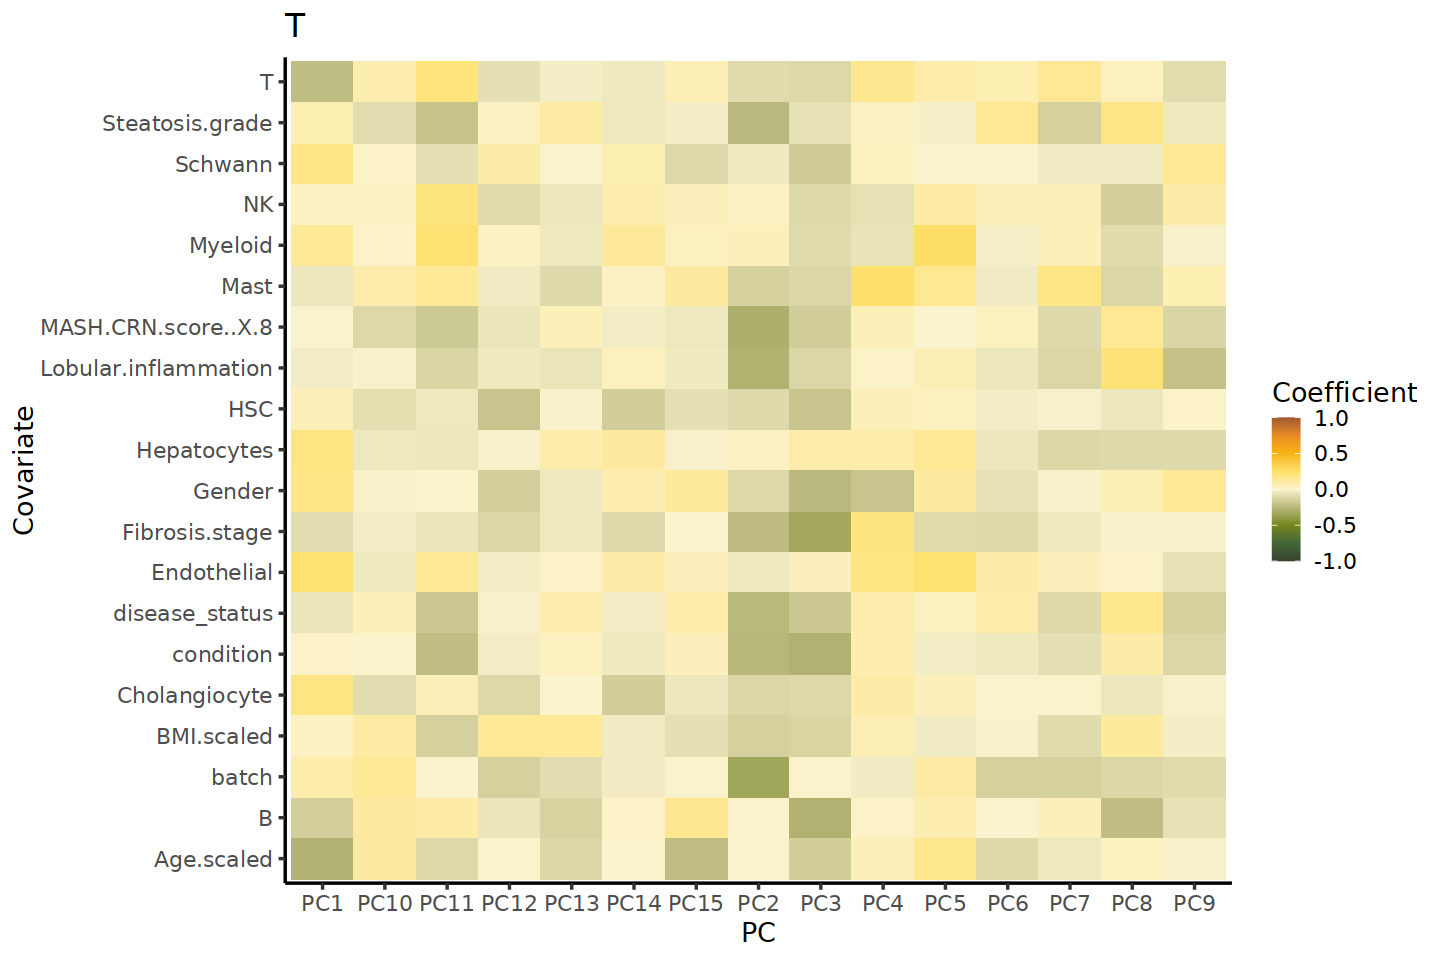

[1] "15 PCs cover 34.964% of variance for Cholangiocyte"
[1] "HL201120 is an outlier on PC4 for Cholangiocyte"
[1] "HL230324 is an outlier on PC5 for Cholangiocyte"
[2] "HL150013 is an outlier on PC5 for Cholangiocyte"
[1] "HL220613 is an outlier on PC6 for Cholangiocyte"
[2] "HL150013 is an outlier on PC6 for Cholangiocyte"
[3] "HL220210 is an outlier on PC6 for Cholangiocyte"
[1] "HL170052 is an outlier on PC7 for Cholangiocyte"
[2] "HL150013 is an outlier on PC7 for Cholangiocyte"
[1] "HL230324 is an outlier on PC8 for Cholangiocyte"
[2] "HL181031 is an outlier on PC8 for Cholangiocyte"
[1] "HL200529 is an outlier on PC9 for Cholangiocyte"
[2] "HL201120 is an outlier on PC9 for Cholangiocyte"
[3] "HL220628 is an outlier on PC9 for Cholangiocyte"
[1] "HL150013 is an outlier on PC10 for Cholangiocyte"
[2] "HL201120 is an outlier on PC10 for Cholangiocyte"
[3] "HL180809 is an outlier on PC10 for Cholangiocyte"
[1] "HL170048 is an outlier on PC11 for Cholangiocyte"
[2] "HL220628 is an o

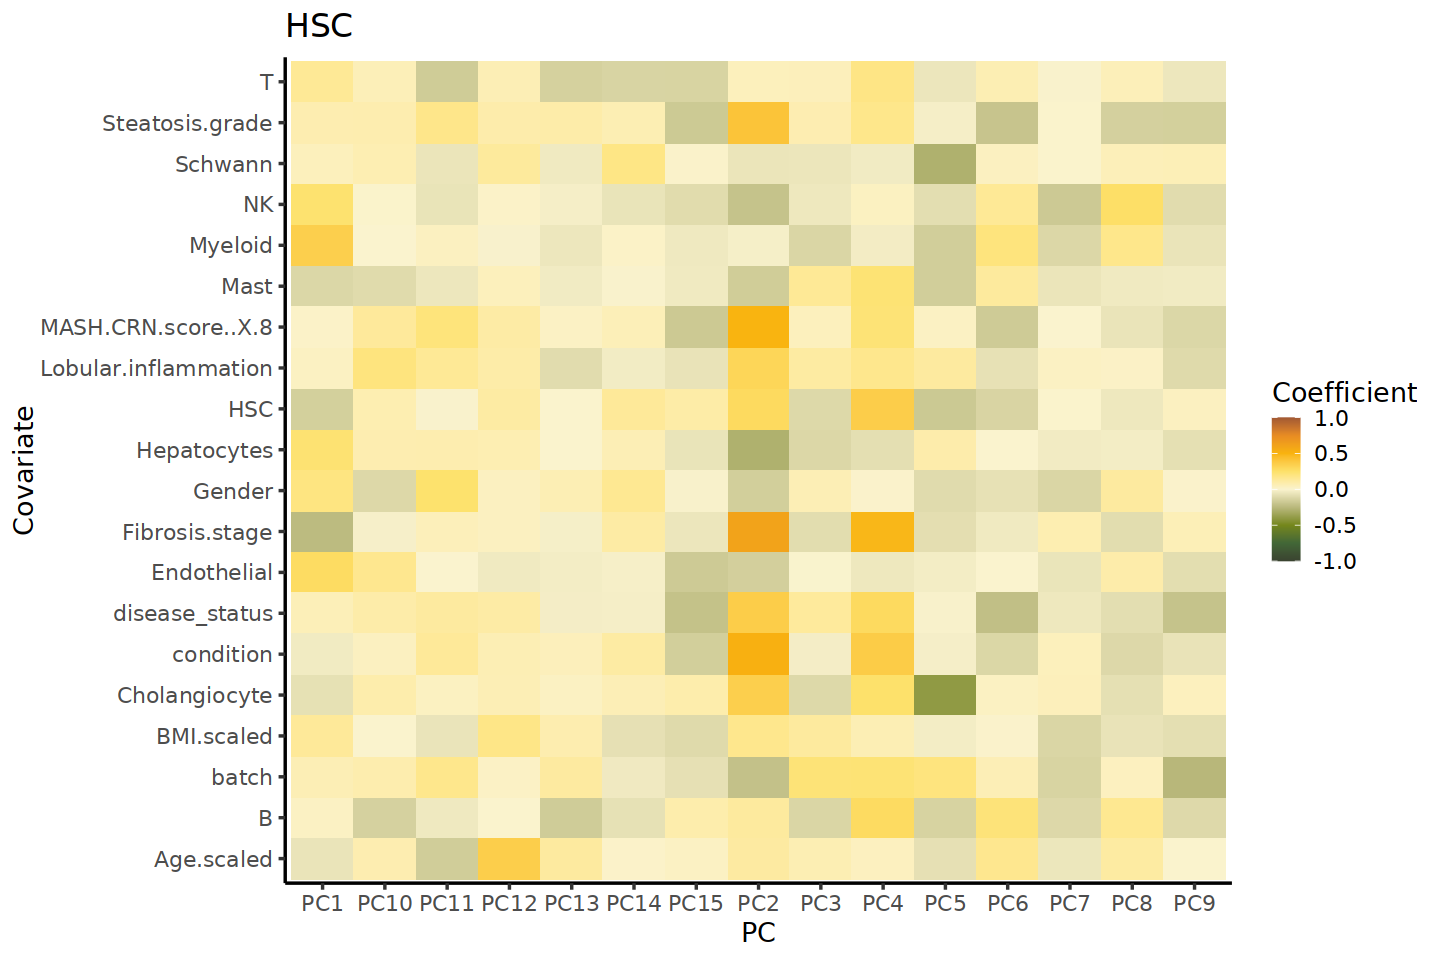

[1] "15 PCs cover 32.046% of variance for Myeloid"
[1] "HL220216 is an outlier on PC4 for Myeloid"
[1] "HL170055 is an outlier on PC5 for Myeloid"
[2] "HL150009 is an outlier on PC5 for Myeloid"
[1] "HL211106 is an outlier on PC6 for Myeloid"
[1] "HL150001 is an outlier on PC7 for Myeloid"
[1] "HL190603 is an outlier on PC8 for Myeloid"
[1] "HL150001 is an outlier on PC9 for Myeloid"
[2] "HL190603 is an outlier on PC9 for Myeloid"
[1] "HL220825 is an outlier on PC10 for Myeloid"
[2] "HL170055 is an outlier on PC10 for Myeloid"
[3] "HL150009 is an outlier on PC10 for Myeloid"
[1] "HL160032 is an outlier on PC11 for Myeloid"
[2] "HL170055 is an outlier on PC11 for Myeloid"
[1] "HL201024 is an outlier on PC12 for Myeloid"
[2] "HL170055 is an outlier on PC12 for Myeloid"
[1] "HL200707 is an outlier on PC13 for Myeloid"
[1] "HL200707 is an outlier on PC14 for Myeloid"
[2] "HL201024 is an outlier on PC14 for Myeloid"
[3] "HL181010 is an outlier on PC14 for Myeloid"
[1] "HL200615 is an outlie

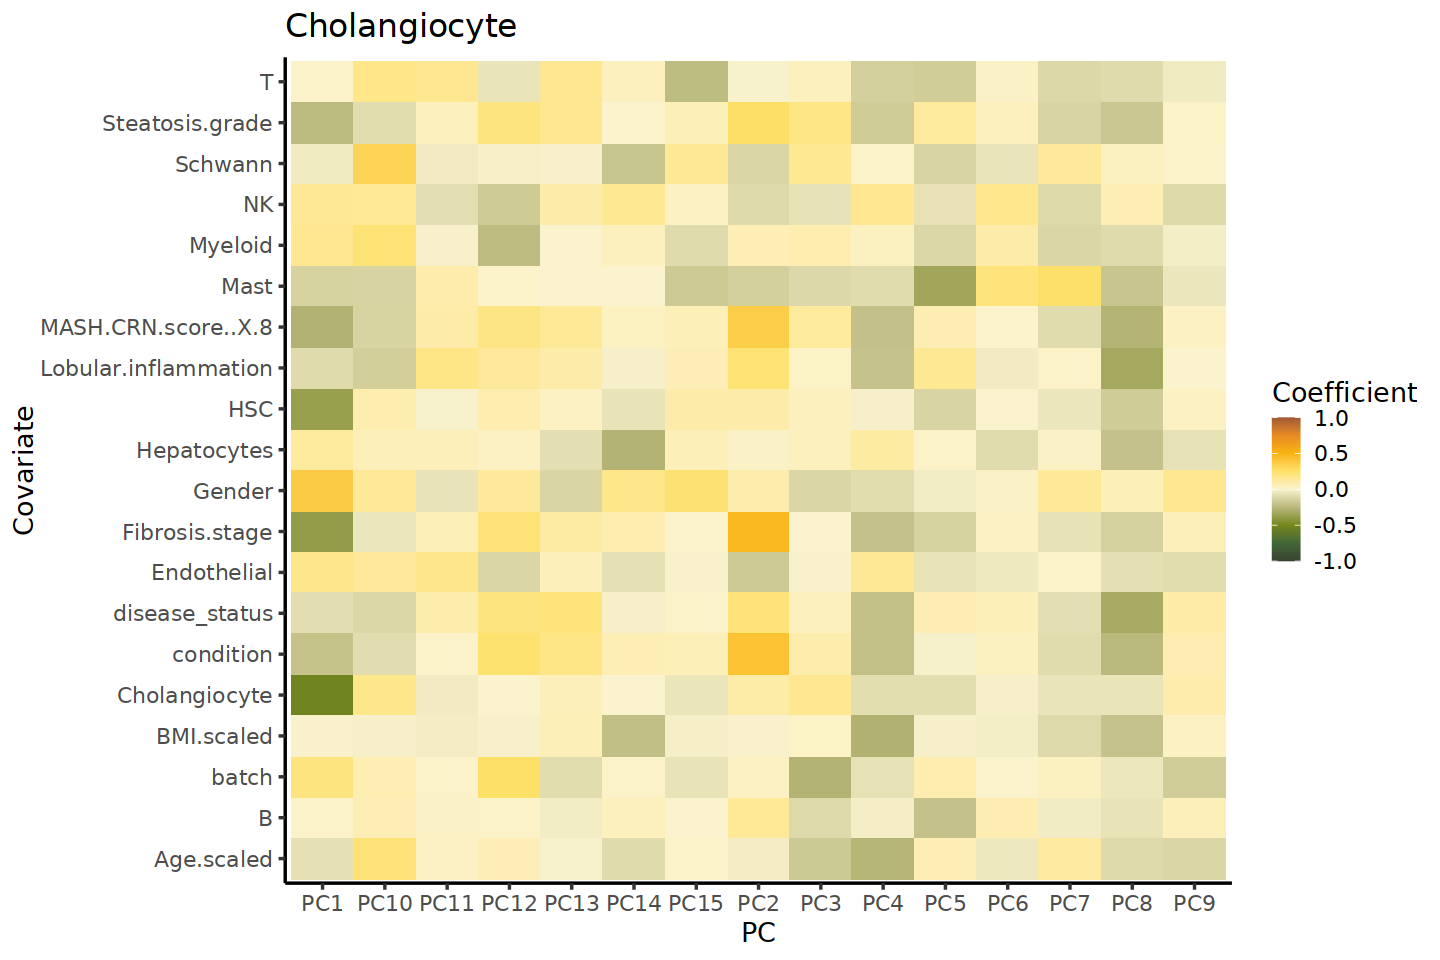

[1] "15 PCs cover 45.484% of variance for NK"
[1] "HL170060 is an outlier on PC2 for NK"
[2] "HL200529 is an outlier on PC2 for NK"
[3] "HL180071 is an outlier on PC2 for NK"
[1] "HL170047 is an outlier on PC3 for NK"
[2] "HL180071 is an outlier on PC3 for NK"
[1] "HL190326 is an outlier on PC4 for NK"
[2] "HL211025 is an outlier on PC4 for NK"
[1] "HL211106 is an outlier on PC5 for NK"
[1] "HL211106 is an outlier on PC6 for NK"
[1] "HL170047 is an outlier on PC7 for NK"
[2] "HL220210 is an outlier on PC7 for NK"
[1] "HL210120 is an outlier on PC8 for NK"
[2] "HL200529 is an outlier on PC8 for NK"
[1] "HL221019 is an outlier on PC9 for NK"
[2] "HL211106 is an outlier on PC9 for NK"
[1] "HL210120 is an outlier on PC10 for NK"
[2] "HL220210 is an outlier on PC10 for NK"
[1] "HL160042 is an outlier on PC11 for NK"
[2] "HL170060 is an outlier on PC11 for NK"
[3] "HL200115 is an outlier on PC11 for NK"
[1] "HL190326 is an outlier on PC12 for NK"
[2] "HL190909 is an outlier on PC12 for NK"
[

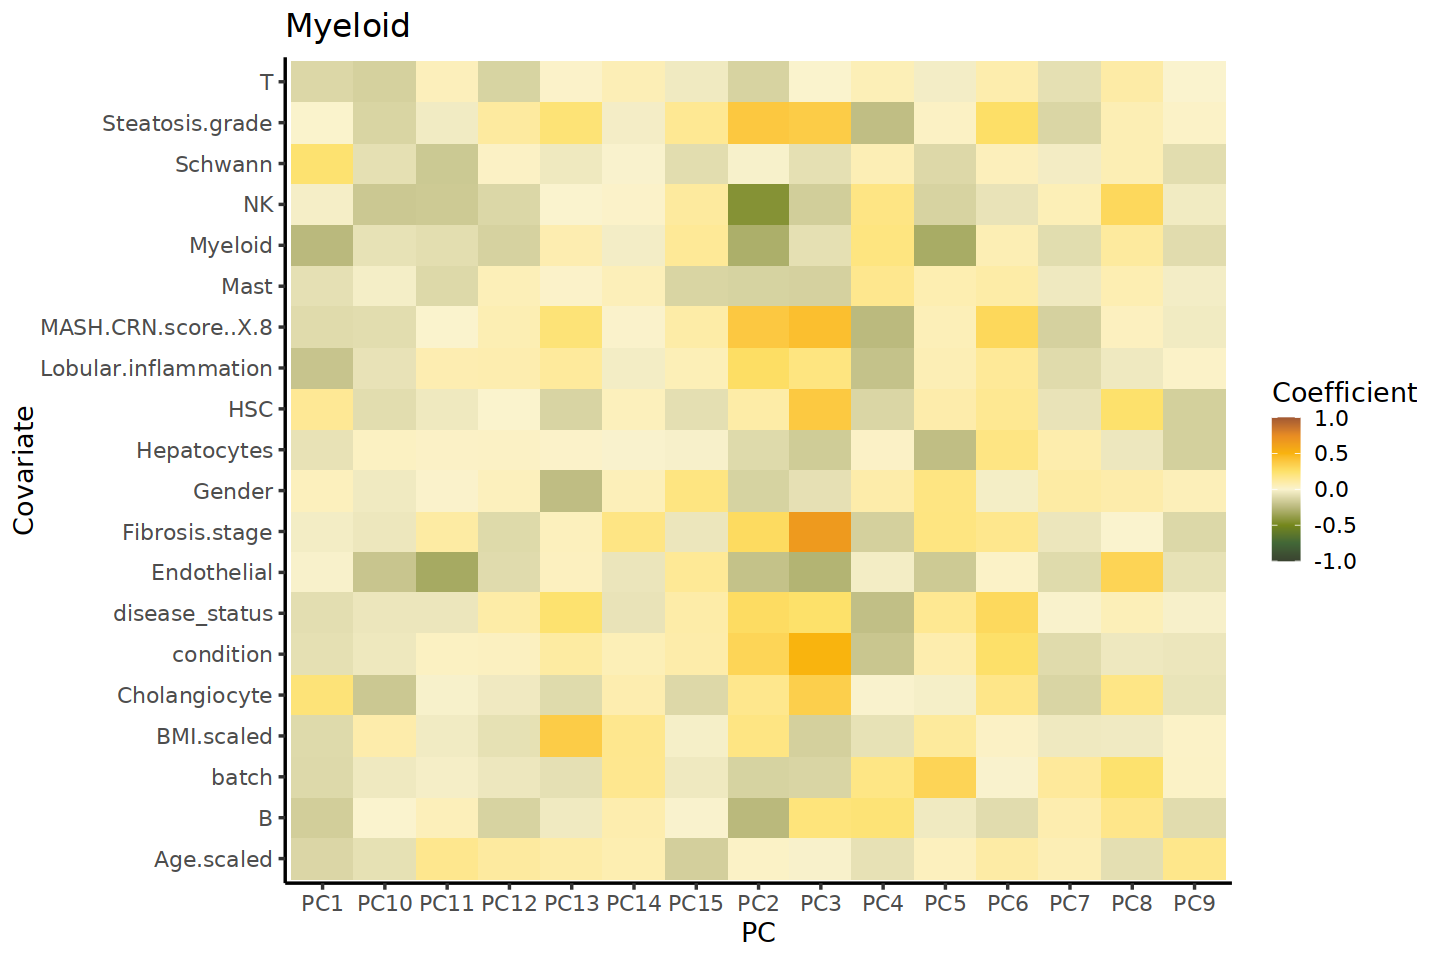

[1] "15 PCs cover 45.774% of variance for B"
[1] "HL170047 is an outlier on PC2 for B" "HL201120 is an outlier on PC2 for B"
[1] "HL200212 is an outlier on PC3 for B" "HL191002 is an outlier on PC3 for B"
[3] "HL180071 is an outlier on PC3 for B"
[1] "HL180071 is an outlier on PC4 for B" "HL220628 is an outlier on PC4 for B"
[1] "HL180071 is an outlier on PC5 for B" "HL220210 is an outlier on PC5 for B"
[1] "HL190214 is an outlier on PC6 for B" "HL220210 is an outlier on PC6 for B"
[1] "HL150013 is an outlier on PC7 for B" "HL220210 is an outlier on PC7 for B"
[3] "HL211122 is an outlier on PC7 for B"
[1] "HL190214 is an outlier on PC8 for B" "HL150013 is an outlier on PC8 for B"
[3] "HL170048 is an outlier on PC8 for B"
[1] "HL190215 is an outlier on PC9 for B"
[1] "HL191002 is an outlier on PC10 for B"
[1] "HL200925 is an outlier on PC11 for B"
[2] "HL190215 is an outlier on PC11 for B"
[1] "HL191025 is an outlier on PC12 for B"
[2] "HL220628 is an outlier on PC12 for B"
[1] "HL21070

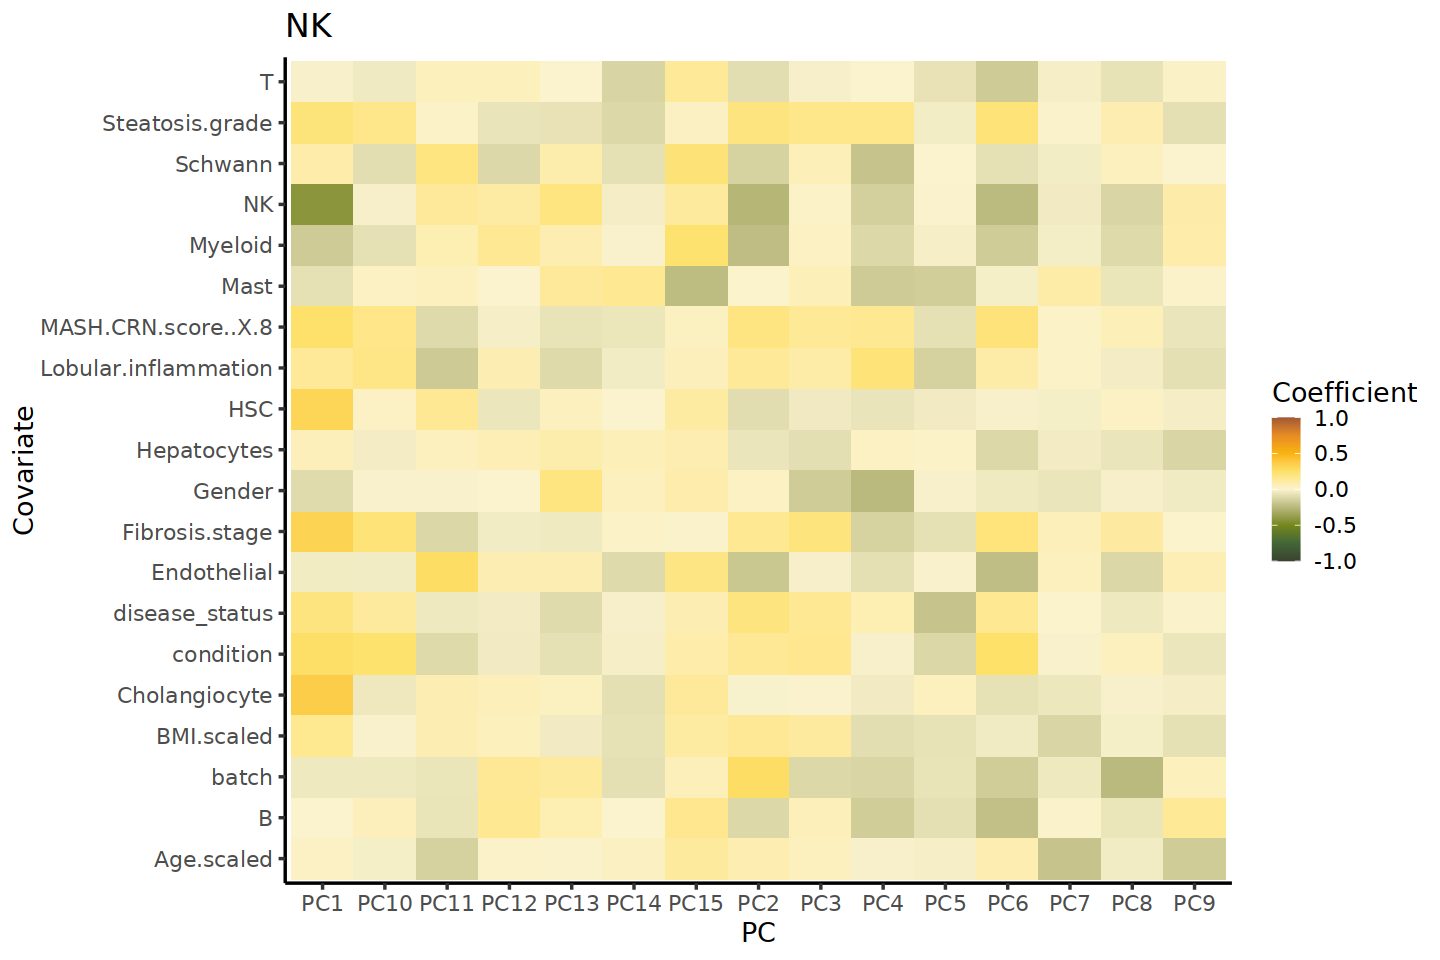

[1] "15 PCs cover 38.828% of variance for Bulk"
[1] "HL181029 is an outlier on PC2 for Bulk"
[2] "HL160022 is an outlier on PC2 for Bulk"
[1] "HL210727 is an outlier on PC5 for Bulk"
[1] "HL190603 is an outlier on PC6 for Bulk"
[2] "HL170055 is an outlier on PC6 for Bulk"
[3] "HL190606 is an outlier on PC6 for Bulk"
[1] "HL210727 is an outlier on PC7 for Bulk"
[2] "HL220402 is an outlier on PC7 for Bulk"
[1] "HL190603 is an outlier on PC8 for Bulk"
[2] "HL220402 is an outlier on PC8 for Bulk"
[3] "HL190606 is an outlier on PC8 for Bulk"
[1] "HL190606 is an outlier on PC9 for Bulk"
[1] "HL210727 is an outlier on PC10 for Bulk"
[2] "HL190603 is an outlier on PC10 for Bulk"
[1] "HL160035 is an outlier on PC11 for Bulk"
[1] "HL160032 is an outlier on PC12 for Bulk"
[1] "HL160032 is an outlier on PC13 for Bulk"
[2] "HL160035 is an outlier on PC13 for Bulk"
[1] "HL220825 is an outlier on PC14 for Bulk"
[2] "HL160035 is an outlier on PC14 for Bulk"
[1] "HL220825 is an outlier on PC15 for Bulk

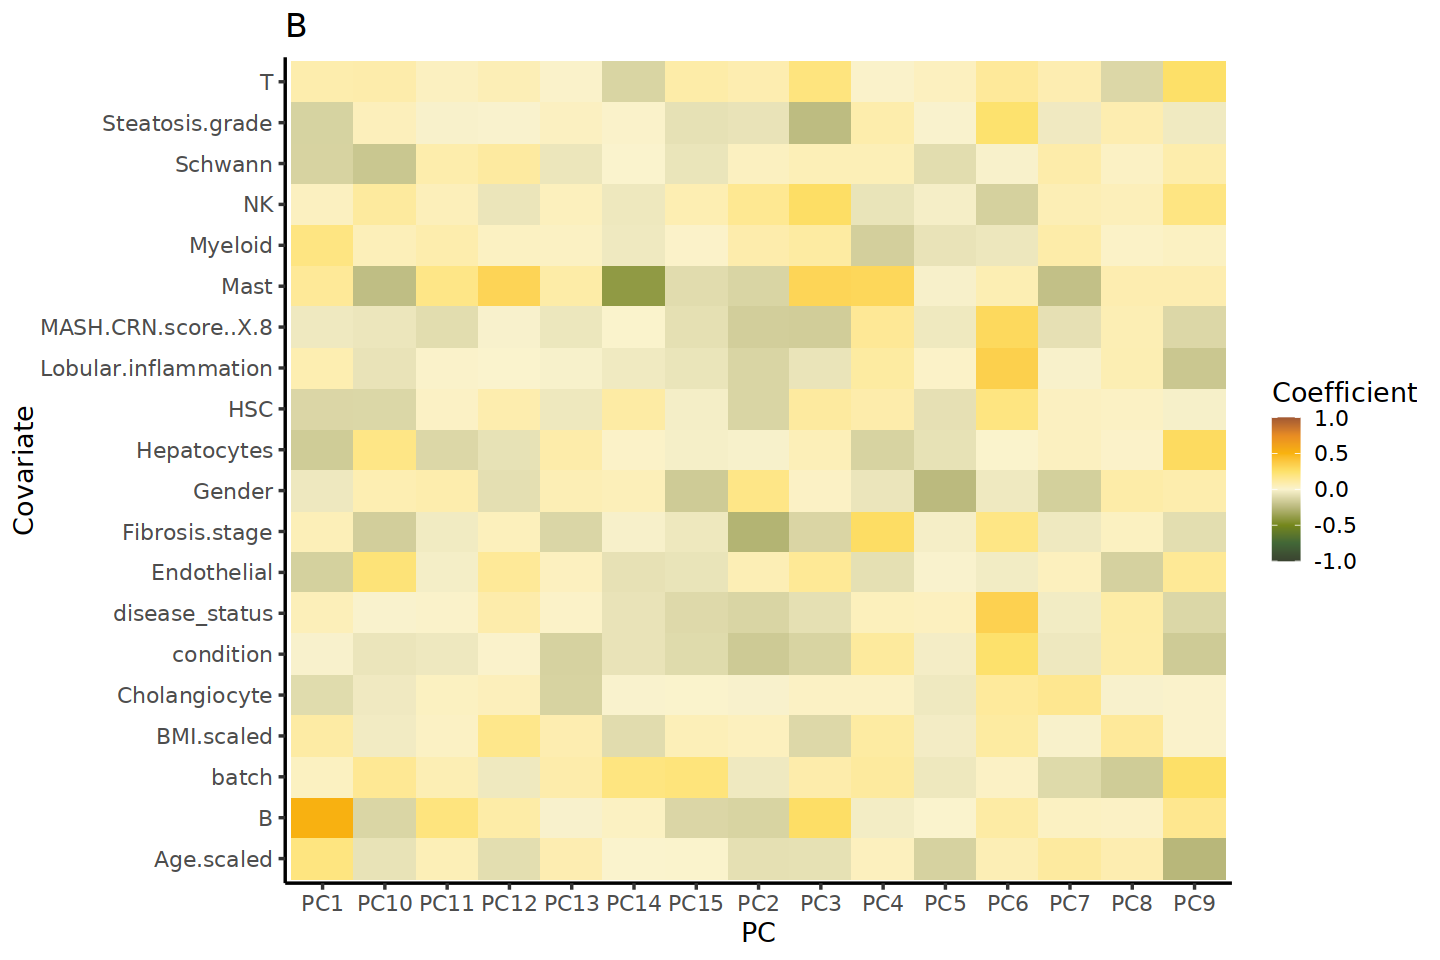

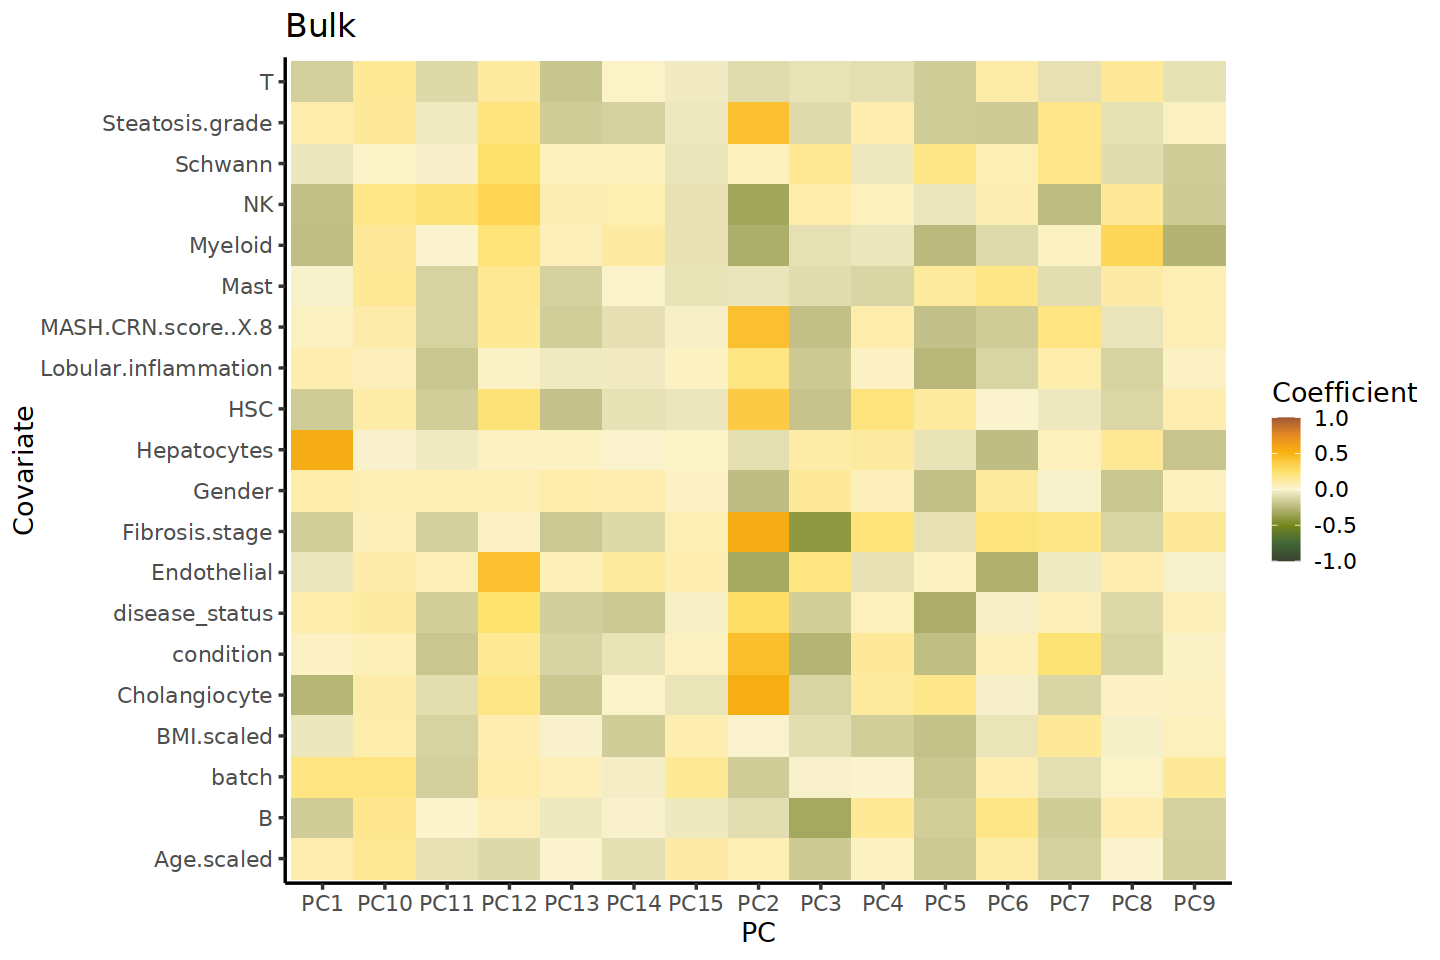

In [73]:
indir <- '/nfs/lab/projects/nash_nafld_liver/downstream_all/count.matrices/H3K27ac/'
outdir <- '/nfs/lab/projects/nash_nafld_liver/downstream_all/06_H3K27acQTLs/covariates/'

n_pc <- 15

##### NAME YOUR FILES #####
for (cell.type in unique_cell_types){
    # Not enough stuff for these cell types
    if (cell.type %in% c('Mast','Schwann')) {
        next
    }
    #tmm.filename <- paste(indir, cell.type, '_perdonor.H3K27ac.TMM.tsv', sep = "")
    int.filename <- paste(indir, cell.type, '_perdonor.H3K27ac.INT.tsv', sep = "")
    pc.filename <- paste(outdir, cell.type, '_perdonor.H3K27ac.INT.', n_pc,'.PCs.tsv', sep = "")
    cor.filename <- paste(outdir, cell.type, '_perdonor.H3K27ac.INT.', n_pc,'.PCs.correlation.tsv', sep = "")
    make_PC_covariate_mat(cell.type, expr.mat.filename=int.filename, pc.filename, 
                          cor.filename, n_pc=15, meta)
}

[1] "15 PCs cover 32.339% of variance for Endothelial"
[1] "HL220216 is an outlier on PC4 for Endothelial"
[1] "HL230325 is an outlier on PC6 for Endothelial"
[2] "HL211122 is an outlier on PC6 for Endothelial"
[1] "HL160017 is an outlier on PC7 for Endothelial"
[2] "HL220127 is an outlier on PC7 for Endothelial"
[1] "HL160017 is an outlier on PC8 for Endothelial"
[1] "HL200805 is an outlier on PC9 for Endothelial"
[1] "HL200525 is an outlier on PC10 for Endothelial"
[1] "HL230325 is an outlier on PC11 for Endothelial"
[2] "HL160017 is an outlier on PC11 for Endothelial"
[1] "HL211122 is an outlier on PC12 for Endothelial"
[1] "HL160041 is an outlier on PC13 for Endothelial"
[2] "HL211122 is an outlier on PC13 for Endothelial"
[3] "HL220127 is an outlier on PC13 for Endothelial"
[1] "HL221019 is an outlier on PC14 for Endothelial"
[2] "HL220825 is an outlier on PC14 for Endothelial"
[1] "HL221215 is an outlier on PC15 for Endothelial"
[2] "HL210621 is an outlier on PC15 for Endothelial

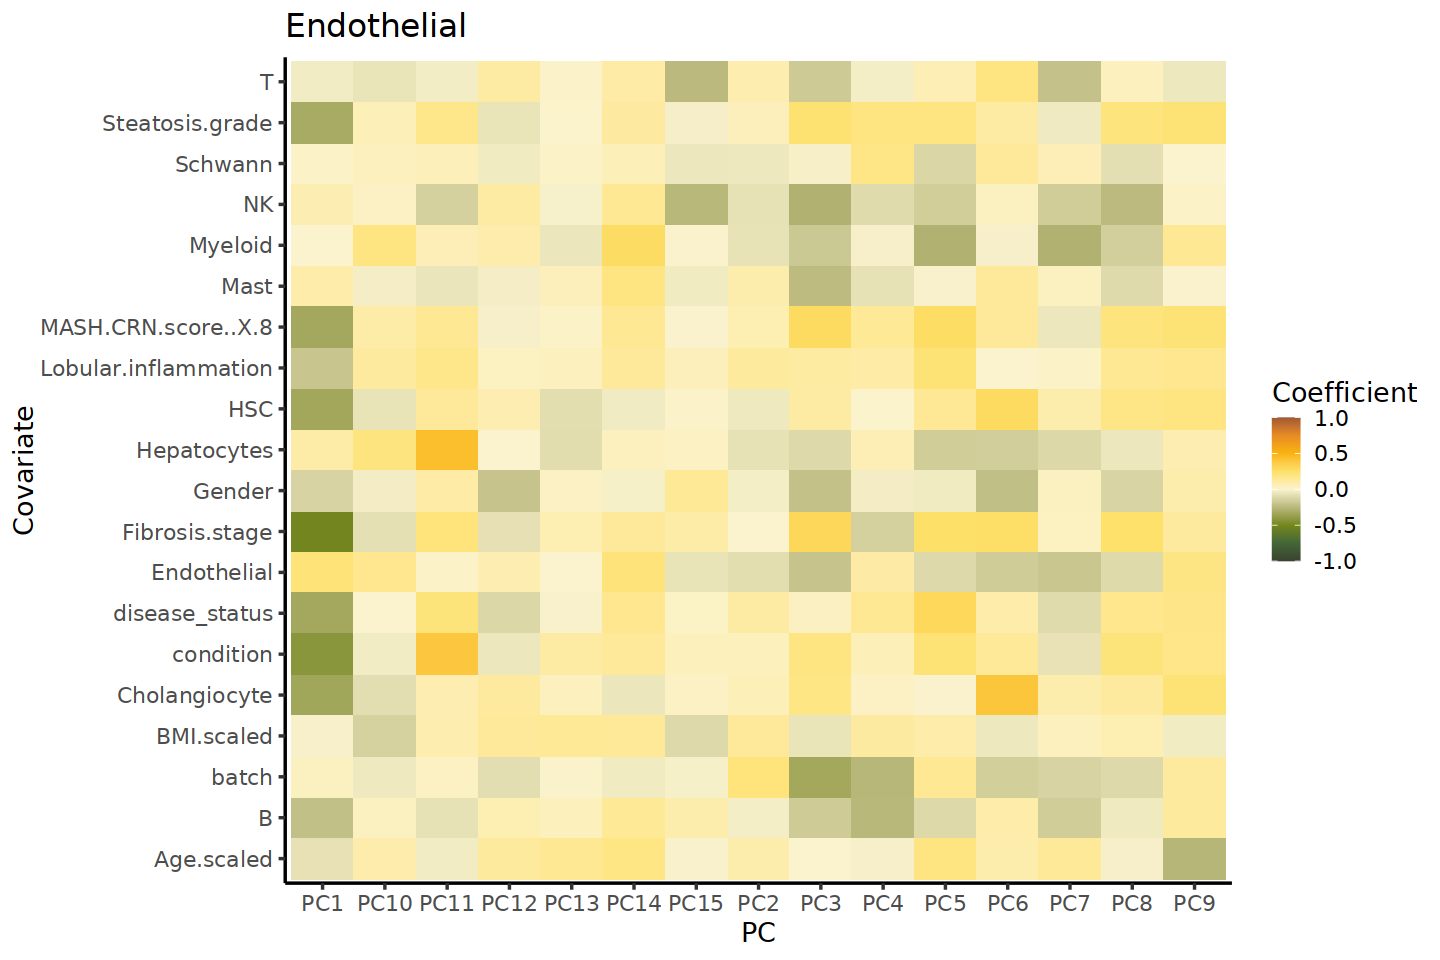

[1] "15 PCs cover 35.475% of variance for T"
[1] "HL221019 is an outlier on PC1 for T"
[1] "HL211025 is an outlier on PC2 for T"
[1] "HL211025 is an outlier on PC3 for T"
[1] "HL230302 is an outlier on PC4 for T"
[1] "HL160040 is an outlier on PC5 for T"
[1] "HL210120 is an outlier on PC6 for T" "HL220210 is an outlier on PC6 for T"
[3] "HL170064 is an outlier on PC6 for T"
[1] "HL160042 is an outlier on PC7 for T" "HL200615 is an outlier on PC7 for T"
[3] "HL170064 is an outlier on PC7 for T"
[1] "HL210120 is an outlier on PC8 for T" "HL170046 is an outlier on PC8 for T"
[3] "HL220210 is an outlier on PC8 for T"
[1] "HL191216 is an outlier on PC9 for T"
[1] "HL200525 is an outlier on PC10 for T"
[2] "HL191216 is an outlier on PC10 for T"
[1] "HL211025 is an outlier on PC11 for T"
[2] "HL200615 is an outlier on PC11 for T"
[1] "HL170046 is an outlier on PC12 for T"
[2] "HL190624 is an outlier on PC12 for T"
[1] "HL230316 is an outlier on PC13 for T"
[2] "HL210726 is an outlier on PC13 

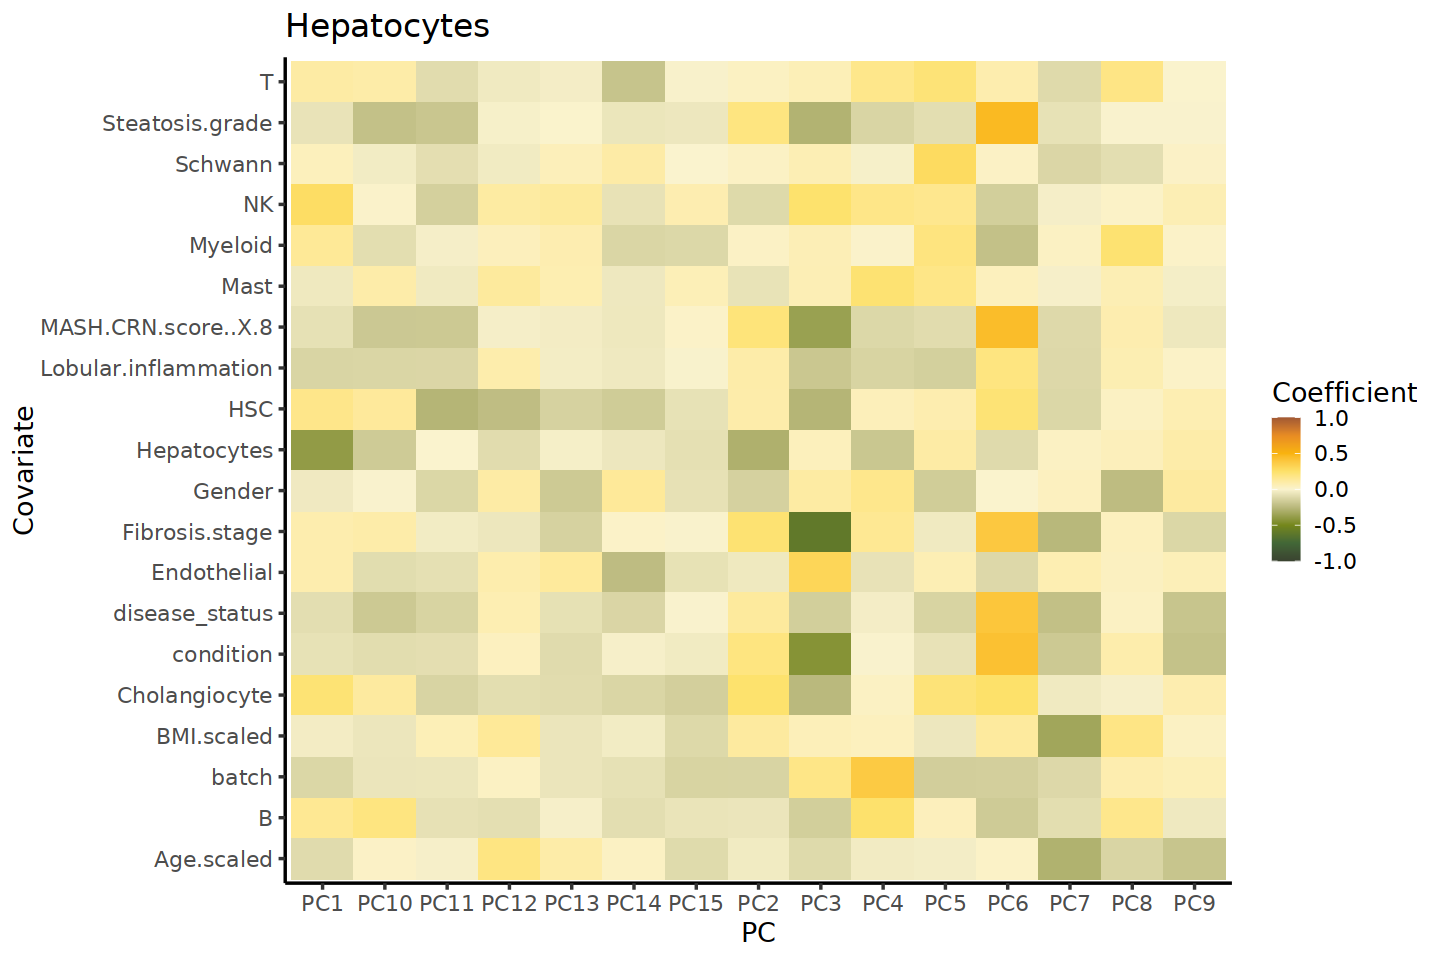

[1] "15 PCs cover 30.878% of variance for HSC"
[1] "HL160026 is an outlier on PC5 for HSC"
[2] "HL200115 is an outlier on PC5 for HSC"
[1] "HL220405 is an outlier on PC7 for HSC"
[1] "HL160030 is an outlier on PC8 for HSC"
[1] "HL160030 is an outlier on PC9 for HSC"
[1] "HL200925 is an outlier on PC10 for HSC"
[2] "HL160026 is an outlier on PC10 for HSC"
[3] "HL220210 is an outlier on PC10 for HSC"
[1] "HL200525 is an outlier on PC12 for HSC"
[2] "HL211025 is an outlier on PC12 for HSC"
[1] "HL200525 is an outlier on PC13 for HSC"
[2] "HL170062 is an outlier on PC13 for HSC"
[1] "HL210120 is an outlier on PC14 for HSC"
[2] "HL200925 is an outlier on PC14 for HSC"
[3] "HL220825 is an outlier on PC14 for HSC"
[1] "HL230302 is an outlier on PC15 for HSC"
[2] "HL220210 is an outlier on PC15 for HSC"


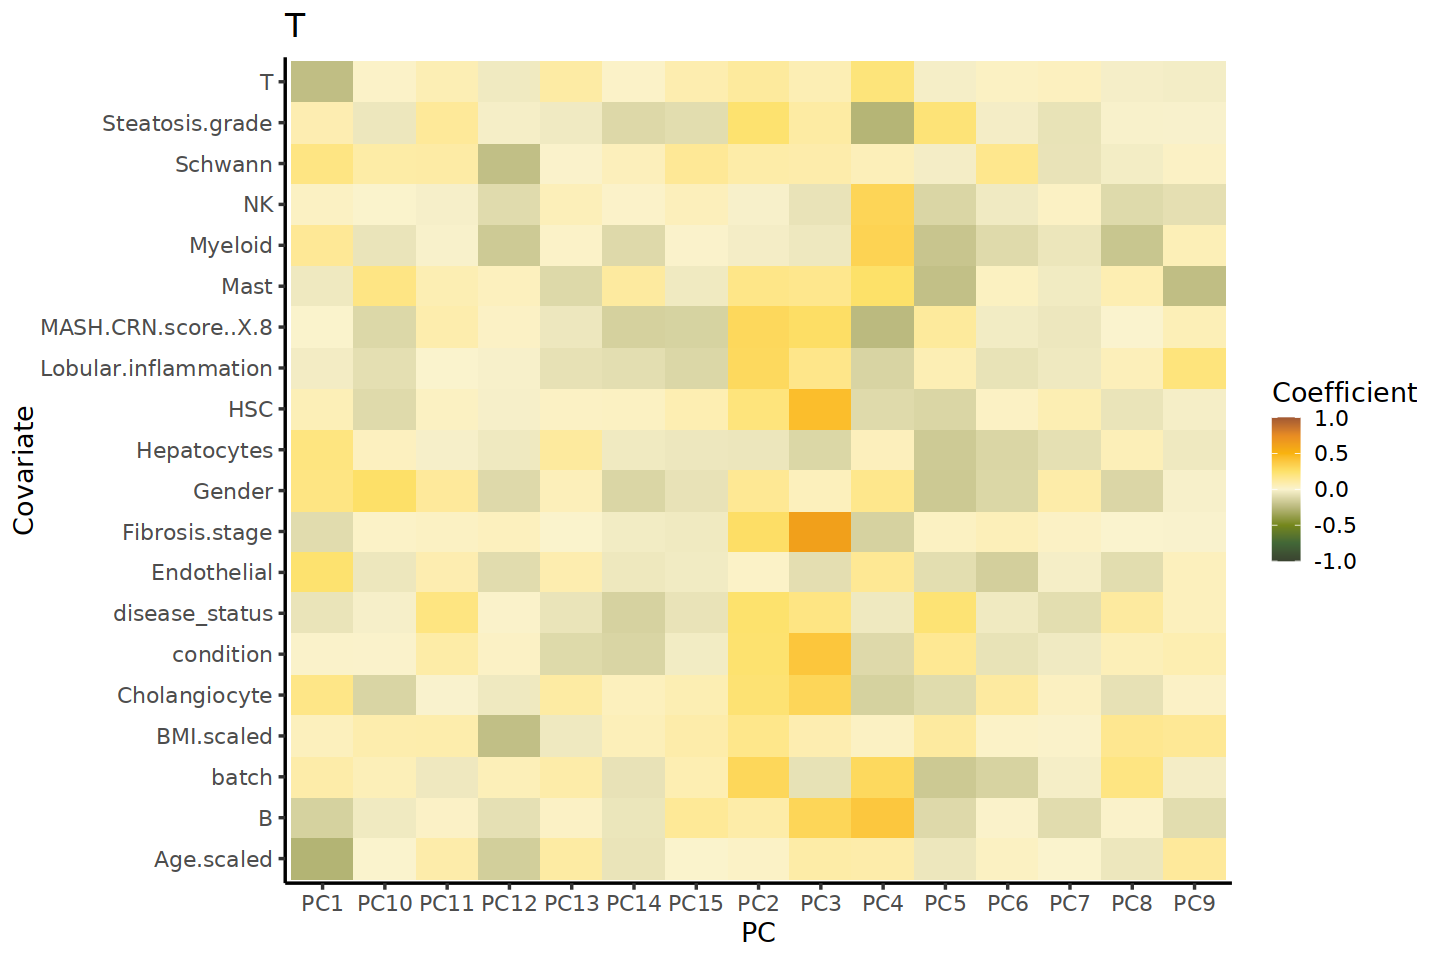

[1] "15 PCs cover 33.123% of variance for Cholangiocyte"
[1] "HL201120 is an outlier on PC4 for Cholangiocyte"
[1] "HL190624 is an outlier on PC5 for Cholangiocyte"
[1] "HL220210 is an outlier on PC6 for Cholangiocyte"
[1] "HL201120 is an outlier on PC7 for Cholangiocyte"
[1] "HL170052 is an outlier on PC8 for Cholangiocyte"
[2] "HL201120 is an outlier on PC8 for Cholangiocyte"
[3] "HL180809 is an outlier on PC8 for Cholangiocyte"
[1] "HL220210 is an outlier on PC9 for Cholangiocyte"
[2] "HL220127 is an outlier on PC9 for Cholangiocyte"
[1] "HL150013 is an outlier on PC10 for Cholangiocyte"
[2] "HL220628 is an outlier on PC10 for Cholangiocyte"
[1] "HL230324 is an outlier on PC11 for Cholangiocyte"
[2] "HL170047 is an outlier on PC11 for Cholangiocyte"
[3] "HL170048 is an outlier on PC11 for Cholangiocyte"
[1] "HL150013 is an outlier on PC12 for Cholangiocyte"
[2] "HL220210 is an outlier on PC12 for Cholangiocyte"
[3] "HL220628 is an outlier on PC12 for Cholangiocyte"
[1] "HL220825 is 

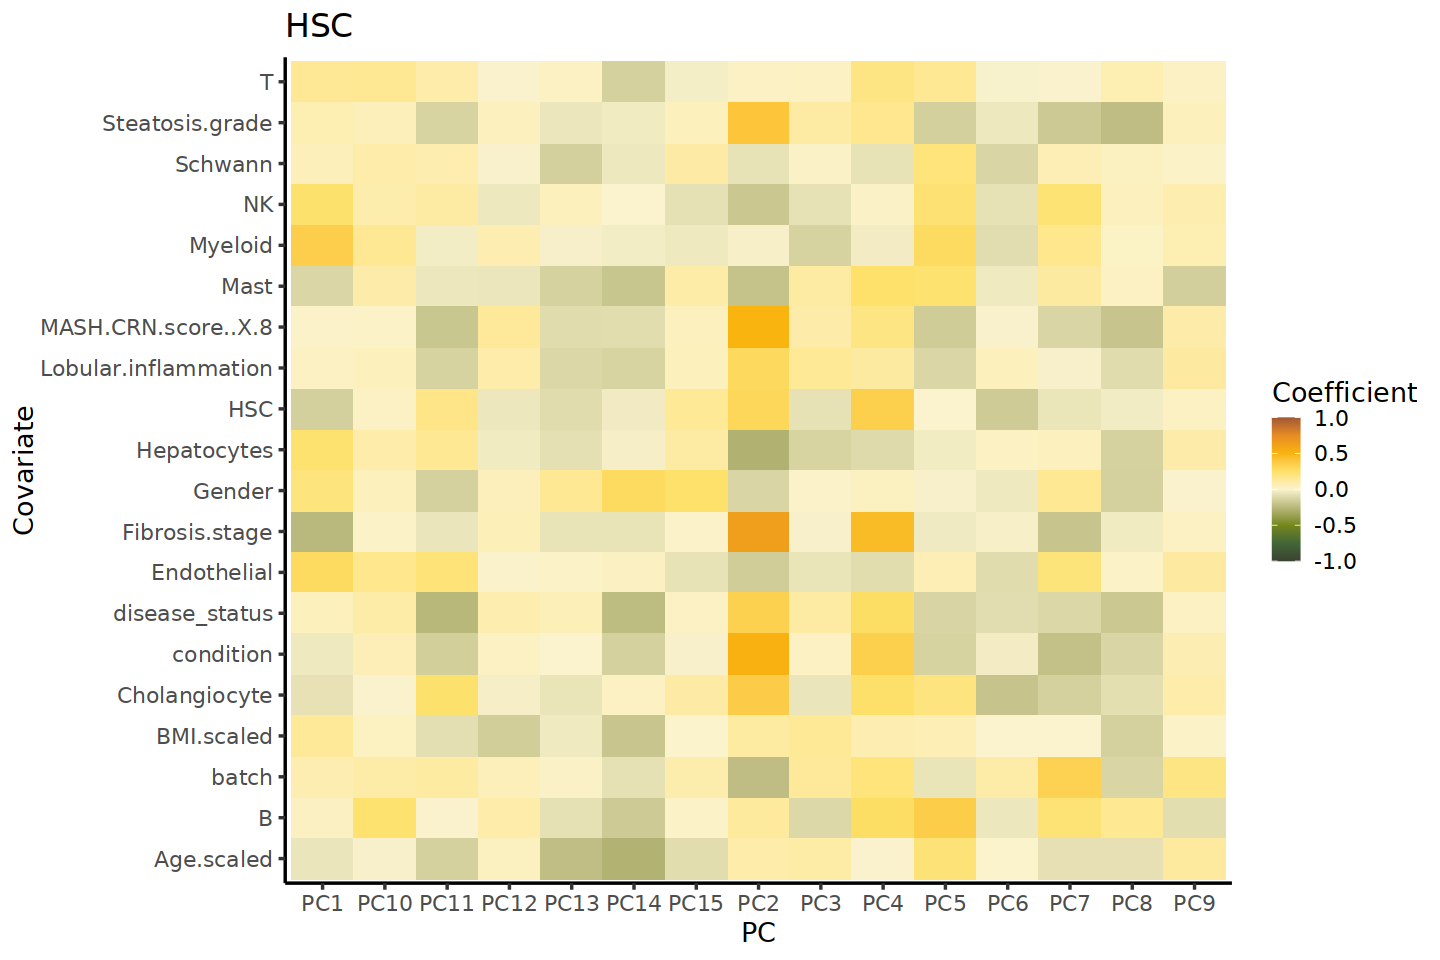

[1] "15 PCs cover 32.529% of variance for Myeloid"
[1] "HL170049 is an outlier on PC3 for Myeloid"
[1] "HL220216 is an outlier on PC4 for Myeloid"
[1] "HL190827 is an outlier on PC6 for Myeloid"
[1] "HL150001 is an outlier on PC7 for Myeloid"
[1] "HL200115 is an outlier on PC8 for Myeloid"
[2] "HL201024 is an outlier on PC8 for Myeloid"
[3] "HL190827 is an outlier on PC8 for Myeloid"
[1] "HL201024 is an outlier on PC9 for Myeloid"
[2] "HL190603 is an outlier on PC9 for Myeloid"
[1] "HL190603 is an outlier on PC10 for Myeloid"
[1] "HL190603 is an outlier on PC11 for Myeloid"
[2] "HL170055 is an outlier on PC11 for Myeloid"
[1] "HL220613 is an outlier on PC12 for Myeloid"
[2] "HL160032 is an outlier on PC12 for Myeloid"
[3] "HL190827 is an outlier on PC12 for Myeloid"
[1] "HL220613 is an outlier on PC13 for Myeloid"
[2] "HL190827 is an outlier on PC13 for Myeloid"
[1] "HL170055 is an outlier on PC14 for Myeloid"
[2] "HL190624 is an outlier on PC14 for Myeloid"
[1] "HL150009 is an outlier

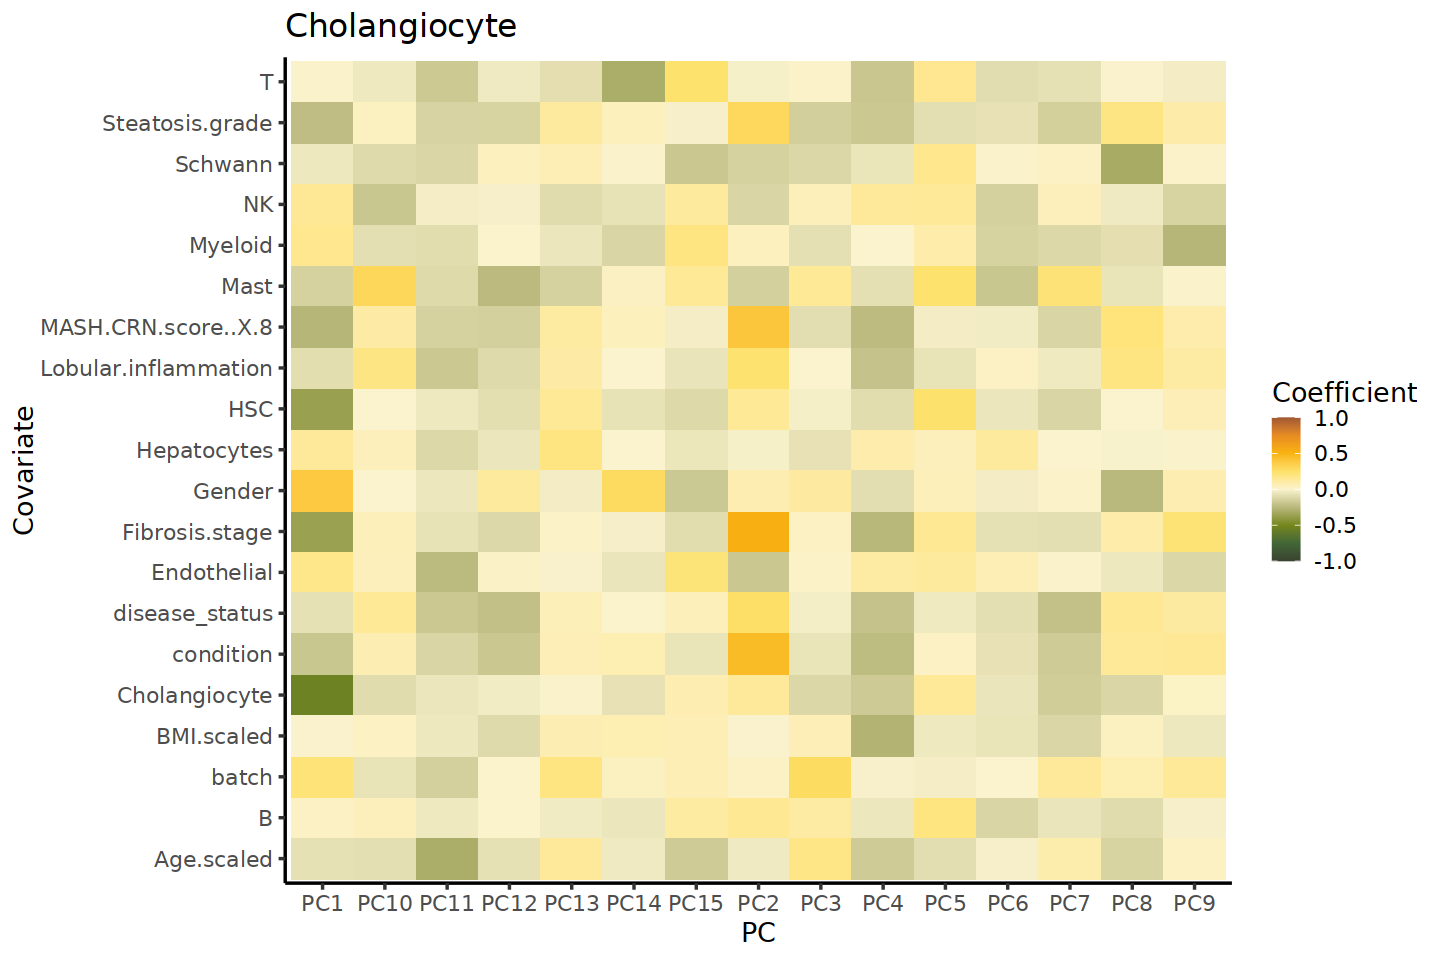

[1] "15 PCs cover 39.095% of variance for NK"
[1] "HL210521 is an outlier on PC2 for NK"
[2] "HL170060 is an outlier on PC2 for NK"
[3] "HL190215 is an outlier on PC2 for NK"
[1] "HL160029 is an outlier on PC3 for NK"
[2] "HL190215 is an outlier on PC3 for NK"
[1] "HL211106 is an outlier on PC4 for NK"
[2] "HL160037 is an outlier on PC4 for NK"
[1] "HL210614 is an outlier on PC5 for NK"
[2] "HL211106 is an outlier on PC5 for NK"
[1] "HL210614 is an outlier on PC6 for NK"
[2] "HL160032 is an outlier on PC6 for NK"
[1] "HL170060 is an outlier on PC7 for NK"
[2] "HL211106 is an outlier on PC7 for NK"
[3] "HL160032 is an outlier on PC7 for NK"
[1] "HL210120 is an outlier on PC8 for NK"
[2] "HL210521 is an outlier on PC8 for NK"
[3] "HL160029 is an outlier on PC8 for NK"
[4] "HL160032 is an outlier on PC8 for NK"
[1] "HL210120 is an outlier on PC9 for NK"
[2] "HL160029 is an outlier on PC9 for NK"
[3] "HL200212 is an outlier on PC9 for NK"
[4] "HL170047 is an outlier on PC9 for NK"
[1] "HL2

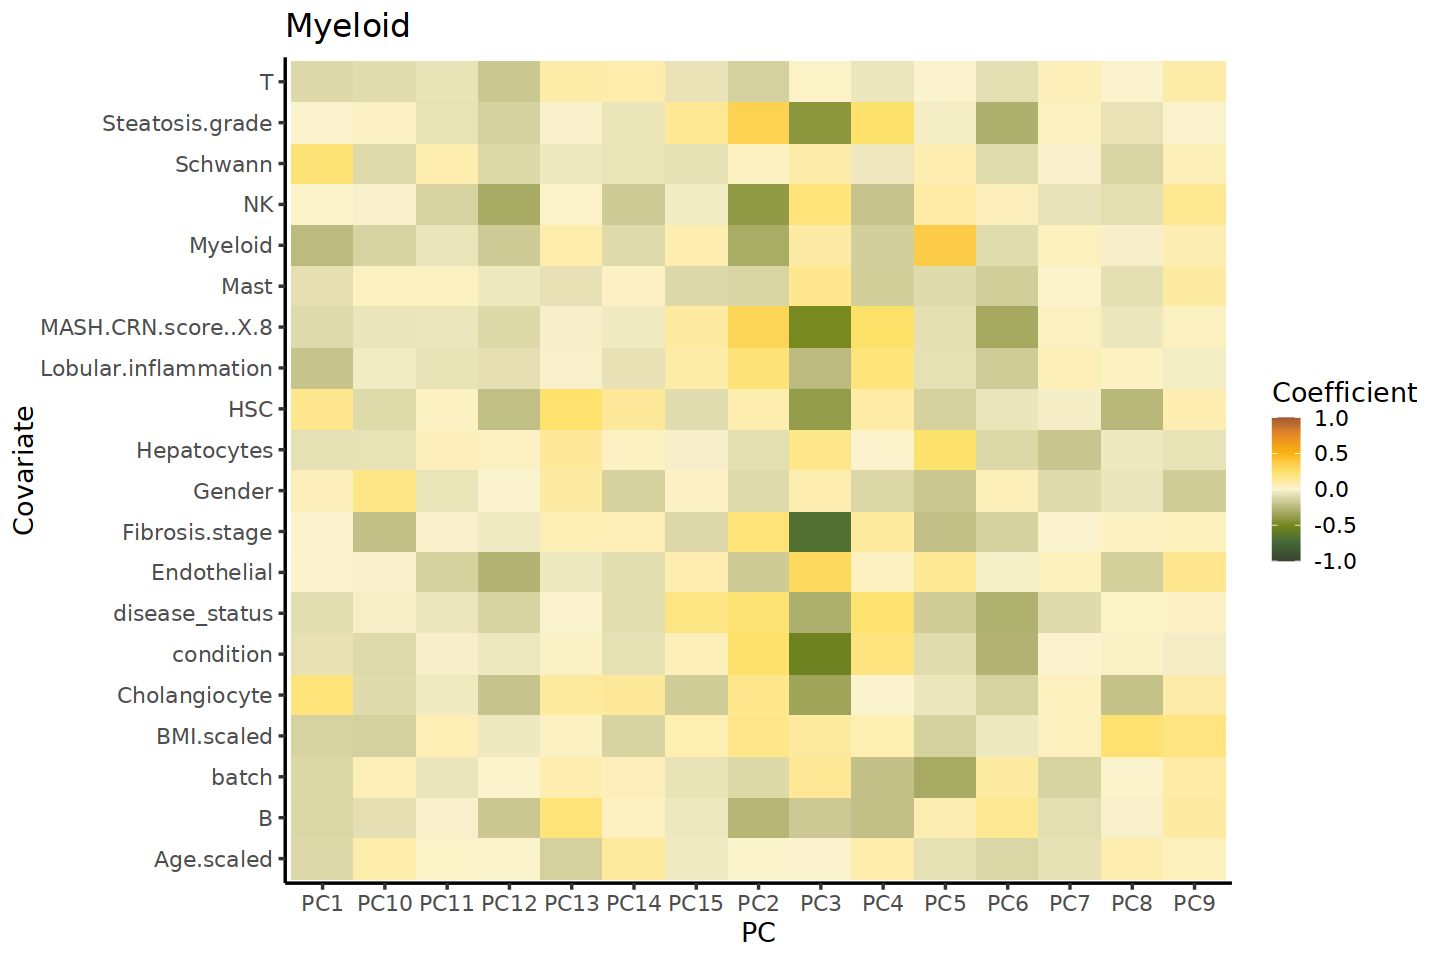

[1] "15 PCs cover 39.929% of variance for B"
[1] "HL221019 is an outlier on PC1 for B" "HL221201 is an outlier on PC1 for B"
[3] "HL201120 is an outlier on PC1 for B"
[1] "HL201120 is an outlier on PC2 for B"
[1] "HL210521 is an outlier on PC3 for B" "HL221119 is an outlier on PC3 for B"
[3] "HL200212 is an outlier on PC3 for B"
[1] "HL221119 is an outlier on PC4 for B"
[1] "HL221201 is an outlier on PC5 for B" "HL221119 is an outlier on PC5 for B"
[3] "HL160037 is an outlier on PC5 for B" "HL190827 is an outlier on PC5 for B"
[1] "HL221119 is an outlier on PC6 for B" "HL160037 is an outlier on PC6 for B"
[1] "HL191025 is an outlier on PC7 for B" "HL211025 is an outlier on PC7 for B"
[1] "HL191025 is an outlier on PC8 for B" "HL190827 is an outlier on PC8 for B"
[1] "HL220216 is an outlier on PC9 for B" "HL211025 is an outlier on PC9 for B"
[3] "HL170064 is an outlier on PC9 for B"
[1] "HL230302 is an outlier on PC10 for B"
[1] "HL210706 is an outlier on PC11 for B"
[2] "HL220210 is an

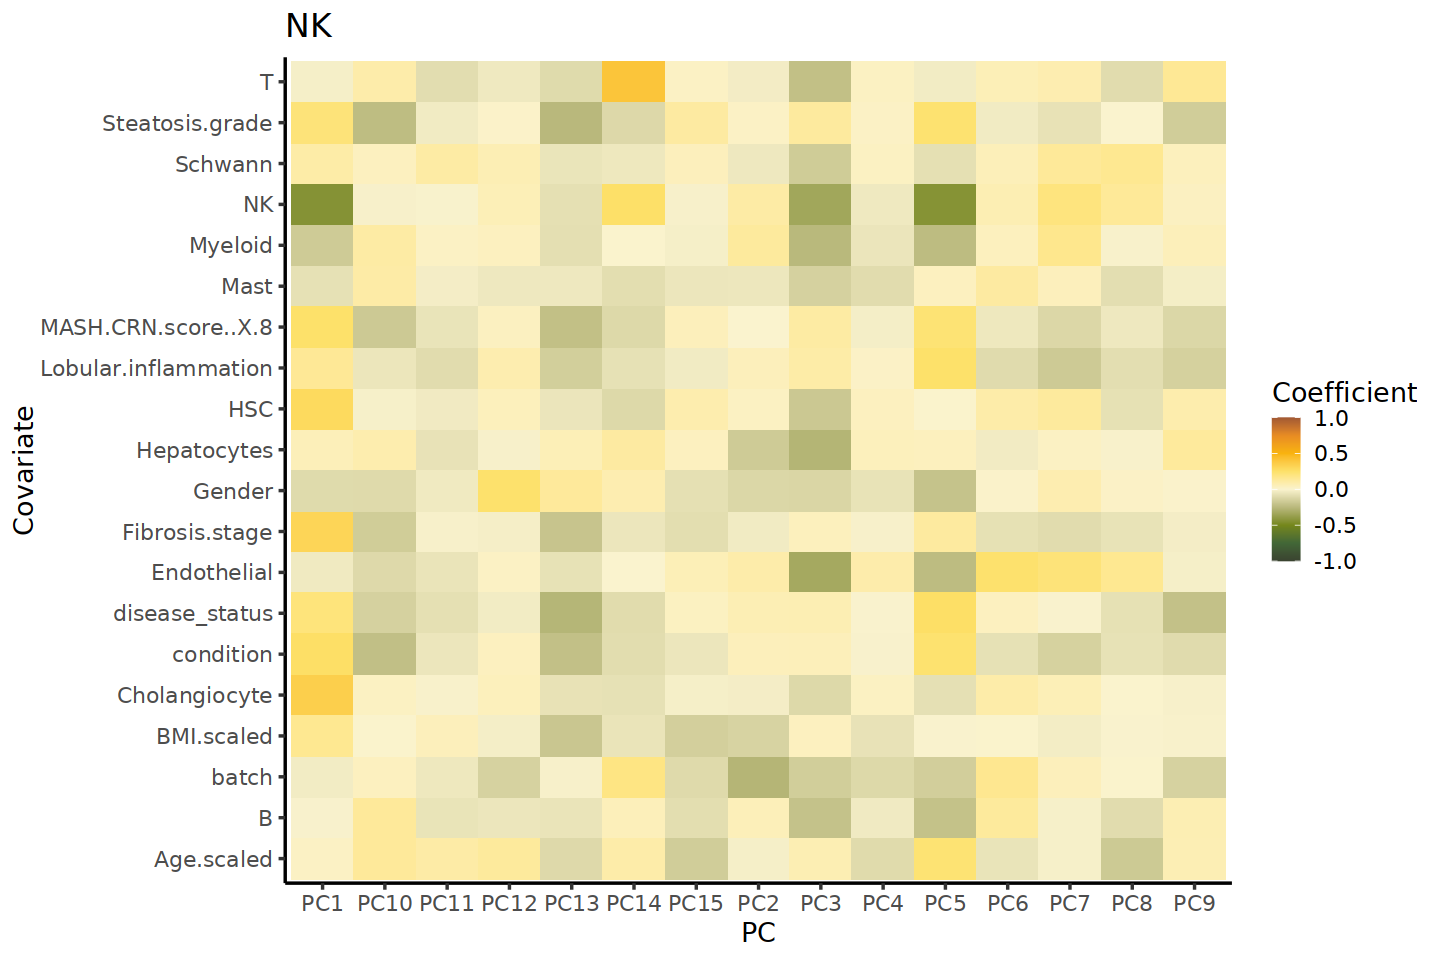

[1] "15 PCs cover 53.206% of variance for Bulk"
[1] "HL181029 is an outlier on PC3 for Bulk"
[2] "HL160022 is an outlier on PC3 for Bulk"
[1] "HL220402 is an outlier on PC4 for Bulk"
[1] "HL210727 is an outlier on PC6 for Bulk"
[1] "HL220216 is an outlier on PC9 for Bulk"
[2] "HL220402 is an outlier on PC9 for Bulk"
[3] "HL190606 is an outlier on PC9 for Bulk"
[1] "HL220127 is an outlier on PC10 for Bulk"
[2] "HL190606 is an outlier on PC10 for Bulk"
[1] "HL210727 is an outlier on PC11 for Bulk"
[2] "HL160022 is an outlier on PC11 for Bulk"
[3] "HL190606 is an outlier on PC11 for Bulk"
[1] "HL201120 is an outlier on PC12 for Bulk"
[2] "HL160022 is an outlier on PC12 for Bulk"
[3] "HL160035 is an outlier on PC12 for Bulk"
[1] "HL210727 is an outlier on PC13 for Bulk"
[2] "HL190603 is an outlier on PC13 for Bulk"
[3] "HL160035 is an outlier on PC13 for Bulk"
[1] "HL190603 is an outlier on PC14 for Bulk"
[2] "HL160035 is an outlier on PC14 for Bulk"
[1] "HL160032 is an outlier on PC15 for

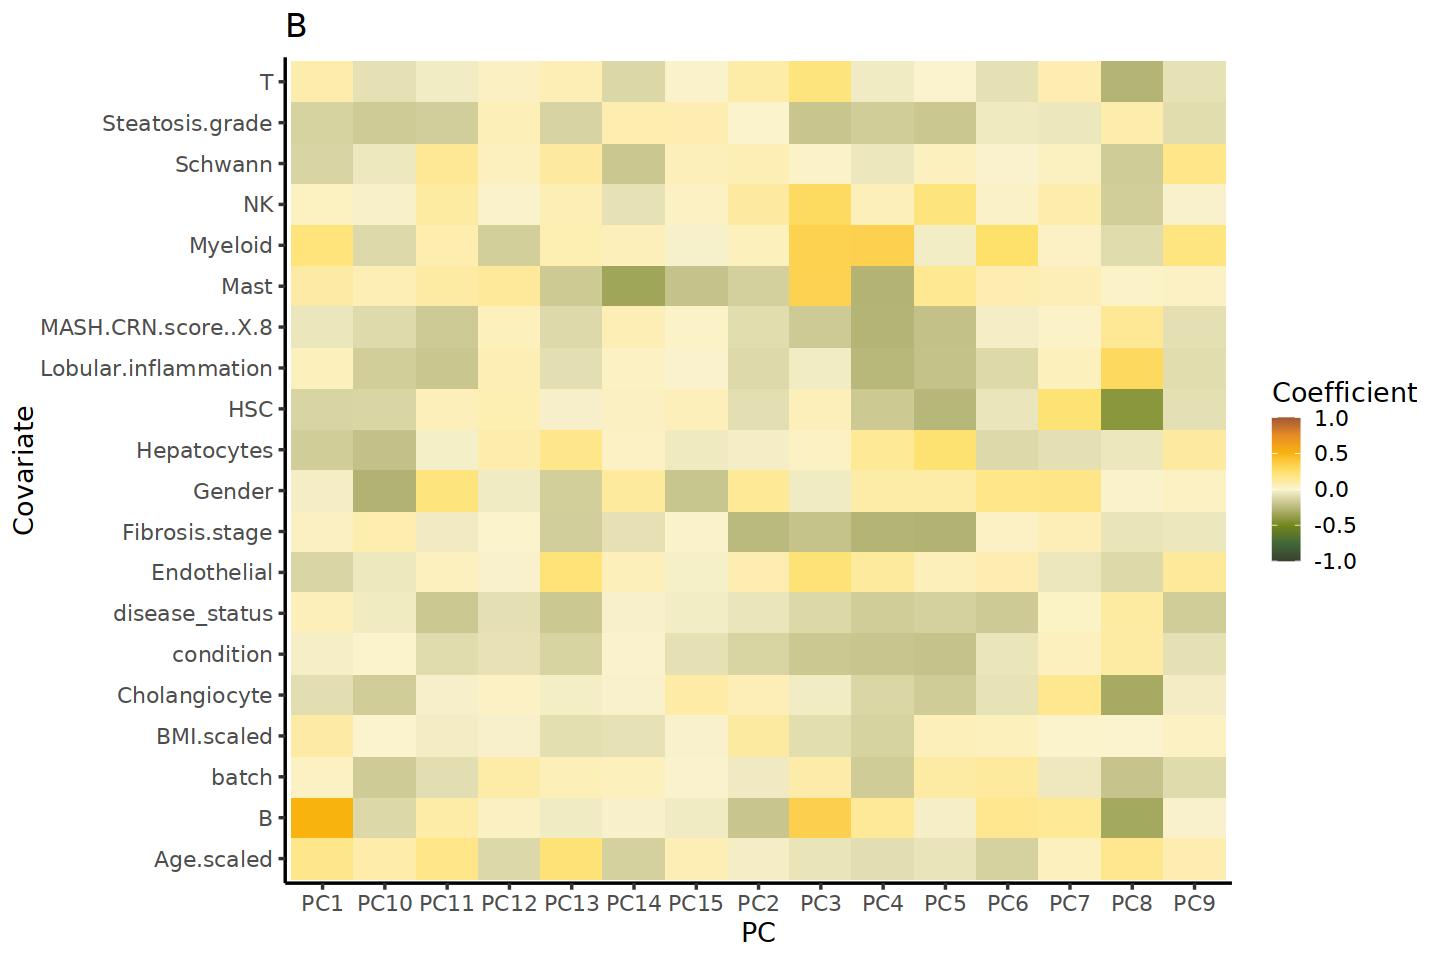

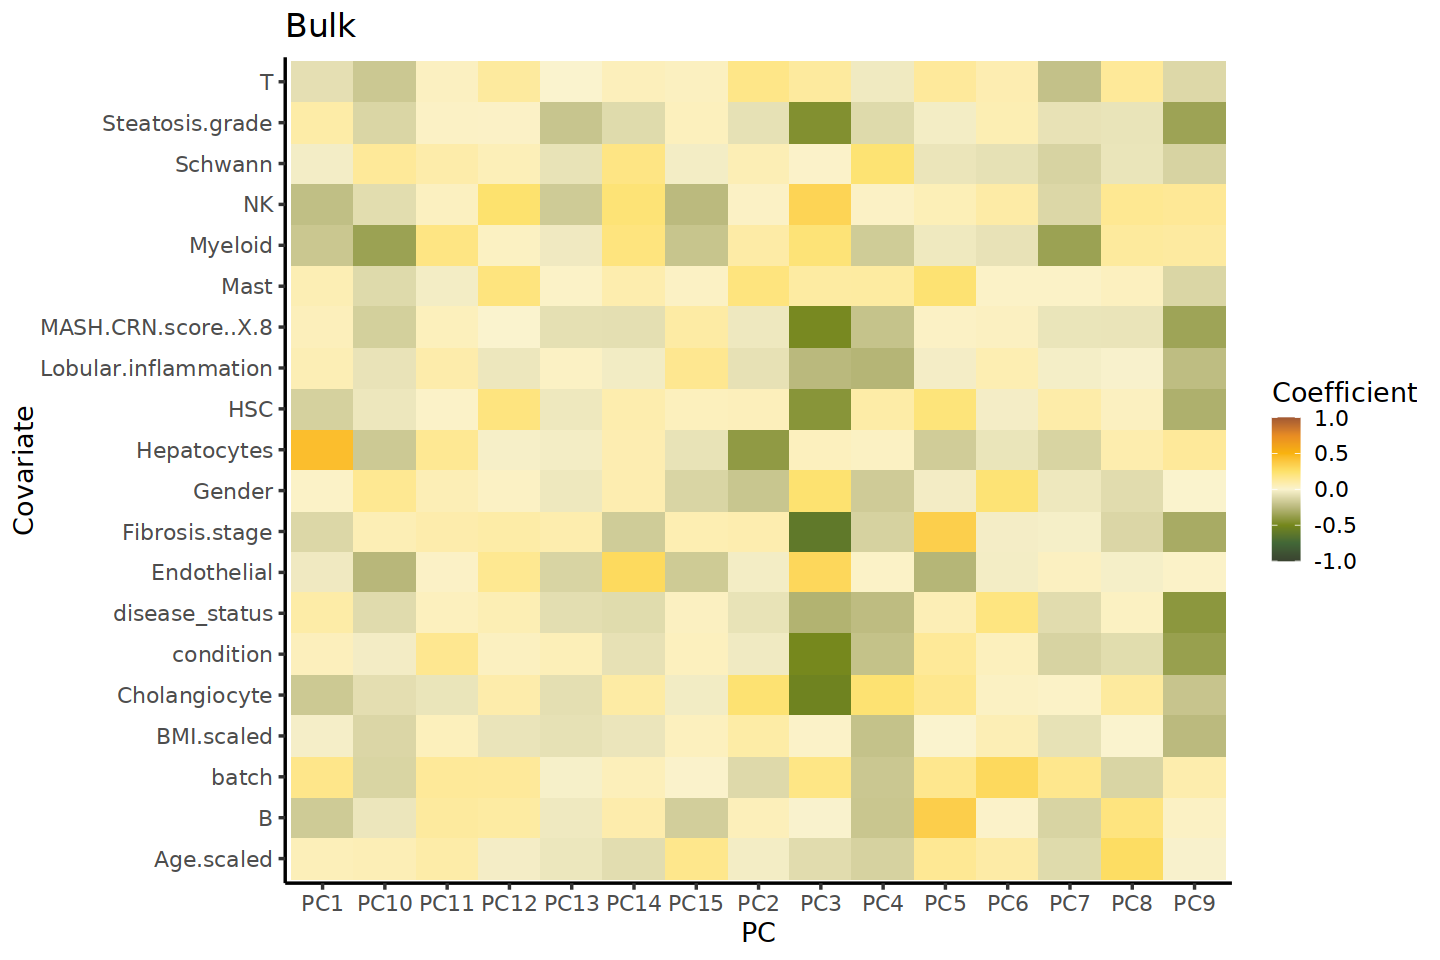

In [10]:
indir <- '/nfs/lab/projects/nash_nafld_liver/downstream_all/count.matrices/H3K27ac/'
outdir <- '/nfs/lab/projects/nash_nafld_liver/downstream_all/06_H3K27acQTLs/covariates/'

n_pc <- 15

##### NAME YOUR FILES #####
for (cell.type in unique_cell_types){
    if (cell.type %in% c('Mast','Schwann')) {
        next
    }
    tmm.filename <- paste(indir, cell.type, '_perdonor.H3K27ac.TMM.tsv', sep = "")
    #int.filename <- paste(indir, cell.type, '_perdonor.H3K27ac.INT.tsv', sep = "")
    pc.filename <- paste(outdir, cell.type, '_perdonor.H3K27ac.TMM.', n_pc,'.PCs.tsv', sep = "")
    cor.filename <- paste(outdir, cell.type, '_perdonor.H3K27ac.TMM.', n_pc,'.PCs.correlation.tsv', sep = "")
    make_PC_covariate_mat(cell.type, expr.mat.filename=tmm.filename, pc.filename,
                          cor.filename, n_pc=15, meta)
}

[1] "15 PCs cover 31.854% of variance for Endothelial"
[1] "HL210726 is an outlier on PC3 for Endothelial"
[1] "HL170060 is an outlier on PC4 for Endothelial"
[1] "HL220402 is an outlier on PC5 for Endothelial"
[1] "HL190909 is an outlier on PC6 for Endothelial"
[2] "HL220402 is an outlier on PC6 for Endothelial"
[1] "HL190326 is an outlier on PC7 for Endothelial"
[1] "HL220216 is an outlier on PC8 for Endothelial"
[1] "HL210726 is an outlier on PC9 for Endothelial"
[2] "HL221201 is an outlier on PC9 for Endothelial"
[1] "HL190909 is an outlier on PC10 for Endothelial"
[2] "HL181031 is an outlier on PC10 for Endothelial"
[1] "HL221215 is an outlier on PC11 for Endothelial"
[1] "HL160026 is an outlier on PC12 for Endothelial"
[1] "HL210726 is an outlier on PC13 for Endothelial"
[2] "HL221201 is an outlier on PC13 for Endothelial"
[3] "HL221215 is an outlier on PC13 for Endothelial"
[1] "HL160030 is an outlier on PC14 for Endothelial"
[2] "HL220613 is an outlier on PC14 for Endothelial"


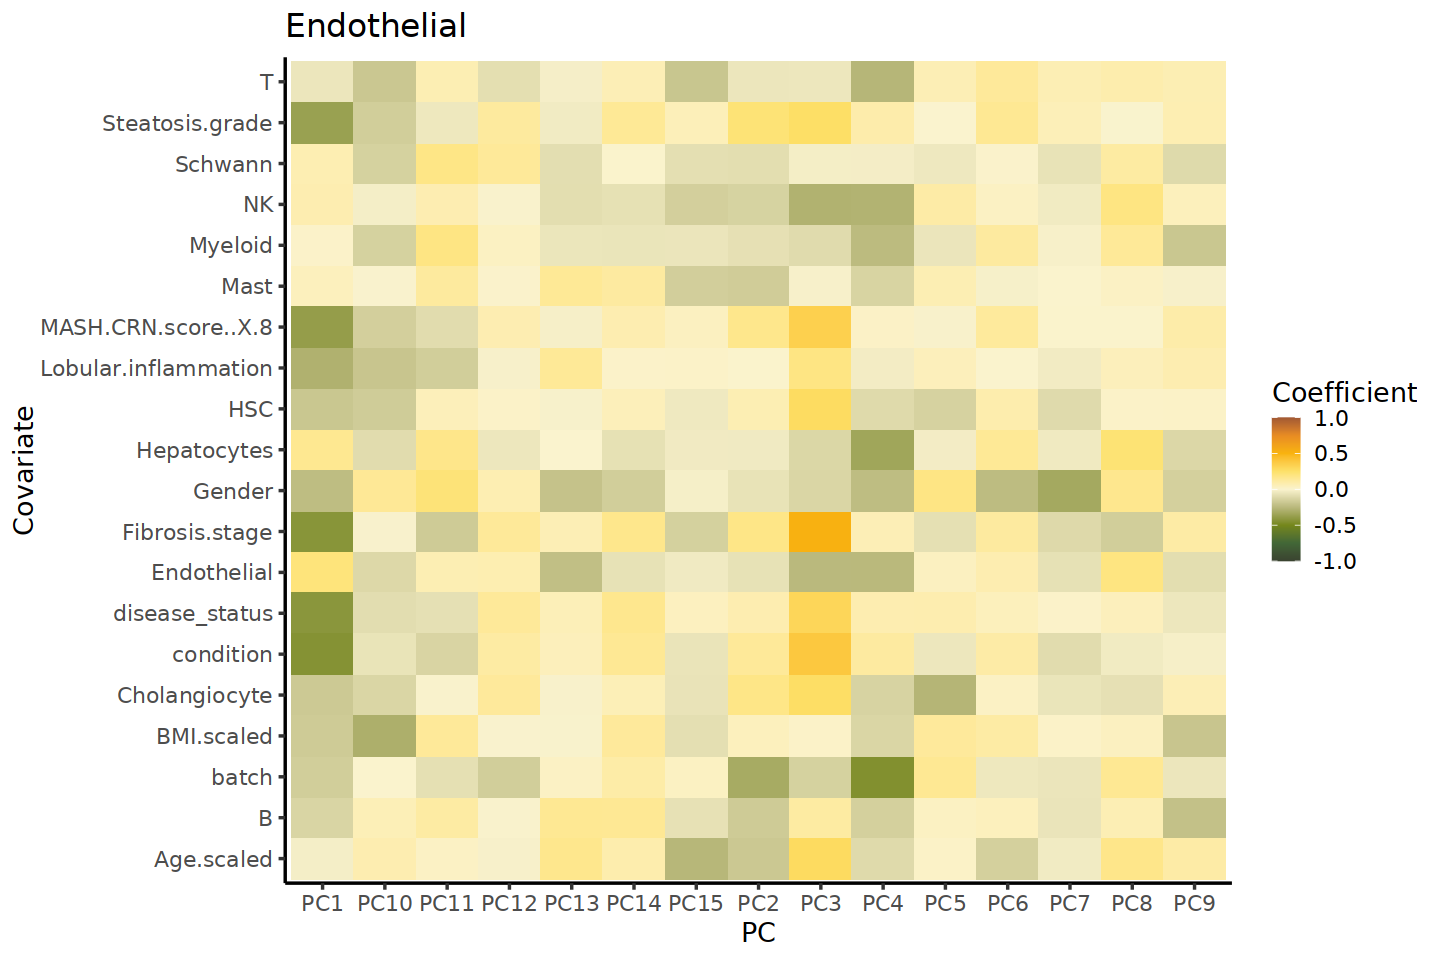

[1] "15 PCs cover 42.927% of variance for T"
[1] "HL160029 is an outlier on PC2 for T"
[1] "HL230316 is an outlier on PC3 for T" "HL221201 is an outlier on PC3 for T"
[3] "HL170058 is an outlier on PC3 for T"
[1] "HL160042 is an outlier on PC4 for T" "HL190326 is an outlier on PC4 for T"
[3] "HL201120 is an outlier on PC4 for T"
[1] "HL230316 is an outlier on PC5 for T" "HL190326 is an outlier on PC5 for T"
[3] "HL220210 is an outlier on PC5 for T"
[1] "HL160042 is an outlier on PC6 for T" "HL230302 is an outlier on PC6 for T"
[1] "HL191025 is an outlier on PC7 for T" "HL190326 is an outlier on PC7 for T"
[3] "HL190624 is an outlier on PC7 for T"
[1] "HL160042 is an outlier on PC8 for T" "HL190326 is an outlier on PC8 for T"
[3] "HL190624 is an outlier on PC8 for T"
[1] "HL200805 is an outlier on PC9 for T" "HL191025 is an outlier on PC9 for T"
[3] "HL160040 is an outlier on PC9 for T"
[1] "HL190624 is an outlier on PC10 for T"
[1] "HL230316 is an outlier on PC11 for T"
[2] "HL170058 i

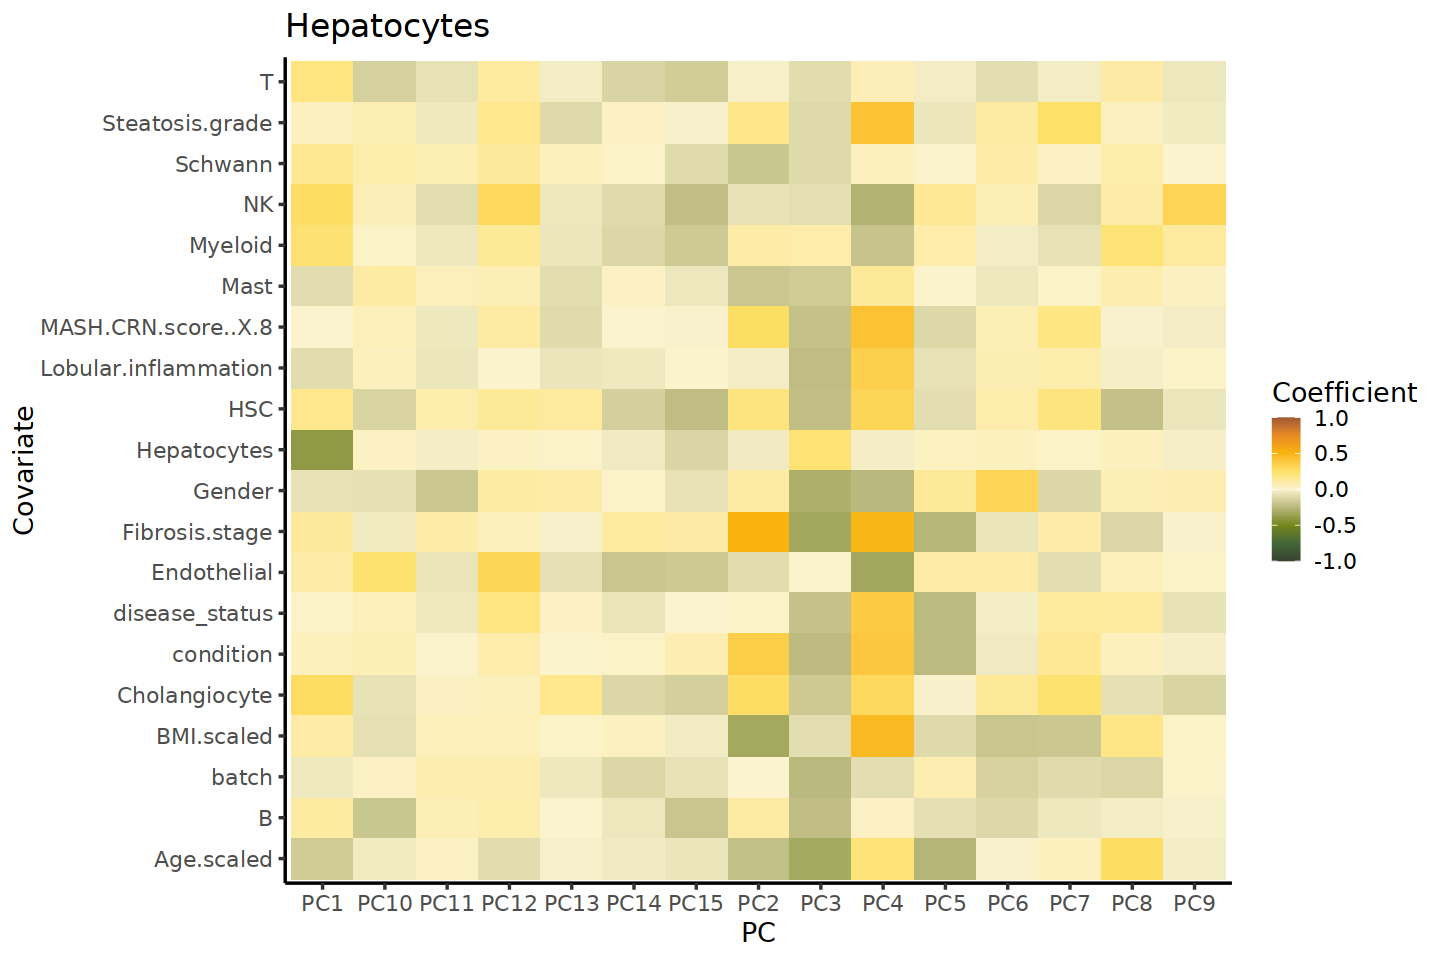

[1] "15 PCs cover 34.359% of variance for HSC"
[1] "HL160026 is an outlier on PC2 for HSC"
[1] "HL190326 is an outlier on PC3 for HSC"
[2] "HL160026 is an outlier on PC3 for HSC"
[1] "HL190326 is an outlier on PC4 for HSC"
[2] "HL170065 is an outlier on PC4 for HSC"
[3] "HL201024 is an outlier on PC4 for HSC"
[1] "HL190326 is an outlier on PC5 for HSC"
[2] "HL170046 is an outlier on PC5 for HSC"
[3] "HL191002 is an outlier on PC5 for HSC"
[1] "HL170065 is an outlier on PC6 for HSC"
[2] "HL191002 is an outlier on PC6 for HSC"
[1] "HL230302 is an outlier on PC7 for HSC"
[2] "HL170065 is an outlier on PC7 for HSC"
[3] "HL200115 is an outlier on PC7 for HSC"
[1] "HL160030 is an outlier on PC8 for HSC"
[2] "HL170046 is an outlier on PC8 for HSC"
[3] "HL200115 is an outlier on PC8 for HSC"
[1] "HL160030 is an outlier on PC9 for HSC"
[2] "HL170046 is an outlier on PC9 for HSC"
[3] "HL200115 is an outlier on PC9 for HSC"
[1] "HL201024 is an outlier on PC10 for HSC"
[2] "HL220216 is an outlier 

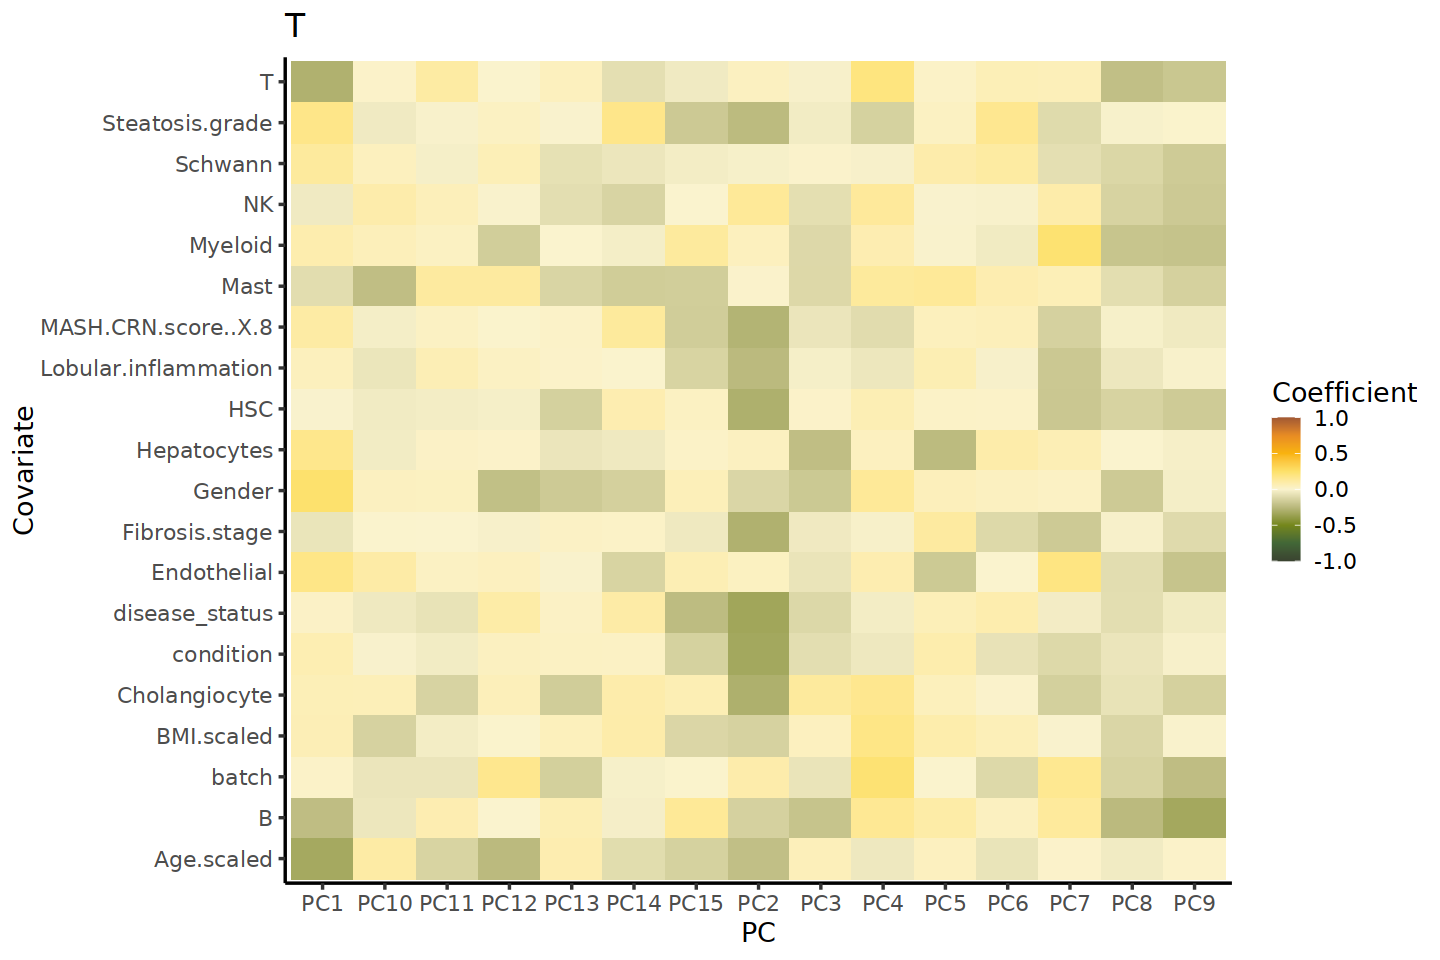

[1] "15 PCs cover 36.859% of variance for Cholangiocyte"
[1] "HL181029 is an outlier on PC2 for Cholangiocyte"
[2] "HL160022 is an outlier on PC2 for Cholangiocyte"
[1] "HL221019 is an outlier on PC3 for Cholangiocyte"
[1] "HL170066 is an outlier on PC4 for Cholangiocyte"
[1] "HL191025 is an outlier on PC5 for Cholangiocyte"
[2] "HL221215 is an outlier on PC5 for Cholangiocyte"
[3] "HL220127 is an outlier on PC5 for Cholangiocyte"
[1] "HL191025 is an outlier on PC6 for Cholangiocyte"
[2] "HL220127 is an outlier on PC6 for Cholangiocyte"
[1] "HL210521 is an outlier on PC7 for Cholangiocyte"
[2] "HL190215 is an outlier on PC7 for Cholangiocyte"
[3] "HL170066 is an outlier on PC7 for Cholangiocyte"
[1] "HL210120 is an outlier on PC8 for Cholangiocyte"
[2] "HL190603 is an outlier on PC8 for Cholangiocyte"
[1] "HL221215 is an outlier on PC9 for Cholangiocyte"
[2] "HL190215 is an outlier on PC9 for Cholangiocyte"
[1] "HL210120 is an outlier on PC10 for Cholangiocyte"
[1] "HL160041 is an outl

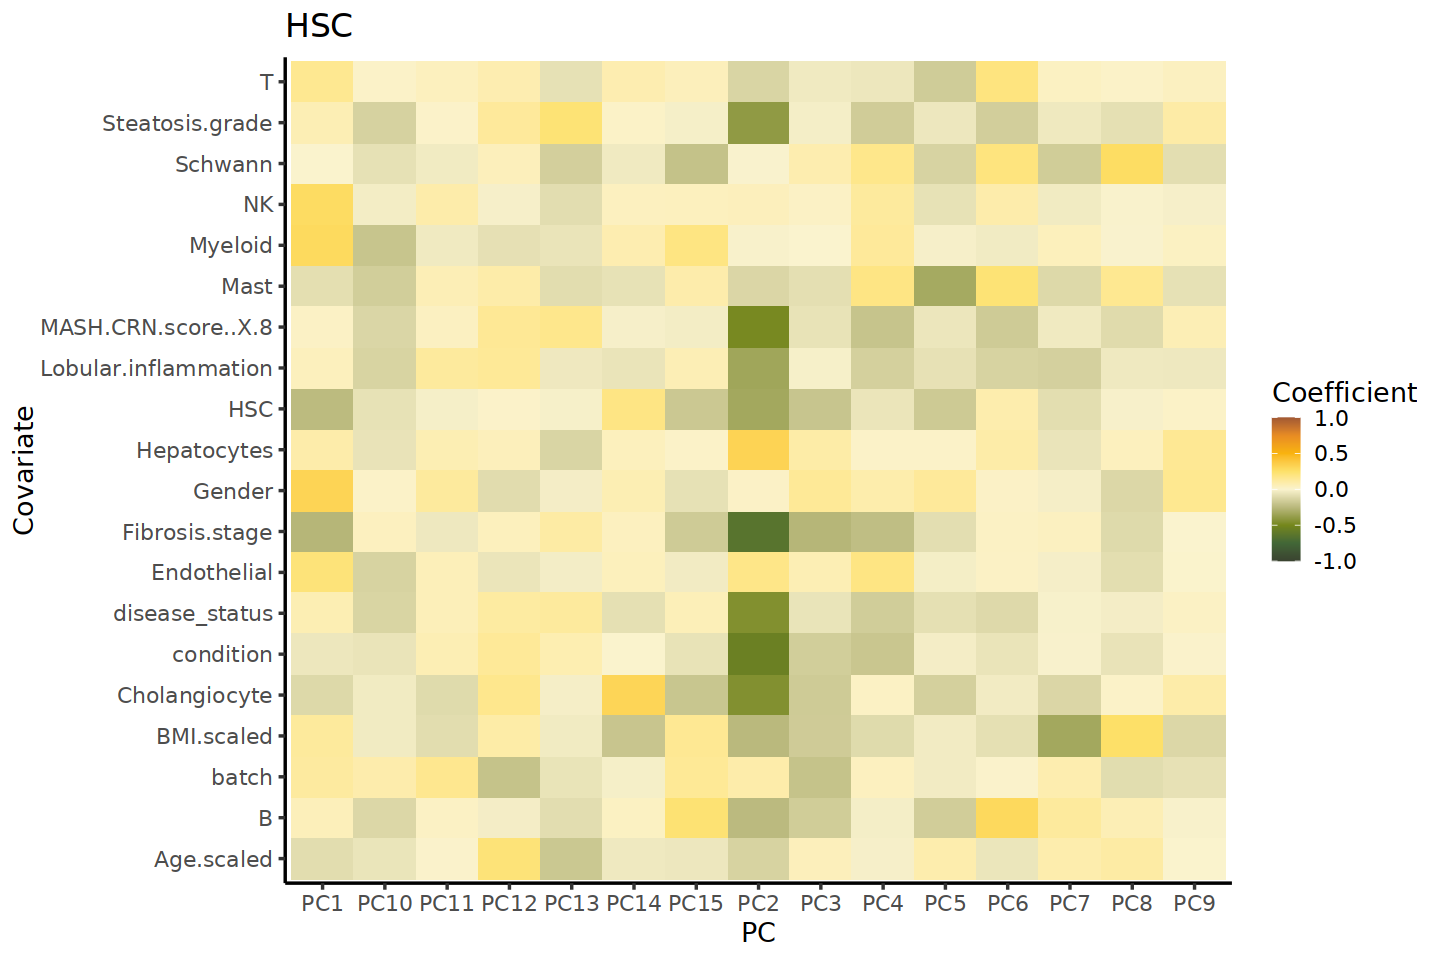

[1] "15 PCs cover 31.562% of variance for Myeloid"
[1] "HL190624 is an outlier on PC4 for Myeloid"
[1] "HL150009 is an outlier on PC5 for Myeloid"
[2] "HL190624 is an outlier on PC5 for Myeloid"
[1] "HL180071 is an outlier on PC6 for Myeloid"
[1] "HL230212 is an outlier on PC7 for Myeloid"
[2] "HL150009 is an outlier on PC7 for Myeloid"
[3] "HL200615 is an outlier on PC7 for Myeloid"
[1] "HL230212 is an outlier on PC8 for Myeloid"
[2] "HL150009 is an outlier on PC8 for Myeloid"
[1] "HL170046 is an outlier on PC9 for Myeloid"
[2] "HL180809 is an outlier on PC9 for Myeloid"
[1] "HL170046 is an outlier on PC10 for Myeloid"
[2] "HL220825 is an outlier on PC10 for Myeloid"
[3] "HL200615 is an outlier on PC10 for Myeloid"
[1] "HL230324 is an outlier on PC11 for Myeloid"
[1] "HL170046 is an outlier on PC12 for Myeloid"
[2] "HL150013 is an outlier on PC12 for Myeloid"
[3] "HL220127 is an outlier on PC12 for Myeloid"
[1] "HL191216 is an outlier on PC13 for Myeloid"
[2] "HL230324 is an outlier o

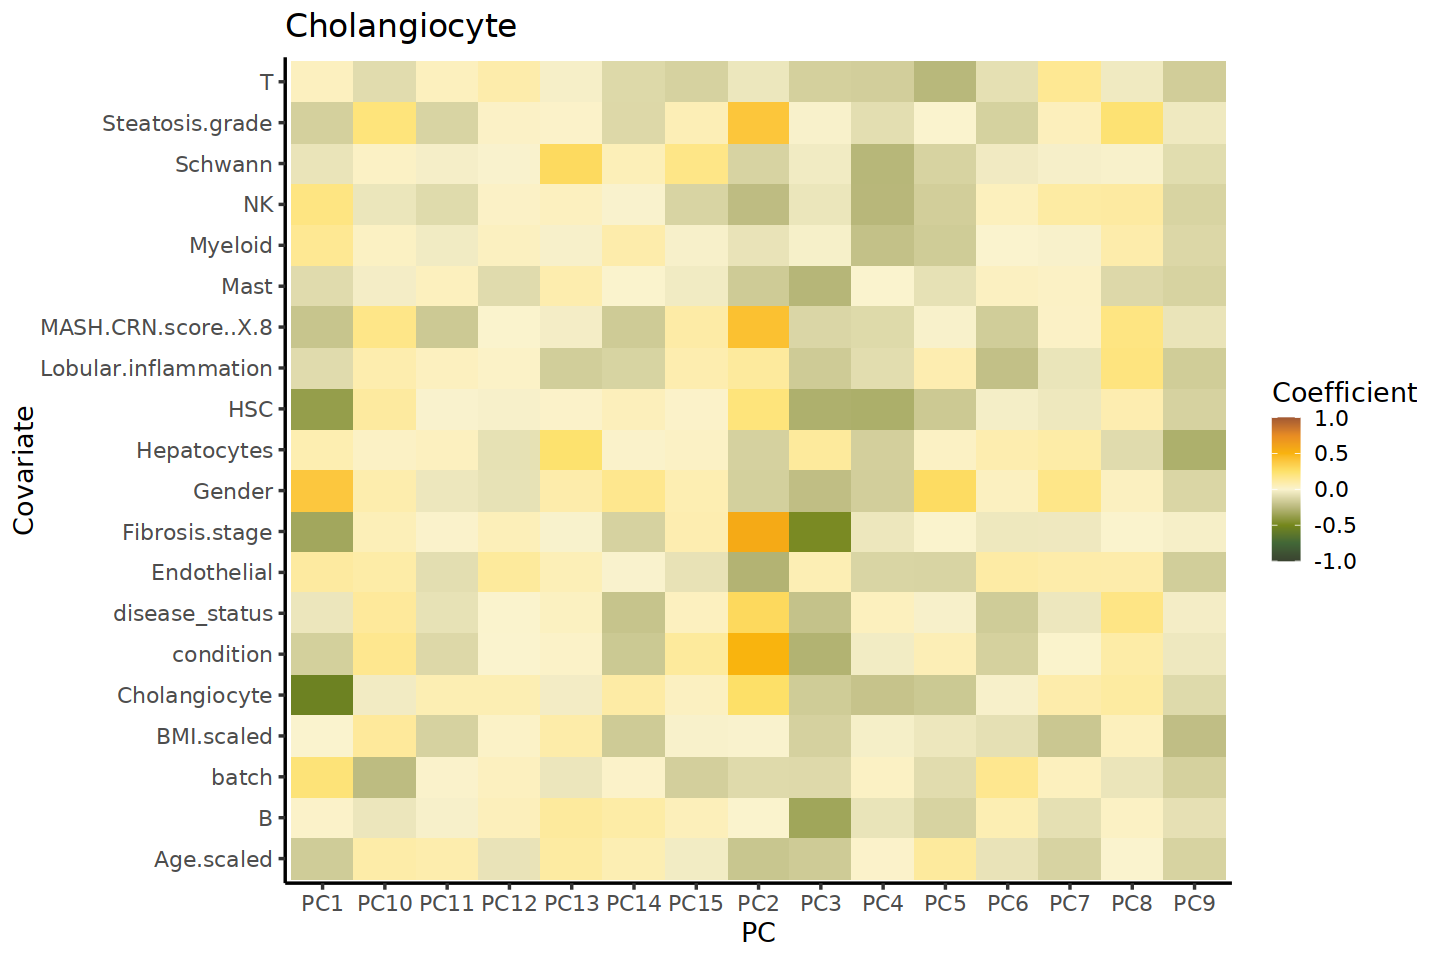

[1] "15 PCs cover 46.276% of variance for NK"
[1] "HL190214 is an outlier on PC2 for NK"
[1] "HL180809 is an outlier on PC3 for NK"
[1] "HL221201 is an outlier on PC4 for NK"
[2] "HL170044 is an outlier on PC4 for NK"
[1] "HL221201 is an outlier on PC5 for NK"
[2] "HL170044 is an outlier on PC5 for NK"
[1] "HL191025 is an outlier on PC6 for NK"
[2] "HL220210 is an outlier on PC6 for NK"
[3] "HL210207 is an outlier on PC6 for NK"
[1] "HL211106 is an outlier on PC7 for NK"
[1] "HL210521 is an outlier on PC8 for NK"
[1] "HL211106 is an outlier on PC9 for NK"
[2] "HL220613 is an outlier on PC9 for NK"
[3] "HL210207 is an outlier on PC9 for NK"
[1] "HL210614 is an outlier on PC10 for NK"
[2] "HL221119 is an outlier on PC10 for NK"
[1] "HL210521 is an outlier on PC11 for NK"
[2] "HL211106 is an outlier on PC11 for NK"
[3] "HL190624 is an outlier on PC11 for NK"
[1] "HL221119 is an outlier on PC12 for NK"
[2] "HL220613 is an outlier on PC12 for NK"
[3] "HL220402 is an outlier on PC12 for NK"


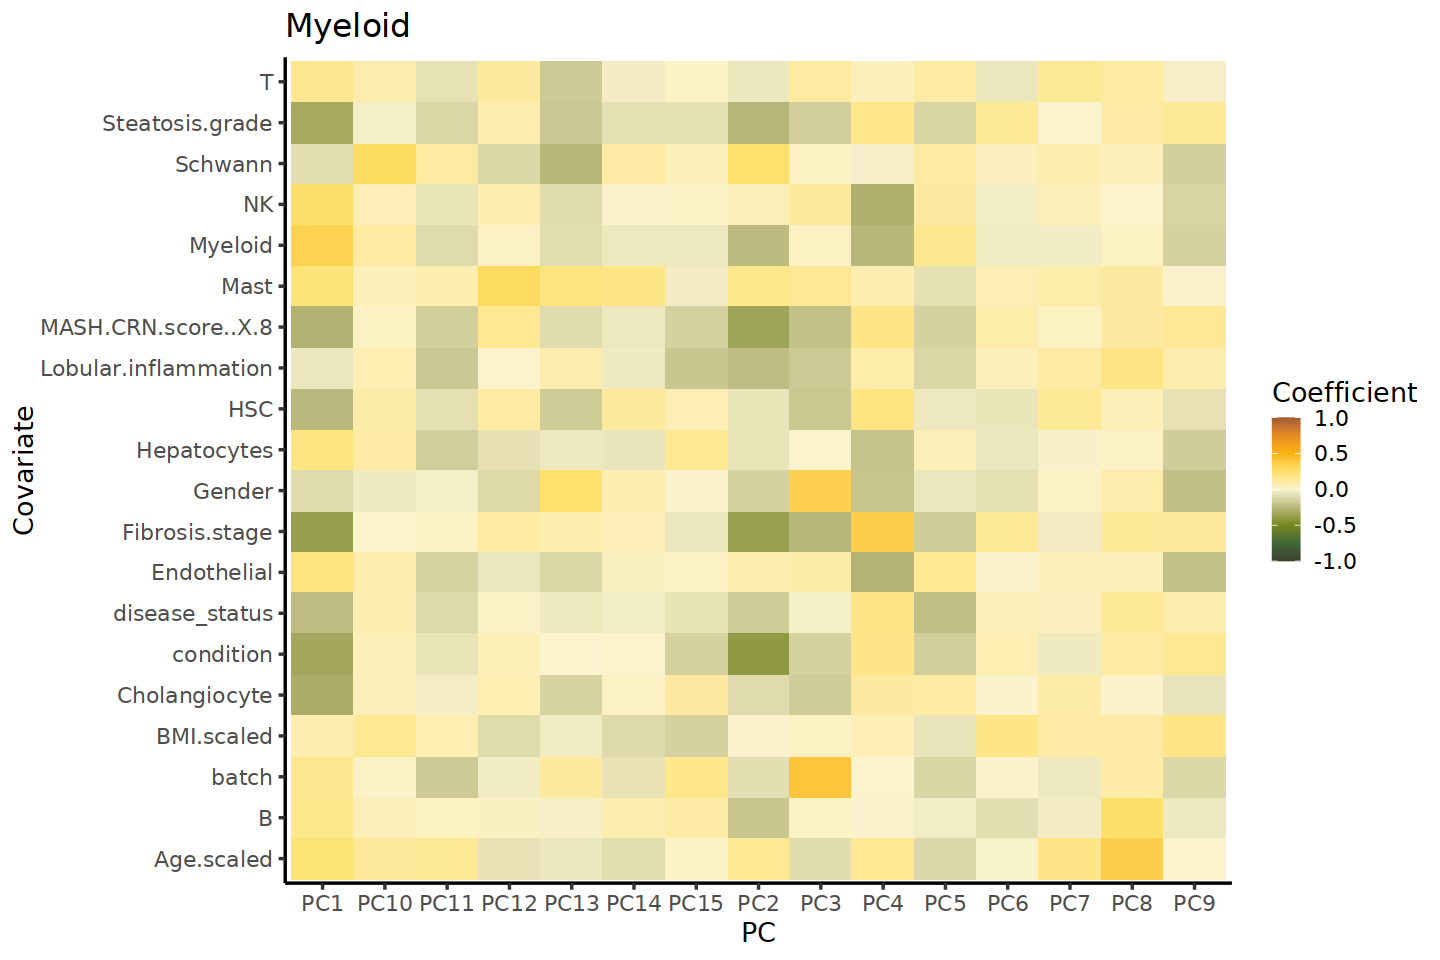

[1] "15 PCs cover 44.463% of variance for B"
[1] "HL201120 is an outlier on PC2 for B"
[1] "HL160037 is an outlier on PC3 for B" "HL221006 is an outlier on PC3 for B"
[1] "HL170062 is an outlier on PC4 for B" "HL211122 is an outlier on PC4 for B"
[1] "HL221006 is an outlier on PC5 for B"
[1] "HL170062 is an outlier on PC6 for B" "HL230325 is an outlier on PC6 for B"
[3] "HL211122 is an outlier on PC6 for B"
[1] "HL211106 is an outlier on PC7 for B" "HL211122 is an outlier on PC7 for B"
[1] "HL150015 is an outlier on PC8 for B"
[1] "HL230212 is an outlier on PC9 for B"
[1] "HL191002 is an outlier on PC10 for B"
[1] "HL201024 is an outlier on PC12 for B"
[1] "HL170047 is an outlier on PC13 for B"
[1] "HL210521 is an outlier on PC14 for B"
[1] "HL230325 is an outlier on PC15 for B"


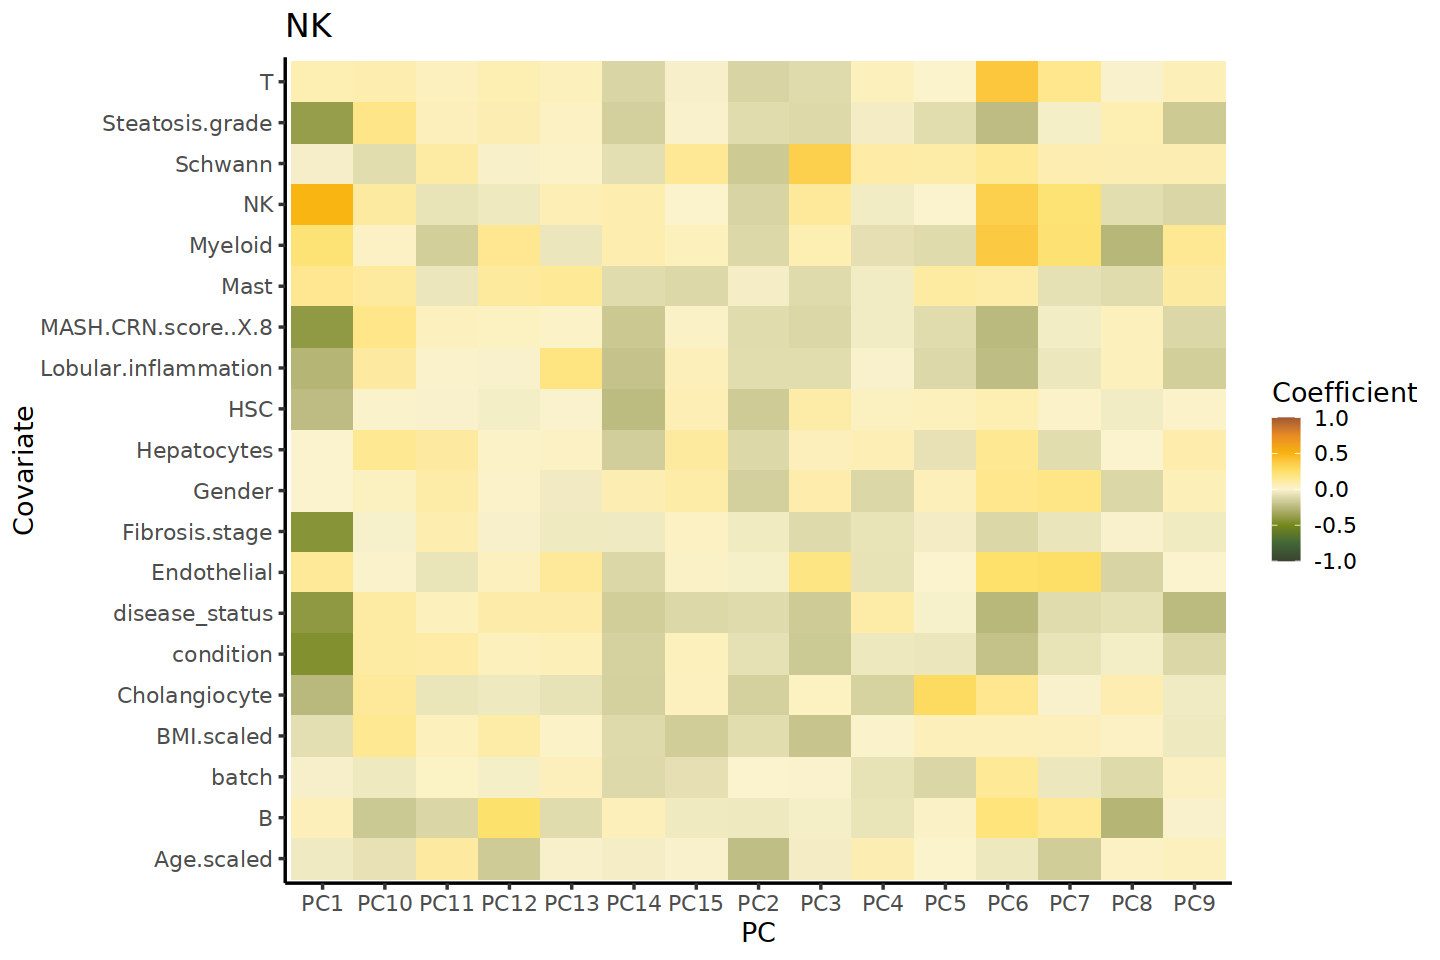

[1] "15 PCs cover 35.871% of variance for Bulk"
[1] "HL181029 is an outlier on PC2 for Bulk"
[2] "HL160022 is an outlier on PC2 for Bulk"
[3] "HL190606 is an outlier on PC2 for Bulk"
[1] "HL190606 is an outlier on PC3 for Bulk"
[1] "HL160022 is an outlier on PC5 for Bulk"
[2] "HL190606 is an outlier on PC5 for Bulk"
[1] "HL220127 is an outlier on PC7 for Bulk"
[1] "HL210727 is an outlier on PC8 for Bulk"
[1] "HL201024 is an outlier on PC9 for Bulk"
[1] "HL160035 is an outlier on PC10 for Bulk"
[1] "HL210614 is an outlier on PC11 for Bulk"
[2] "HL190603 is an outlier on PC11 for Bulk"
[1] "HL210614 is an outlier on PC12 for Bulk"
[2] "HL211106 is an outlier on PC12 for Bulk"
[3] "HL190603 is an outlier on PC12 for Bulk"
[4] "HL181029 is an outlier on PC12 for Bulk"
[1] "HL211106 is an outlier on PC13 for Bulk"
[2] "HL191216 is an outlier on PC13 for Bulk"
[1] "HL210614 is an outlier on PC14 for Bulk"
[2] "HL211106 is an outlier on PC14 for Bulk"
[1] "HL220825 is an outlier on PC15 for B

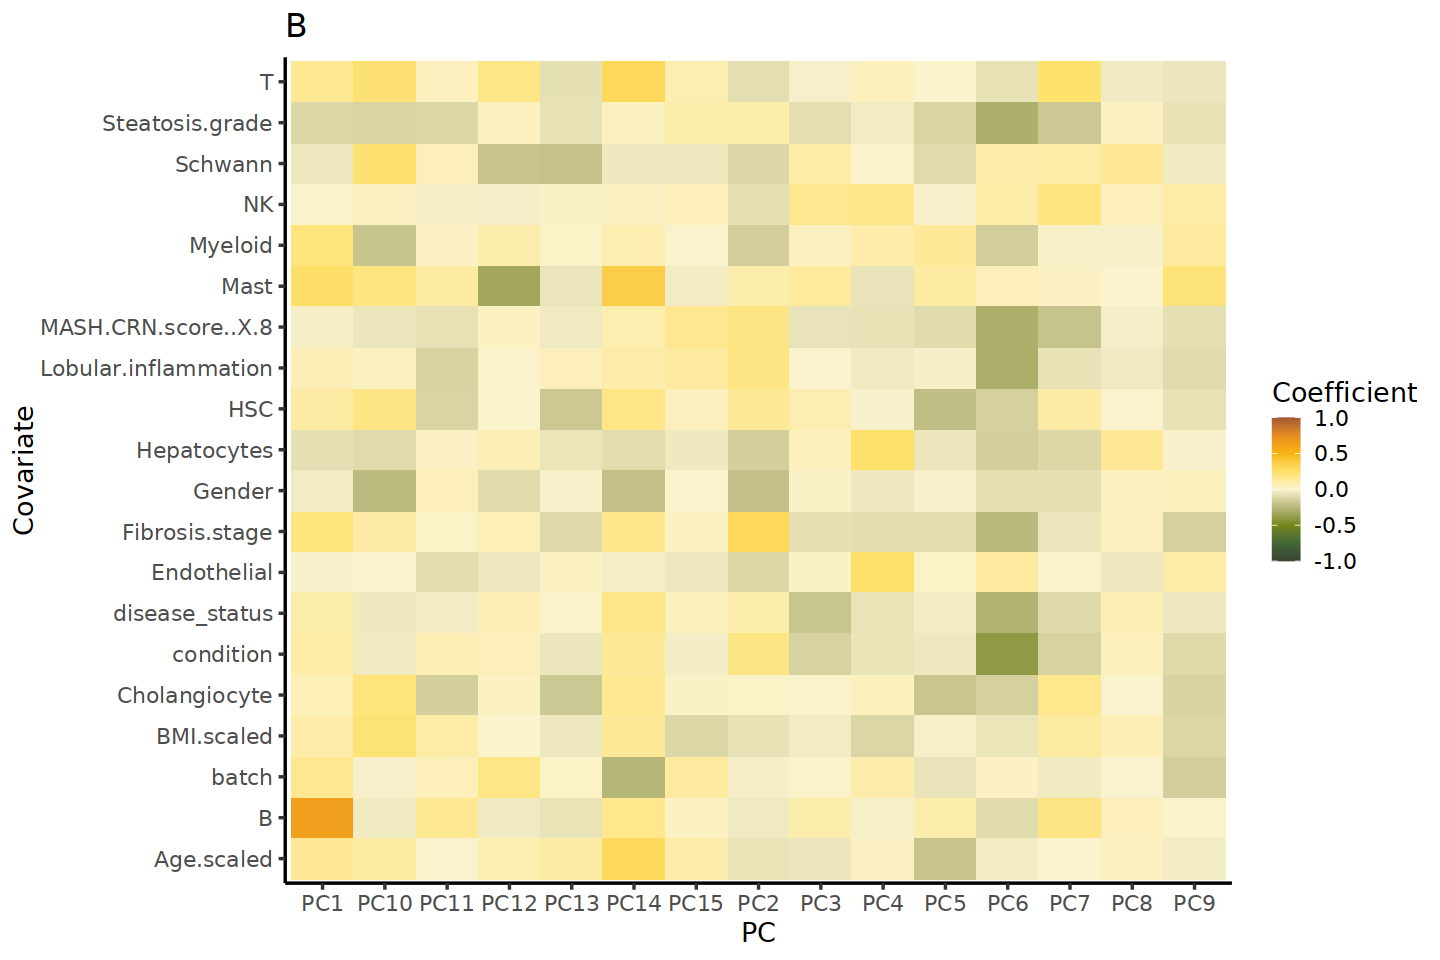

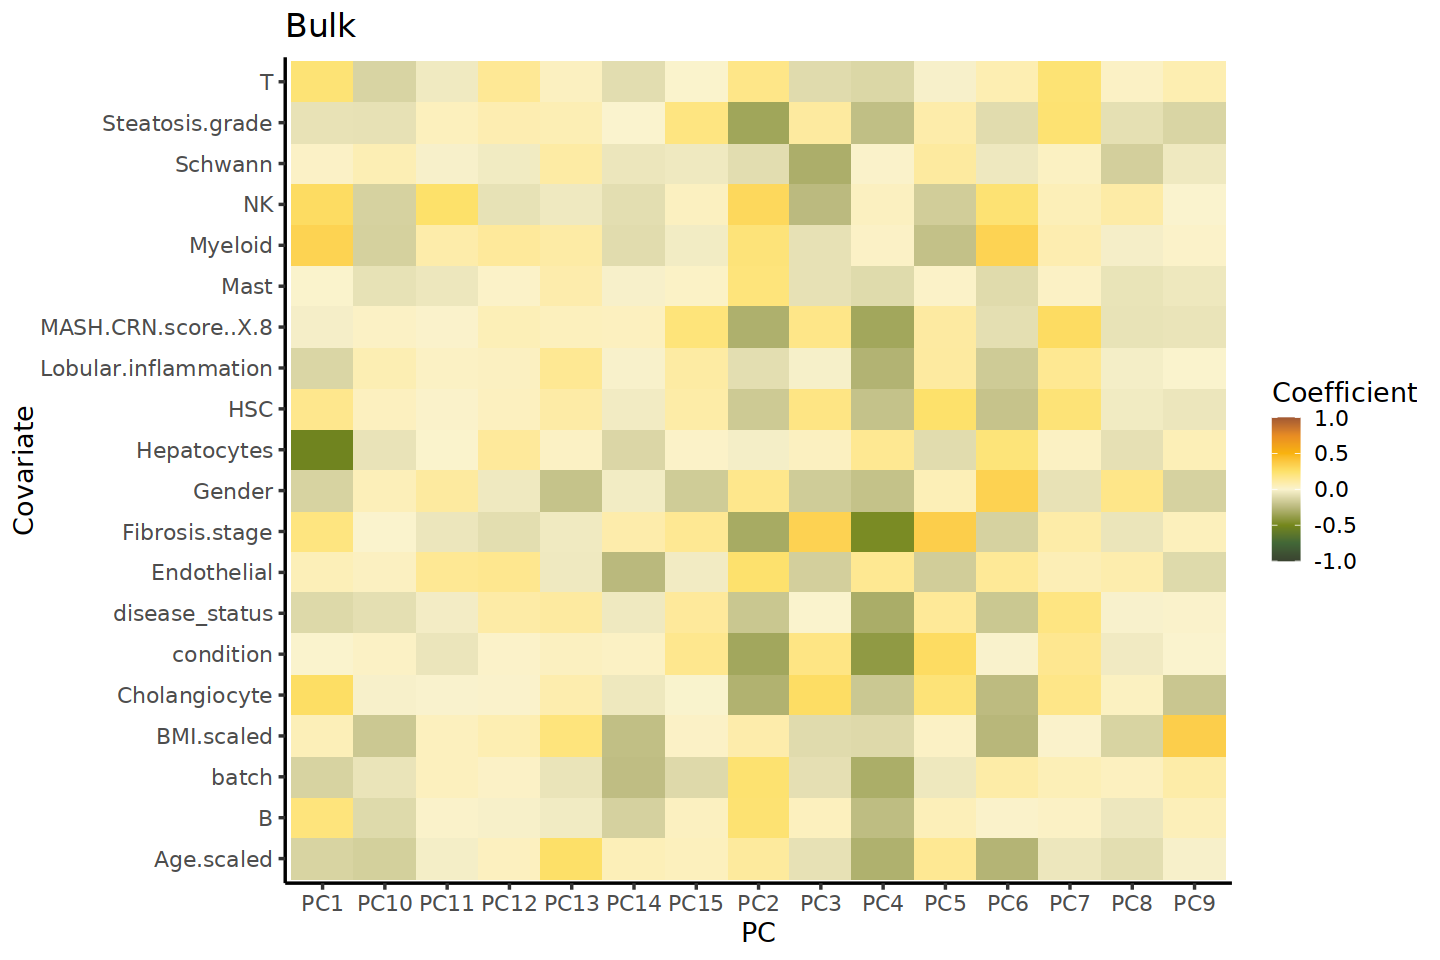

In [75]:
indir <- '/nfs/lab/projects/nash_nafld_liver/downstream_all/count.matrices/H3K27me3/'
outdir <- '/nfs/lab/projects/nash_nafld_liver/downstream_all/07_H3K27me3QTLs/covariates/'

n_pc <- 15

##### NAME YOUR FILES #####
for (cell.type in unique_cell_types){
    # Not enough stuff for these cell types
    if (cell.type %in% c('Mast','Schwann')) {
        next
    }
    #tmm.filename <- paste(indir, cell.type, '_perdonor.H3K27me3.TMM.tsv', sep = "")
    int.filename <- paste(indir, cell.type, '_perdonor.H3K27me3.INT.tsv', sep = "")
    pc.filename <- paste(outdir, cell.type, '_perdonor.H3K27me3.INT.', n_pc,'.PCs.tsv', sep = "")
    cor.filename <- paste(outdir, cell.type, '_perdonor.H3K27me3.INT.', n_pc,'.PCs.correlation.tsv', sep = "")
    make_PC_covariate_mat(cell.type, expr.mat.filename=int.filename, pc.filename, 
                          cor.filename, n_pc=15, meta)
}

[1] "15 PCs cover 31.255% of variance for Endothelial"
[1] "HL190215 is an outlier on PC2 for Endothelial"
[2] "HL170064 is an outlier on PC2 for Endothelial"
[1] "HL210521 is an outlier on PC3 for Endothelial"
[2] "HL211001 is an outlier on PC3 for Endothelial"
[1] "HL170062 is an outlier on PC4 for Endothelial"
[2] "HL211001 is an outlier on PC4 for Endothelial"
[1] "HL170062 is an outlier on PC5 for Endothelial"
[1] "HL190215 is an outlier on PC6 for Endothelial"
[2] "HL211001 is an outlier on PC6 for Endothelial"
[1] "HL190215 is an outlier on PC7 for Endothelial"
[2] "HL170064 is an outlier on PC7 for Endothelial"
[1] "HL210521 is an outlier on PC8 for Endothelial"
[2] "HL221201 is an outlier on PC8 for Endothelial"
[1] "HL210706 is an outlier on PC9 for Endothelial"
[1] "HL221215 is an outlier on PC10 for Endothelial"
[2] "HL210706 is an outlier on PC10 for Endothelial"
[3] "HL190624 is an outlier on PC10 for Endothelial"
[1] "HL221215 is an outlier on PC11 for Endothelial"
[2] "

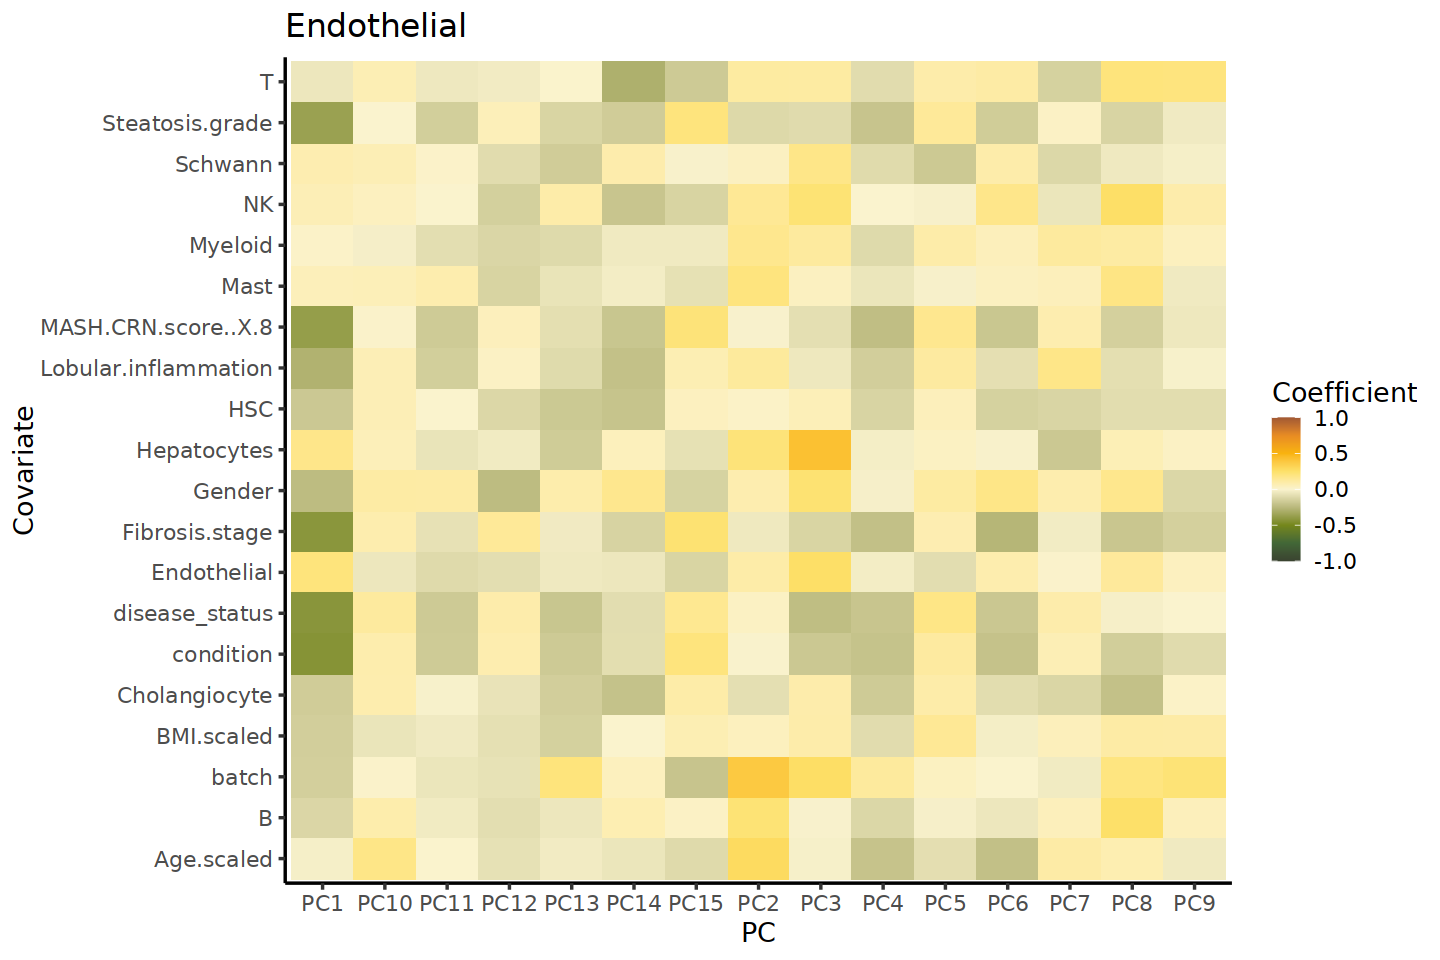

[1] "15 PCs cover 39.046% of variance for T"
[1] "HL221019 is an outlier on PC1 for T"
[1] "HL210521 is an outlier on PC2 for T"
[1] "HL200925 is an outlier on PC3 for T" "HL230302 is an outlier on PC3 for T"
[3] "HL190827 is an outlier on PC3 for T"
[1] "HL200925 is an outlier on PC4 for T" "HL230302 is an outlier on PC4 for T"
[1] "HL191002 is an outlier on PC5 for T" "HL190827 is an outlier on PC5 for T"
[1] "HL170058 is an outlier on PC6 for T" "HL191002 is an outlier on PC6 for T"
[1] "HL170058 is an outlier on PC7 for T" "HL220216 is an outlier on PC7 for T"
[1] "HL170058 is an outlier on PC8 for T" "HL220216 is an outlier on PC8 for T"
[1] "HL160040 is an outlier on PC9 for T" "HL201120 is an outlier on PC9 for T"
[1] "HL160040 is an outlier on PC10 for T"
[2] "HL201120 is an outlier on PC10 for T"
[1] "HL221019 is an outlier on PC11 for T"
[2] "HL210706 is an outlier on PC11 for T"
[3] "HL210621 is an outlier on PC11 for T"
[1] "HL210706 is an outlier on PC12 for T"
[2] "HL2106

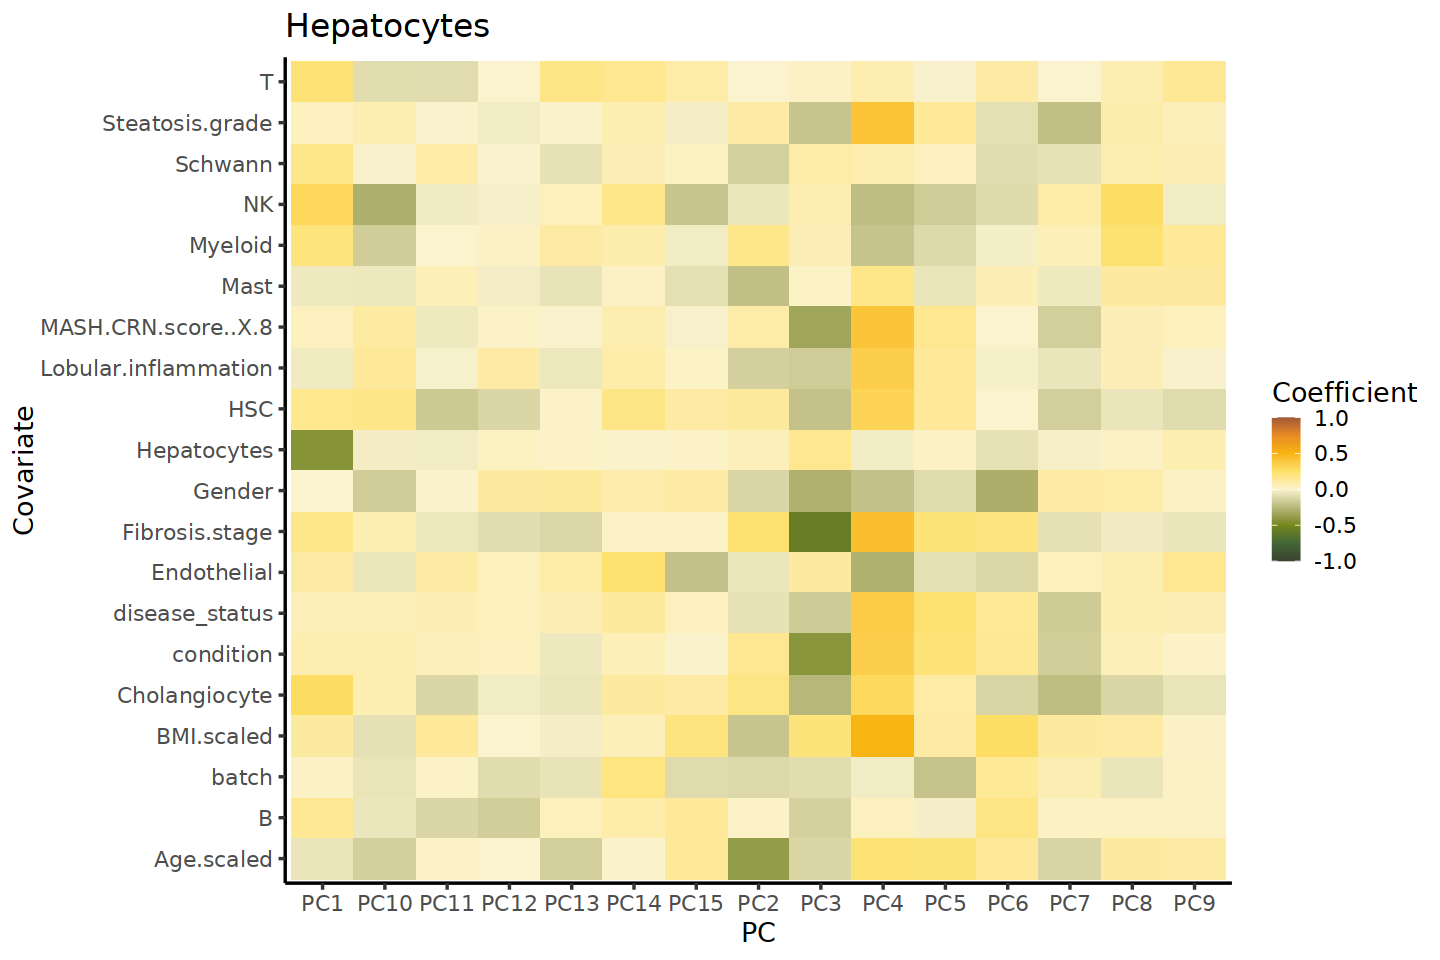

[1] "15 PCs cover 30.588% of variance for HSC"
[1] "HL221019 is an outlier on PC1 for HSC"
[1] "HL160029 is an outlier on PC2 for HSC"
[2] "HL170049 is an outlier on PC2 for HSC"
[1] "HL221019 is an outlier on PC3 for HSC"
[2] "HL170049 is an outlier on PC3 for HSC"
[1] "HL221019 is an outlier on PC4 for HSC"
[2] "HL170058 is an outlier on PC4 for HSC"
[1] "HL191002 is an outlier on PC5 for HSC"
[1] "HL230316 is an outlier on PC6 for HSC"
[2] "HL221019 is an outlier on PC6 for HSC"
[1] "HL170065 is an outlier on PC7 for HSC"
[1] "HL230316 is an outlier on PC8 for HSC"
[2] "HL190827 is an outlier on PC8 for HSC"
[1] "HL200525 is an outlier on PC9 for HSC"
[2] "HL170046 is an outlier on PC9 for HSC"
[3] "HL190827 is an outlier on PC9 for HSC"
[1] "HL200525 is an outlier on PC10 for HSC"
[2] "HL170046 is an outlier on PC10 for HSC"
[1] "HL160029 is an outlier on PC11 for HSC"
[2] "HL200115 is an outlier on PC11 for HSC"
[1] "HL160026 is an outlier on PC12 for HSC"
[2] "HL200115 is an outl

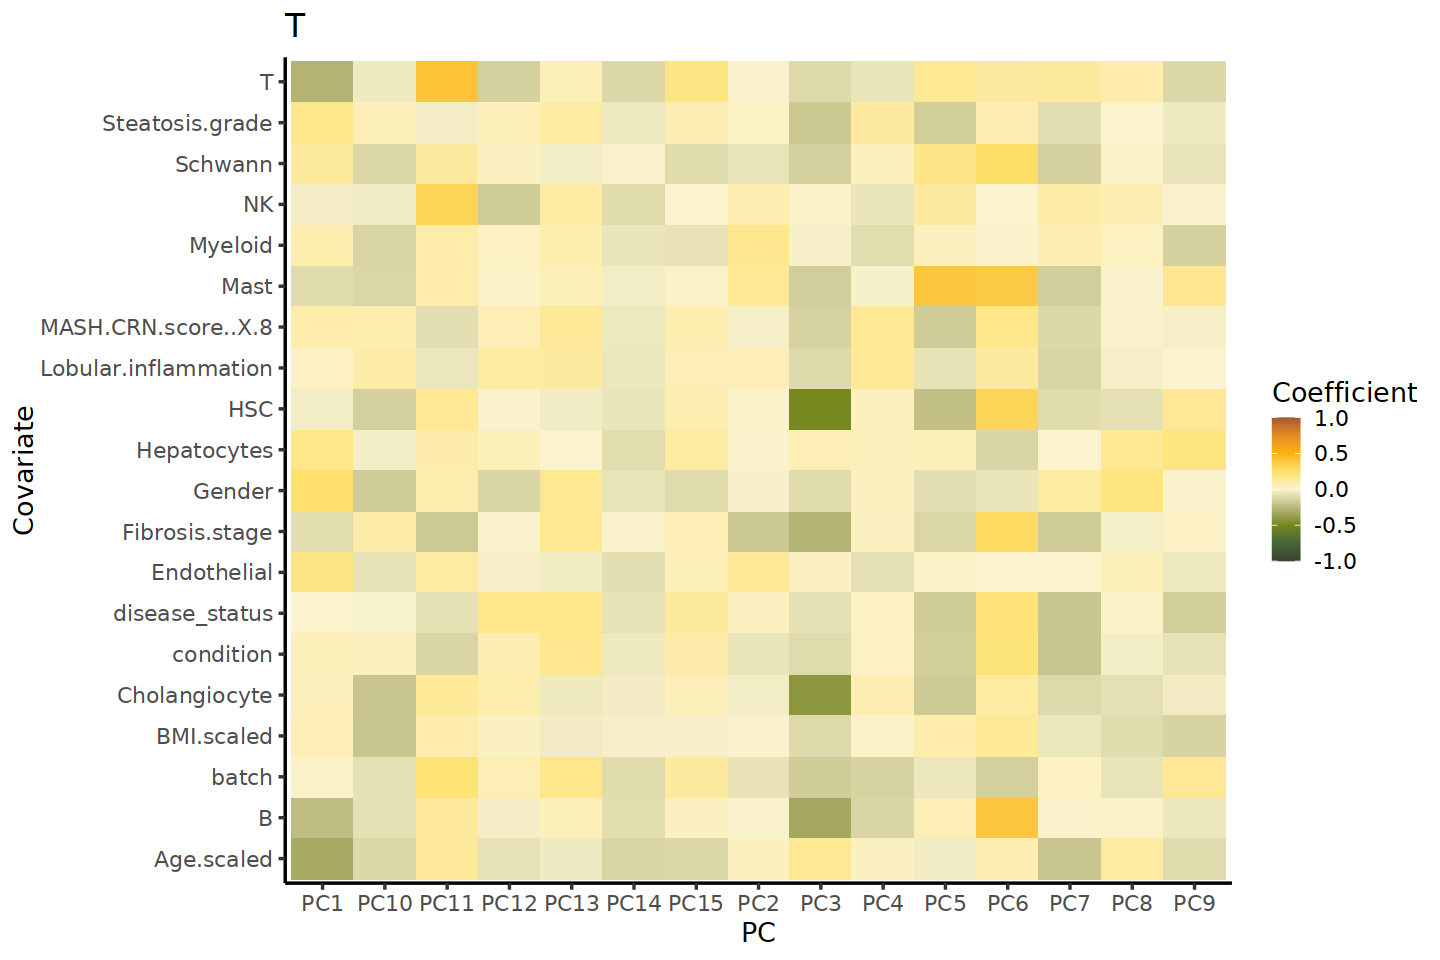

[1] "15 PCs cover 34.657% of variance for Cholangiocyte"
[1] "HL210806 is an outlier on PC2 for Cholangiocyte"
[2] "HL181029 is an outlier on PC2 for Cholangiocyte"
[1] "HL221019 is an outlier on PC3 for Cholangiocyte"
[2] "HL191002 is an outlier on PC3 for Cholangiocyte"
[1] "HL170049 is an outlier on PC4 for Cholangiocyte"
[2] "HL191002 is an outlier on PC4 for Cholangiocyte"
[1] "HL221019 is an outlier on PC5 for Cholangiocyte"
[2] "HL170049 is an outlier on PC5 for Cholangiocyte"
[3] "HL191002 is an outlier on PC5 for Cholangiocyte"
[1] "HL190214 is an outlier on PC6 for Cholangiocyte"
[2] "HL191002 is an outlier on PC6 for Cholangiocyte"
[1] "HL170062 is an outlier on PC7 for Cholangiocyte"
[1] "HL160042 is an outlier on PC8 for Cholangiocyte"
[2] "HL190214 is an outlier on PC8 for Cholangiocyte"
[1] "HL191025 is an outlier on PC9 for Cholangiocyte"
[2] "HL210706 is an outlier on PC9 for Cholangiocyte"
[3] "HL230325 is an outlier on PC9 for Cholangiocyte"
[1] "HL191025 is an outli

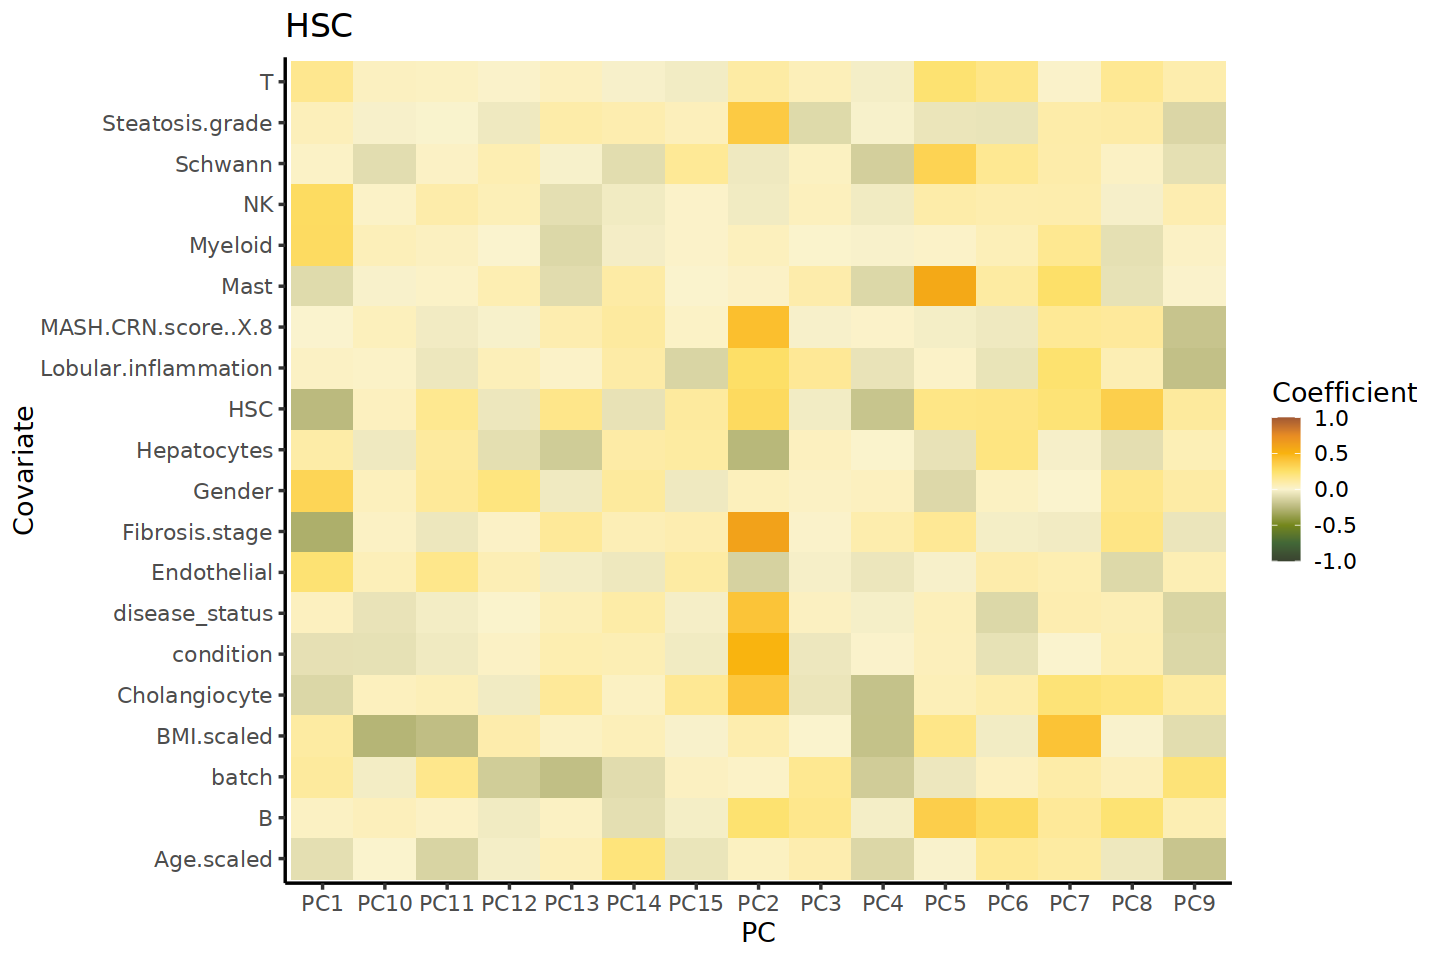

[1] "15 PCs cover 32.105% of variance for Myeloid"
[1] "HL230325 is an outlier on PC2 for Myeloid"
[1] "HL160017 is an outlier on PC3 for Myeloid"
[2] "HL201120 is an outlier on PC3 for Myeloid"
[1] "HL190624 is an outlier on PC4 for Myeloid"
[1] "HL160037 is an outlier on PC5 for Myeloid"
[2] "HL180071 is an outlier on PC5 for Myeloid"
[3] "HL190624 is an outlier on PC5 for Myeloid"
[1] "HL180071 is an outlier on PC6 for Myeloid"
[2] "HL201120 is an outlier on PC6 for Myeloid"
[1] "HL190326 is an outlier on PC7 for Myeloid"
[2] "HL160017 is an outlier on PC7 for Myeloid"
[1] "HL190326 is an outlier on PC8 for Myeloid"
[2] "HL170062 is an outlier on PC8 for Myeloid"
[3] "HL160017 is an outlier on PC8 for Myeloid"
[4] "HL160037 is an outlier on PC8 for Myeloid"
[1] "HL170062 is an outlier on PC9 for Myeloid"
[2] "HL160037 is an outlier on PC9 for Myeloid"
[3] "HL201120 is an outlier on PC9 for Myeloid"
[1] "HL230324 is an outlier on PC10 for Myeloid"
[2] "HL170062 is an outlier on PC10 

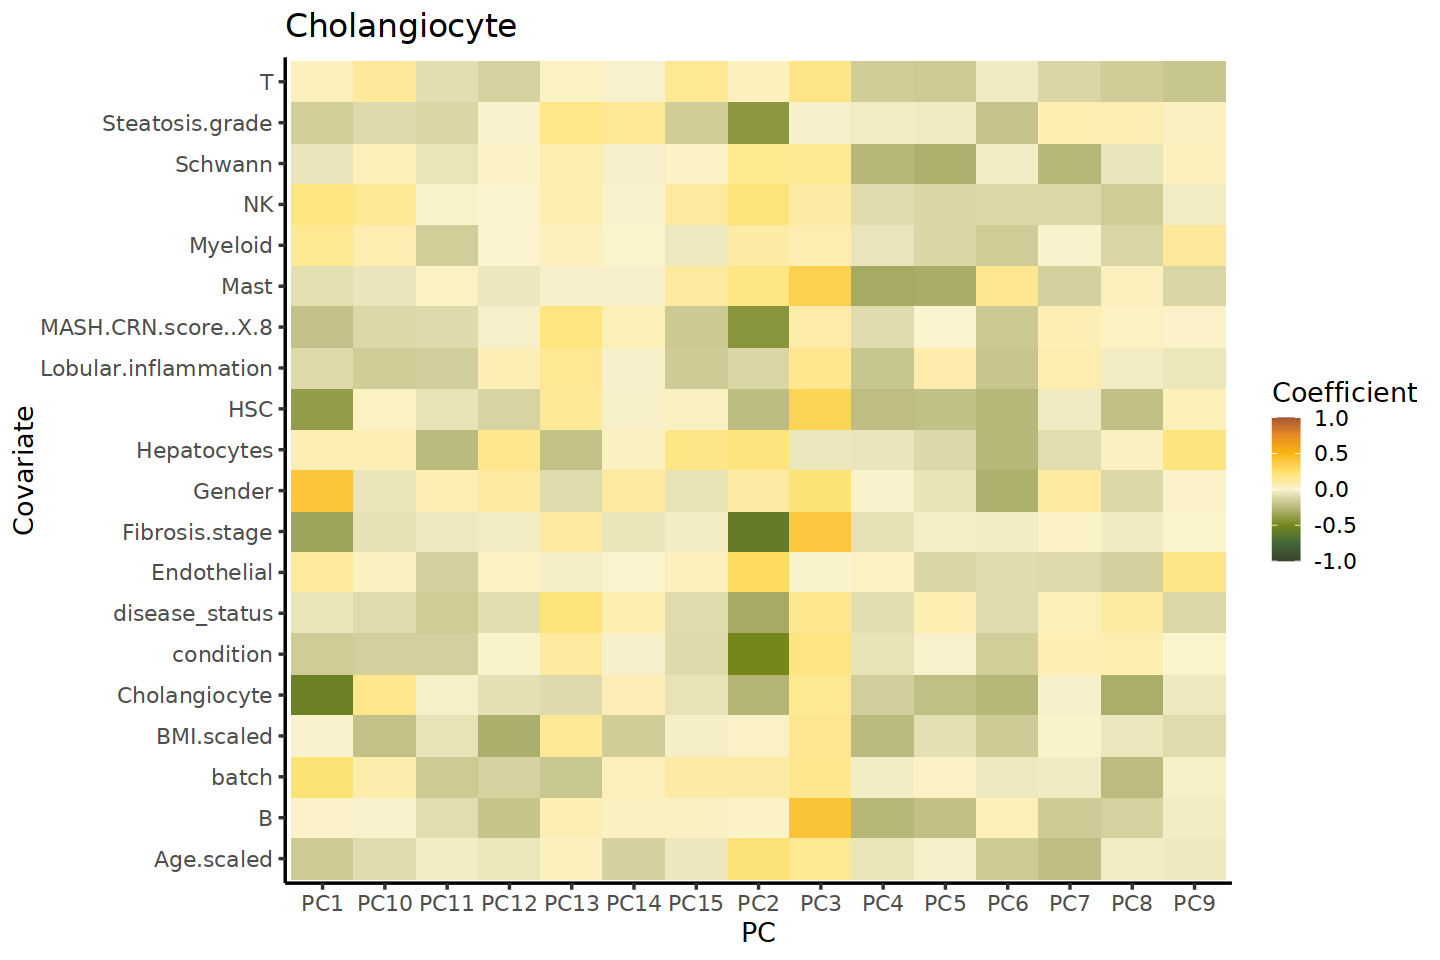

[1] "15 PCs cover 38.968% of variance for NK"
[1] "HL160029 is an outlier on PC1 for NK"
[2] "HL200212 is an outlier on PC1 for NK"
[3] "HL160037 is an outlier on PC1 for NK"
[1] "HL200212 is an outlier on PC2 for NK"
[2] "HL160037 is an outlier on PC2 for NK"
[1] "HL160029 is an outlier on PC3 for NK"
[2] "HL200212 is an outlier on PC3 for NK"
[1] "HL210521 is an outlier on PC4 for NK"
[2] "HL160029 is an outlier on PC4 for NK"
[3] "HL210614 is an outlier on PC4 for NK"
[1] "HL210521 is an outlier on PC5 for NK"
[2] "HL210614 is an outlier on PC5 for NK"
[1] "HL210521 is an outlier on PC6 for NK"
[2] "HL220210 is an outlier on PC6 for NK"
[1] "HL191025 is an outlier on PC7 for NK"
[2] "HL220210 is an outlier on PC7 for NK"
[1] "HL191025 is an outlier on PC8 for NK"
[2] "HL160032 is an outlier on PC8 for NK"
[1] "HL200115 is an outlier on PC9 for NK"
[1] "HL160042 is an outlier on PC10 for NK"
[1] "HL170060 is an outlier on PC11 for NK"
[2] "HL200115 is an outlier on PC11 for NK"
[1] "

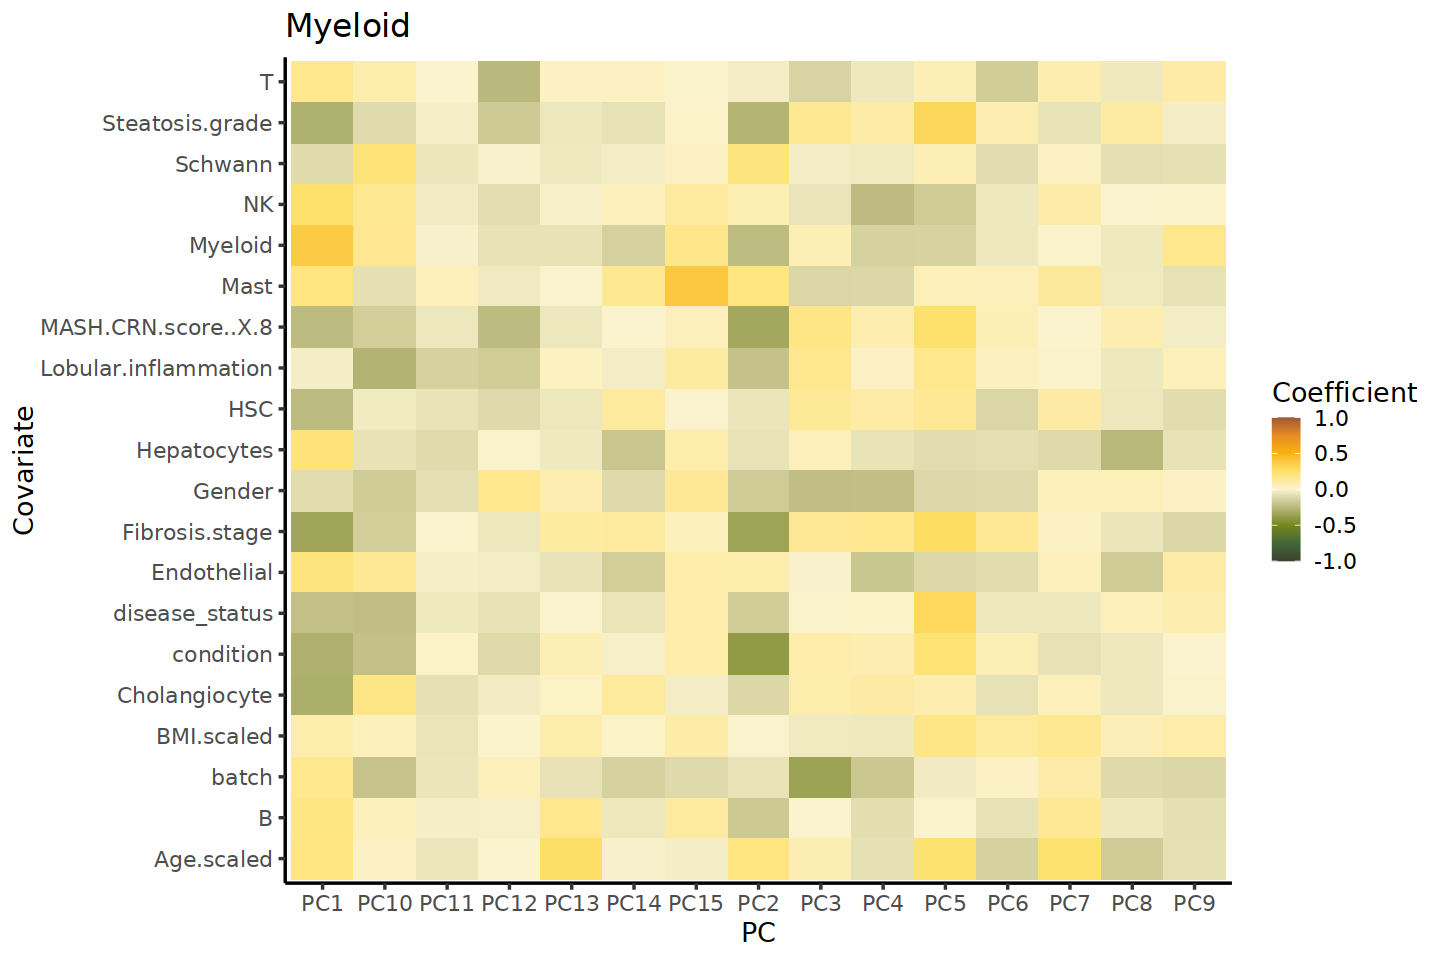

[1] "15 PCs cover 39.504% of variance for B"
[1] "HL221019 is an outlier on PC1 for B"
[1] "HL221019 is an outlier on PC2 for B" "HL190827 is an outlier on PC2 for B"
[1] "HL221119 is an outlier on PC3 for B" "HL190827 is an outlier on PC3 for B"
[1] "HL190114 is an outlier on PC4 for B"
[1] "HL191002 is an outlier on PC5 for B" "HL150013 is an outlier on PC5 for B"
[1] "HL221119 is an outlier on PC6 for B" "HL191002 is an outlier on PC6 for B"
[3] "HL150013 is an outlier on PC6 for B"
[1] "HL150015 is an outlier on PC7 for B"
[1] "HL211122 is an outlier on PC8 for B"
[1] "HL200212 is an outlier on PC9 for B" "HL211122 is an outlier on PC9 for B"
[1] "HL210806 is an outlier on PC10 for B"
[2] "HL170046 is an outlier on PC10 for B"
[1] "HL210806 is an outlier on PC11 for B"
[2] "HL170046 is an outlier on PC11 for B"
[1] "HL210521 is an outlier on PC12 for B"
[2] "HL230316 is an outlier on PC12 for B"
[3] "HL230302 is an outlier on PC12 for B"
[4] "HL200212 is an outlier on PC12 for B"
[

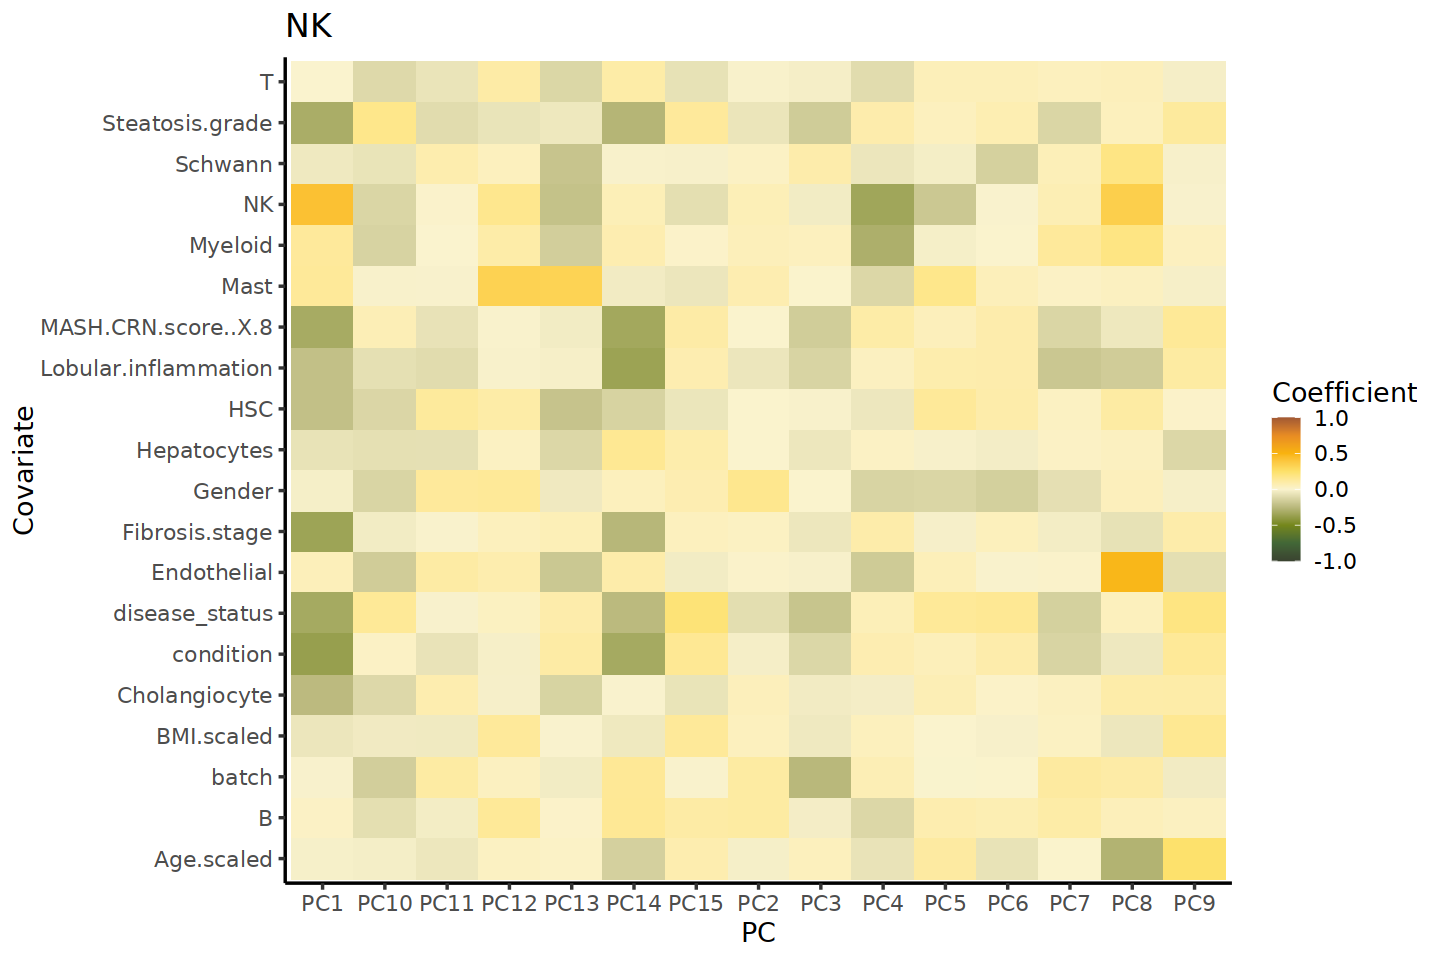

[1] "15 PCs cover 40.435% of variance for Bulk"
[1] "HL160026 is an outlier on PC2 for Bulk"
[1] "HL160022 is an outlier on PC3 for Bulk"
[2] "HL190606 is an outlier on PC3 for Bulk"
[1] "HL160022 is an outlier on PC4 for Bulk"
[1] "HL190606 is an outlier on PC5 for Bulk"
[1] "HL160022 is an outlier on PC6 for Bulk"
[2] "HL190606 is an outlier on PC6 for Bulk"
[1] "HL220127 is an outlier on PC7 for Bulk"
[1] "HL211106 is an outlier on PC8 for Bulk"
[2] "HL201024 is an outlier on PC8 for Bulk"
[1] "HL160035 is an outlier on PC9 for Bulk"
[2] "HL220127 is an outlier on PC9 for Bulk"
[1] "HL211106 is an outlier on PC10 for Bulk"
[2] "HL181029 is an outlier on PC10 for Bulk"
[1] "HL210614 is an outlier on PC11 for Bulk"
[2] "HL211106 is an outlier on PC11 for Bulk"
[3] "HL210727 is an outlier on PC11 for Bulk"
[4] "HL160035 is an outlier on PC11 for Bulk"
[1] "HL211106 is an outlier on PC12 for Bulk"
[2] "HL201024 is an outlier on PC12 for Bulk"
[3] "HL160035 is an outlier on PC12 for Bulk

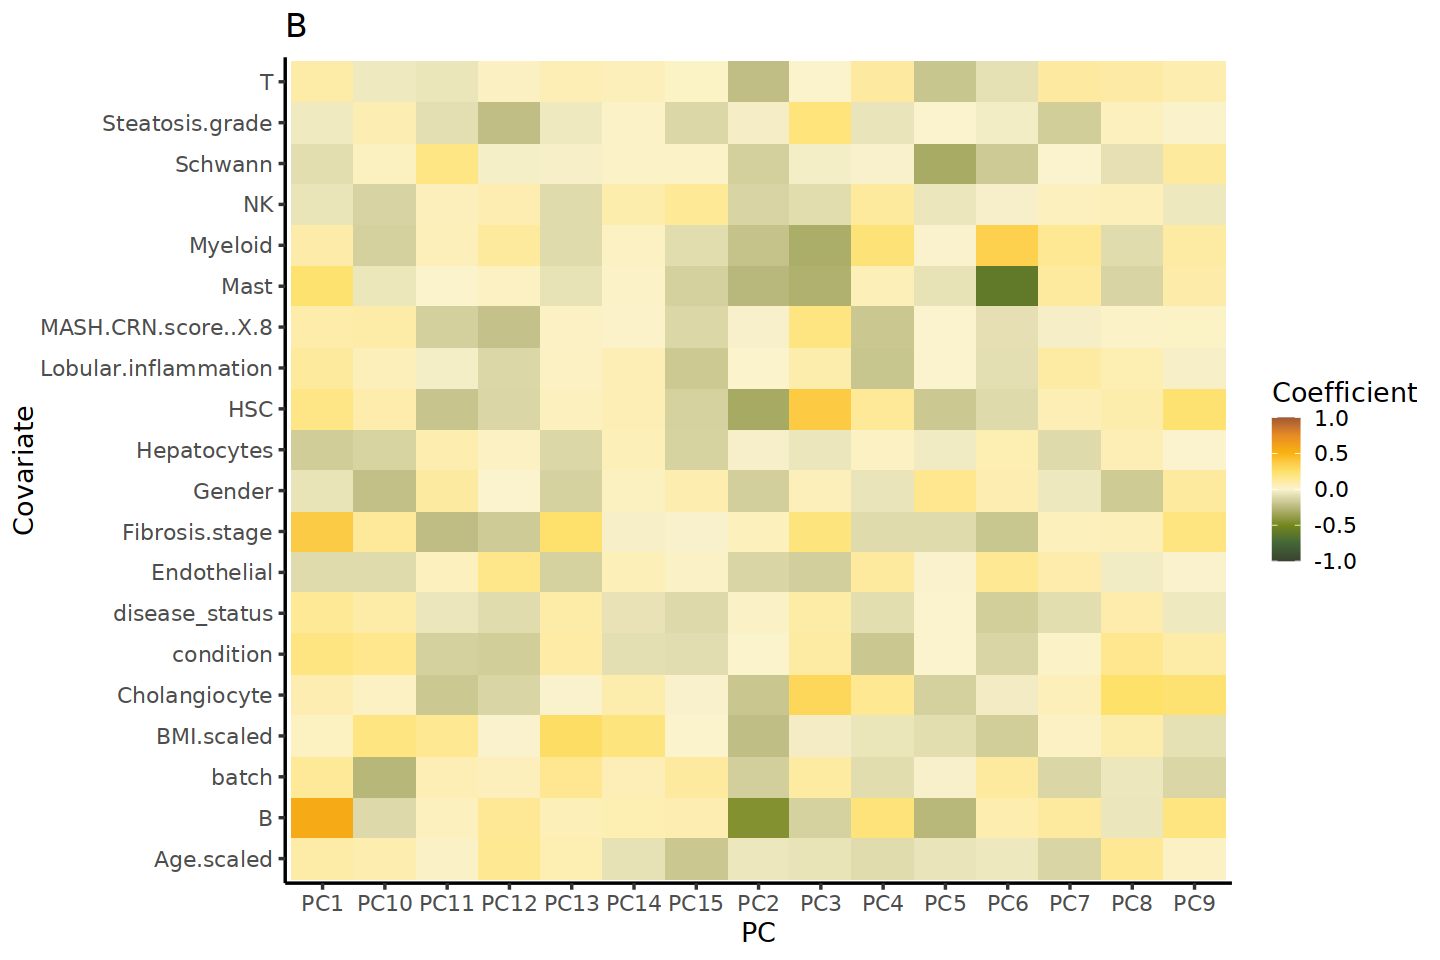

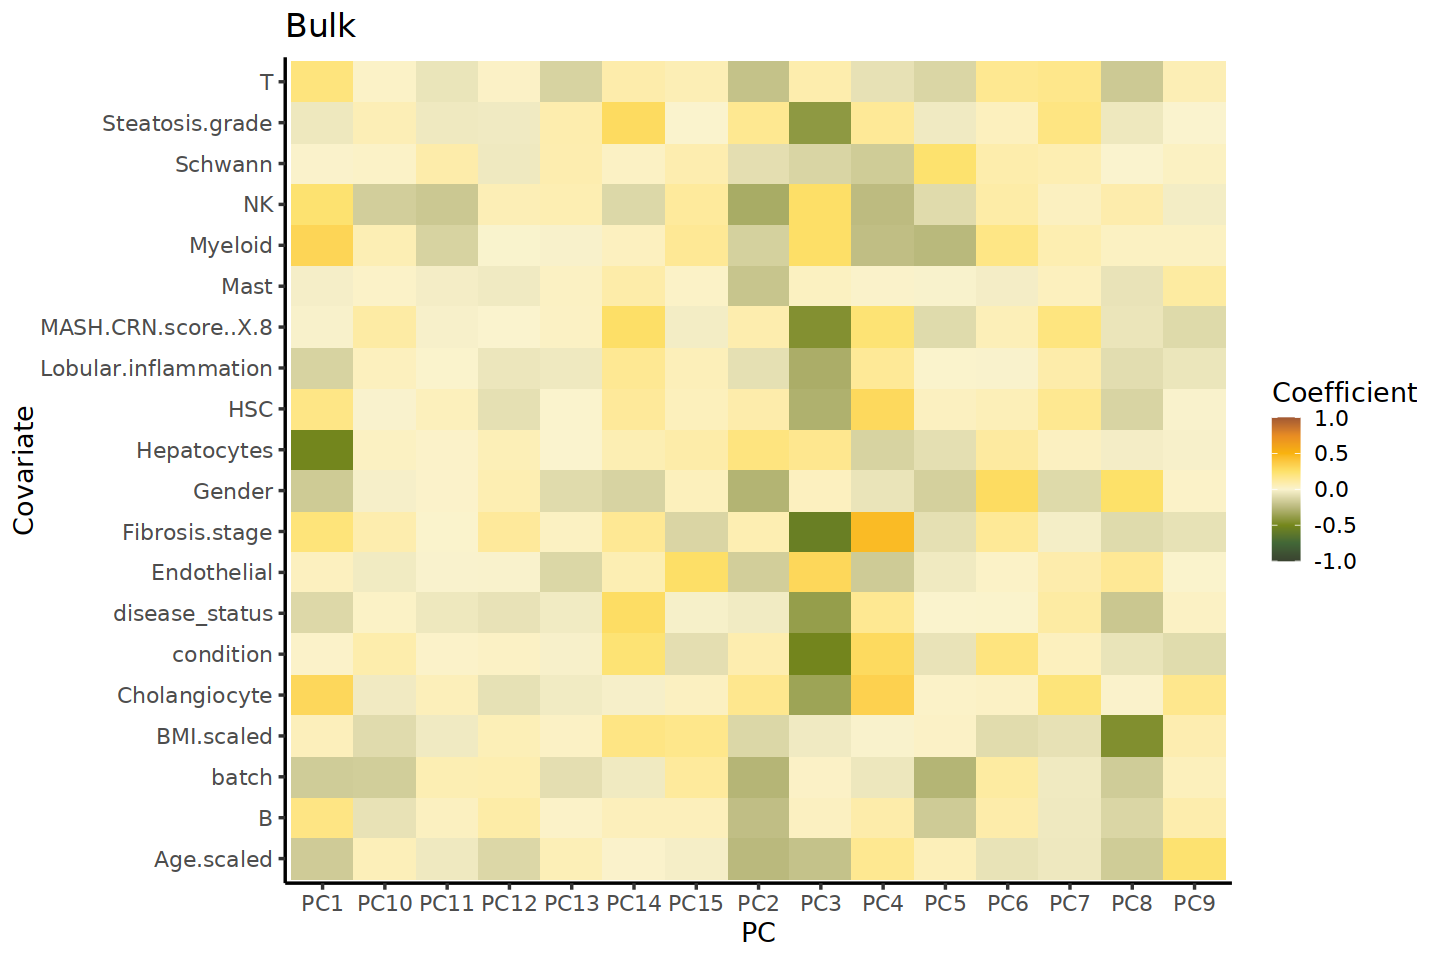

In [11]:
indir <- '/nfs/lab/projects/nash_nafld_liver/downstream_all/count.matrices/H3K27me3/'
outdir <- '/nfs/lab/projects/nash_nafld_liver/downstream_all/07_H3K27me3QTLs/covariates/'

n_pc <- 15

##### NAME YOUR FILES #####
for (cell.type in unique_cell_types){
    if (cell.type %in% c('Mast','Schwann')) {
        next
    }
    tmm.filename <- paste(indir, cell.type, '_perdonor.H3K27me3.TMM.tsv', sep = "")
    #int.filename <- paste(indir, cell.type, '_perdonor.H3K27me3.INT.tsv', sep = "")
    pc.filename <- paste(outdir, cell.type, '_perdonor.H3K27me3.TMM.', n_pc,'.PCs.tsv', sep = "")
    cor.filename <- paste(outdir, cell.type, '_perdonor.H3K27me3.TMM.', n_pc,'.PCs.correlation.tsv', sep = "")
    make_PC_covariate_mat(cell.type, expr.mat.filename=tmm.filename, pc.filename,
                          cor.filename, n_pc=15, meta)
}